FOMC stance classification: LSTM, BiLSTM, TCN and FLAN-T5

Individual experiment notebook for LSTM, BiLSTM, LSTM+TCN, and the additional FLAN-T5 v1/v2 experiments. All final metrics come from saved experiment artifacts.


1. Task, data and fair evaluation protocol

The task is sentence-level FOMC stance classification: Dovish, Hawkish, and Neutral. Configurations are selected only on validation seed 5768, then frozen and evaluated on official test seeds 5768, 78516, and 944601. The main metric is mean weighted F1 with standard deviation; macro F1, accuracy, class F1, parameter count, and training time are also retained.


2. Version 01 and Version 02

Version 01 uses the original training data. Version 02 adds augmented copies only to the training partition; validation and official test data remain original, so the augmentation ablation isolates the training-data change.


3. Data, RNN baselines and controlled tuning

The workbook is read into records, fixed splits are created, and text is normalised. The module also writes an overlap audit to prevent train/test leakage.


In [1]:



import argparse
import copy
import csv
import hashlib
import json
import math
import random
import re
import statistics
import sys
import time
from collections import Counter
from dataclasses import dataclass
from itertools import product
from pathlib import Path
from typing import Any, Iterable, Sequence
from zipfile import ZipFile
import xml.etree.ElementTree as ET

import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset


labelnames = {0: "Dovish", 1: "Hawkish", 2: "Neutral"}
labelorder = [0, 1, 2]
specialtokens = ["<pad>", "<unk>"]
tokenpattern = re.compile(r"[A-Za-z0-9]+")
sheetns = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"


@dataclass(frozen=True)
class Record:  # labelled sentence record
    sample_id: str
    original_index: int
    sentence: str
    original_sentence: str
    year: int
    label: int
    source_file: str


def normalisesentence(text: str) -> str:  # normalise sentence text

    return re.sub(r"\s+", " ", text.strip())


def stablesampleid(original_index: int, year: int, label: int, sentence: str) -> str:  # build stable sample ID

    key = f"{original_index}|{year}|{label}|{sentence}".encode("utf-8")
    return f"fomc_{hashlib.sha1(key).hexdigest()}"


def columnindex(cellref: str) -> int:  # parse cell column
    letters = "".join(ch for ch in cellref if ch.isalpha())
    index = 0
    for character in letters:
        index = index * 26 + ord(character.upper()) - ord("A") + 1
    return index - 1


def celltext(cell: ET.Element, sharedstrings: list[str]) -> str:  # read cell text
    celltype = cell.attrib.get("t")
    if celltype == "inlineStr":
        return "".join(t.text or "" for t in cell.iter(sheetns + "t"))

    value = cell.find(sheetns + "v")
    if value is None:
        return ""
    if celltype == "s":
        return sharedstrings[int(value.text)]
    return value.text or ""


def readxlsx(path: Path) -> list[Record]:  # parse workbook data

    with ZipFile(path) as workbook:
        sharedstrings: list[str] = []
        if "xl/sharedStrings.xml" in workbook.namelist():
            root = ET.fromstring(workbook.read("xl/sharedStrings.xml"))
            for item in root:
                sharedstrings.append(
                    "".join(t.text or "" for t in item.iter(sheetns + "t"))
                )

        sheet = ET.fromstring(workbook.read("xl/worksheets/sheet1.xml"))
        rows: list[list[str]] = []
        for row in sheet.find(sheetns + "sheetData"):
            values: list[str] = []
            for cell in row:
                index = columnindex(cell.attrib["r"])
                while len(values) <= index:
                    values.append("")
                values[index] = celltext(cell, sharedstrings)
            rows.append(values)

    if not rows:
        raise ValueError(f"Workbook is empty: {path}")

    headers = rows[0]
    expected = {"index", "sentence", "year", "label"}
    if not expected.issubset(headers):
        raise ValueError(f"Unexpected columns in {path.name}: {headers}")

    records: list[Record] = []
    for values in rows[1:]:
        if not any(value.strip() for value in values):
            continue
        row = {headers[i]: values[i] if i < len(values) else "" for i in range(len(headers))}
        original = row["sentence"]
        sentence = normalisesentence(original)
        records.append(
            Record(
                sample_id=stablesampleid(
                    int(row["index"]),
                    int(row["year"]),
                    int(row["label"]),
                    sentence,
                ),
                original_index=int(row["index"]),
                sentence=sentence,
                original_sentence=original,
                year=int(row["year"]),
                label=int(row["label"]),
                source_file=path.name,
            )
        )
    return records


def workbookpath(datadir: Path, split: str, seed: int) -> Path:  # locate data file
    filename = f"lab-manual-combine-{split}-{seed}.xlsx"
    candidates = [
        datadir / filename,
        datadir / ("training_data" if split == "train" else "test_data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def resolvedatadir(datadir: Path) -> Path:  # locate data directory
    datadir = datadir.expanduser().resolve()
    for nestedname in ("FOMC_dataset_checkpoint", "test-and-training"):
        nested = datadir / nestedname
        if nested.is_dir():
            datadir = nested
            break
    required = [
        workbookpath(datadir, split, seed)
        for seed in (5768, 78516, 944601)
        for split in ("train", "test")
    ]
    missing = [path.name for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Could not find all FOMC Excel files in "
            f"{datadir}. Missing: {', '.join(missing)}"
        )
    return datadir


def loadseed(datadir: Path, seed: int):  # load one seed
    trainpath = workbookpath(datadir, "train", seed)
    testpath = workbookpath(datadir, "test", seed)
    if not trainpath.exists() or not testpath.exists():
        raise FileNotFoundError(f"Missing train/test workbook for seed {seed}")
    return readxlsx(trainpath), readxlsx(testpath)


def recordtorow(record: Record, seed: int, split: str) -> dict[str, Any]:  # convert record to CSV row
    return {
        "sample_id": record.sample_id,
        "original_index": record.original_index,
        "sentence": record.sentence,
        "original_sentence": record.original_sentence,
        "year": record.year,
        "label": record.label,
        "source_file": record.source_file,
        "seed": seed,
        "split": split,
    }


def writecsv(path: Path, rows: Iterable[dict[str, Any]], fieldnames: Sequence[str]) -> None:  # write CSV file
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def createorloadvalidationsplit(  # create or load validation split
    trainrecords: list[Record],
    seed: int,
    splitdir: Path,
) -> tuple[list[Record], list[Record]]:

    trainpath = splitdir / f"{seed}_train.csv"
    valpath = splitdir / f"{seed}_val.csv"
    byid = {record.sample_id: record for record in trainrecords}
    expectedids = set(byid)

    if trainpath.exists() and valpath.exists():
        def readids(path: Path) -> set[str]:  # read sample IDs
            with path.open(newline="", encoding="utf-8") as handle:
                return {row["sample_id"] for row in csv.DictReader(handle)}

        trainids = readids(trainpath)
        valids = readids(valpath)
        if trainids & valids or trainids | valids != expectedids:
            raise ValueError(
                f"Existing split files for seed {seed} do not match the source training data"
            )
    else:
        indices = np.arange(len(trainrecords))
        labels = np.array([record.label for record in trainrecords])
        trainindices, valindices = train_test_split(
            indices,
            test_size=0.20,
            random_state=seed,
            stratify=labels,
        )
        trainids = {trainrecords[index].sample_id for index in trainindices}
        valids = {trainrecords[index].sample_id for index in valindices}
        fields = [
            "sample_id",
            "original_index",
            "sentence",
            "original_sentence",
            "year",
            "label",
            "source_file",
            "seed",
            "split",
        ]
        writecsv(
            trainpath,
            (recordtorow(byid[index], seed, "train") for index in sorted(trainids)),
            fields,
        )
        writecsv(
            valpath,
            (recordtorow(byid[index], seed, "val") for index in sorted(valids)),
            fields,
        )

    return (
        [byid[index] for index in sorted(trainids)],
        [byid[index] for index in sorted(valids)],
    )


def writeoverlapaudit(  # save overlap audit
    trainrecords: list[Record],
    testrecords: list[Record],
    seed: int,
    auditdir: Path,
) -> dict[str, Any]:

    exacttrain = {record.original_sentence for record in trainrecords}
    exacttest = {record.original_sentence for record in testrecords}
    normalisedtrain = {record.sentence for record in trainrecords}
    normalisedtest = {record.sentence for record in testrecords}
    trainids = {record.sample_id for record in trainrecords}
    testids = {record.sample_id for record in testrecords}
    audit = {
        "seed": seed,
        "train_rows": len(trainrecords),
        "test_rows": len(testrecords),
        "train_unique_indices": len(trainids),
        "test_unique_indices": len(testids),
        "index_overlap_count": len(trainids & testids),
        "exact_sentence_overlap_count": len(exacttrain & exacttest),
        "normalised_sentence_overlap_count": len(normalisedtrain & normalisedtest),
        "duplicate_sentences_within_train": len(trainrecords) - len(exacttrain),
        "duplicate_sentences_within_test": len(testrecords) - len(exacttest),
    }
    auditdir.mkdir(parents=True, exist_ok=True)
    with (auditdir / f"{seed}_overlap_audit.json").open("w", encoding="utf-8") as handle:
        json.dump(audit, handle, indent=2)
    return audit


def tokenize(sentence: str) -> list[str]:  # tokenise text
    return tokenpattern.findall(sentence.lower())



3.1 Vocabulary and batching

Cleaned sentences become vocabulary IDs and PyTorch batches. Padding aligns sequences only; real lengths drive masking and packed sequences.


In [2]:

class Vocabulary:  # manage vocabulary and sentence encoding
    def __init__(self, tokens: list[str]):  # initialise object
        self.itos = specialtokens + tokens
        self.stoi = {token: index for index, token in enumerate(self.itos)}

    @property
    def padindex(self) -> int:  # return padding index
        return 0

    @property
    def unkindex(self) -> int:  # return unknown index
        return 1

    def __len__(self) -> int:  # return dataset size
        return len(self.itos)

    def encode(self, sentence: str, maxlength: int) -> tuple[list[int], int]:  # encode and truncate sentence
        tokens = tokenize(sentence)[:maxlength]
        ids = [self.stoi.get(token, self.unkindexx) for token in tokens]
        length = max(1, len(ids))
        if not ids:
            ids = [self.unkindexx]
        ids.extend([self.padindexx] * (maxlength - len(ids)))
        return ids, length

    def tojson(self) -> dict[str, Any]:  # export vocabulary config
        return {"size": len(self), "itos": self.itos}


def buildvocabulary(records: Iterable[Record], maxvocabsize: int) -> Vocabulary:  # build vocabulary
    counts: Counter[str] = Counter()
    for record in records:
        counts.update(tokenize(record.sentence))
    available = max(0, maxvocabsize - len(specialtokens))
    tokens = sorted(counts, key=lambda token: (-counts[token], token))[:available]
    return Vocabulary(tokens)


class TextDataset(Dataset[tuple[torch.Tensor, int, int, int, int]]):  # provide RNN samples
    def __init__(self, records: list[Record], vocabulary: Vocabulary, maxlength: int):  # initialise object
        self.records = records
        self.examples = []
        for position, record in enumerate(records):
            ids, length = vocabulary.encode(record.sentence, maxlength)
            self.examples.append(
                (torch.tensor(ids, dtype=torch.long), length, record.label, position, record.year)
            )

    def __len__(self) -> int:  # return dataset size
        return len(self.examples)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int, int, int, int]:  # get one sample
        return self.examples[index]


def collatebatch(batch: list[tuple[torch.Tensor, int, int, int, int]]) -> tuple[torch.Tensor, ...]:  # build RNN batch
    ids, lengths, labels, sampleids, years = zip(*batch)
    return (
        torch.stack(ids),
        torch.tensor(lengths, dtype=torch.long),
        torch.tensor(labels, dtype=torch.long),
        torch.tensor(sampleids, dtype=torch.long),
        torch.tensor(years, dtype=torch.long),
    )




3.2 LSTM and BiLSTM models

This module defines the required single-layer LSTM and BiLSTM, optional static GloVe, DataLoader handling, and the shared baseline/tuned interface.


In [3]:
class RNNClassifier(nn.Module):  # define LSTM/BiLSTM classifier
    def __init__(  # initialise object
        self,
        vocabsize: int,
        embeddingdim: int,
        hiddensize: int,
        dropout: float,
        bidirectional: bool,
        pooling: str = "final_hidden",
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocabsize, embeddingdim, padding_idx=0)
        self.rnn = nn.LSTM(
            input_size=embeddingdim,
            hidden_size=hiddensize,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
        )
        outputsize = hiddensize * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.pooling = pooling
        self.attention = nn.Linear(outputsize, 1) if pooling == "attention" else None
        self.classifier = nn.Linear(outputsize, len(labelorder))
        self.bidirectional = bidirectional

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:  # forward pass
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu().clamp(min=1),
            batch_first=True,
            enforce_sorted=False,
        )
        output, (hidden, _) = self.rnn(packed)
        if self.pooling in {"attention", "mean", "max"}:
            output, _ = pad_packed_sequence(
                output,
                batch_first=True,
                total_length=input_ids.size(1),
            )
            positions = torch.arange(input_ids.size(1), device=lengths.device).unsqueeze(0)
            validtokens = positions < lengths.unsqueeze(1)
            if self.pooling == "attention":
                scores = self.attention(output).squeeze(-1)
                scores = scores.masked_fill(~validtokens, torch.finfo(scores.dtype).min)
                weights = torch.softmax(scores, dim=1).unsqueeze(-1)
                representation = torch.sum(output * weights, dim=1)
            elif self.pooling == "mean":
                representation = (output * validtokens.unsqueeze(-1)).sum(dim=1)
                representation = representation / lengths.clamp(min=1).unsqueeze(1)
            else:
                maskedoutput = output.masked_fill(
                    ~validtokens.unsqueeze(-1), -1e4
                )
                representation = maskedoutput.max(dim=1).values
        elif self.bidirectional:
            representation = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            representation = hidden[-1]
        return self.classifier(self.dropout(representation))


def loadgloveembeddings(  # load GloVe vectors
    vocabulary: Vocabulary,
    glovepath: Path,
    embeddingdim: int,
) -> tuple[torch.Tensor, int]:

    rng = np.random.default_rng(9444)
    matrix = rng.normal(0.0, 0.05, size=(len(vocabulary), embeddingdim)).astype(np.float32)
    matrix[vocabulary.pad_index] = 0.0
    matched = 0
    with glovepath.open("r", encoding="utf-8", errors="ignore") as handle:
        for line in handle:
            fields = line.rstrip().split()
            if len(fields) != embeddingdim + 1:
                continue
            token = fields[0]
            index = vocabulary.stoi.get(token)
            if index is None:
                continue
            matrix[index] = np.asarray(fields[1:], dtype=np.float32)
            matched += 1
    return torch.from_numpy(matrix), matched


def setseed(seed: int) -> None:  # fix random seed
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def choosedevice(requested: str) -> torch.device:  # choose compute device
    if requested == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    device = torch.device(requested)
    if device.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA was requested but is not available")
    if device.type == "mps" and not torch.backends.mps.is_available():
        raise RuntimeError("MPS was requested but is not available")
    return device


def makeloader(  # create DataLoader
    dataset: Dataset,
    batchsize: int,
    shuffle: bool,
    seed: int,
) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batchsize,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=collatebatch,
        generator=generator,
    )




3.3 Training control and evaluation

Each epoch records loss and validation metrics. AdamW, dropout, a learning-rate scheduler, gradient clipping, and early stopping are applied here.


In [4]:
def evaluatemodel(  # evaluate RNN model
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    criterion: nn.Module,
) -> dict[str, Any]:
    model.eval()
    totalloss = 0.0
    totalitems = 0
    labels: list[int] = []
    predictions: list[int] = []
    probabilities: list[list[float]] = []
    samplepositions: list[int] = []
    years: list[int] = []
    with torch.no_grad():
        for input_ids, lengths, batchlabels, batchids, batchyears in loader:
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)
            batchlabels = batchlabels.to(device)
            logits = model(input_ids, lengths)
            loss = criterion(logits, batchlabels)
            batchsize = batchlabels.size(0)
            totalloss += float(loss.item()) * batchsize
            totalitems += batchsize
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probabilities.extend(probs.tolist())
            predictions.extend(np.argmax(probs, axis=1).tolist())
            labels.extend(batchlabels.cpu().tolist())
            samplepositions.extend(batchids.tolist())
            years.extend(batchyears.tolist())

    return {
        "loss": totalloss / max(1, totalitems),
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "sample_positions": samplepositions,
        "years": years,
        "accuracy": accuracy_score(labels, predictions),
        "weighted_f1": f1_score(labels, predictions, average="weighted", zero_division=0),
        "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
        "per_class_f1": f1_score(
            labels,
            predictions,
            labels=labelorder,
            average=None,
            zero_division=0,
        ).tolist(),
    }


def trainmodel(  # train RNN model
    model: RNNClassifier,
    trainloader: DataLoader,
    valloader: DataLoader,
    device: torch.device,
    learningrate: float,
    weightdecay: float,
    schedulerpatience: int,
    maxepochs: int,
    patience: int | None,
    optimizername: str = "adamw",
    usescheduler: bool = True,
    classweights: Sequence[float] | None = None,
    gradientclipnorm: float | None = 5.0,
) -> tuple[RNNClassifier, list[dict[str, Any]], dict[str, Any]]:
    criterion = nn.CrossEntropyLoss(
        weight=None
        if classweights is None
        else torch.tensor(classweights, dtype=torch.float32, device=device),
    )
    optimizerclass = (
        torch.optim.Adam
        if optimizername.lower() == "adam"
        else torch.optim.AdamW
    )
    optimizer = optimizerclass(
        (parameter for parameter in model.parameters() if parameter.requires_grad),
        lr=learningrate,
        weight_decay=weightdecay,
    )
    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=schedulerpatience,
            min_lr=1e-6,
        )
        if usescheduler
        else None
    )
    history: list[dict[str, Any]] = []
    bestscore = -math.inf
    bestepoch = 0
    beststate = copy.deepcopy(model.state_dict())
    epochswithoutimprovement = 0

    model.to(device)
    for epoch in range(1, maxepochs + 1):
        model.train()
        totalloss = 0.0
        totalitems = 0
        for input_ids, lengths, labels, _, _ in trainloader:
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            if gradientclipnorm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradientclipnorm)
            optimizer.step()
            batchsize = labels.size(0)
            totalloss += float(loss.item()) * batchsize
            totalitems += batchsize

        validation = evaluatemodel(model, valloader, device, criterion)
        row = {
            "epoch": epoch,
            "train_loss": totalloss / max(1, totalitems),
            "val_loss": validation["loss"],
            "val_accuracy": validation["accuracy"],
            "val_weighted_f1": validation["weighted_f1"],
            "val_macro_f1": validation["macro_f1"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        if scheduler is not None:
            scheduler.step(row["val_weighted_f1"])
        if row["val_weighted_f1"] > bestscore + 1e-9:
            bestscore = row["val_weighted_f1"]
            bestepoch = epoch
            beststate = copy.deepcopy(model.state_dict())
            epochswithoutimprovement = 0
        else:
            epochswithoutimprovement += 1
        if patience is not None and epochswithoutimprovement >= patience:
            break

    model.load_state_dict(beststate)
    return model, history, {"best_epoch": bestepoch, "best_val_weighted_f1": bestscore}




3.4 Traceable evidence

Every run saves classification reports, predictions, raw and normalised confusion matrices, learning curves, and actual error cases.


In [5]:
def jsondefault(value: Any) -> Any:  # handle JSON types
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, Path):
        return str(value)
    raise TypeError(f"Not JSON serialisable: {type(value).__name__}")


def saveclassificationreport(path: Path, labels: list[int], predictions: list[int]) -> None:  # save classification report
    report = classification_report(
        labels,
        predictions,
        labels=labelorder,
        target_names=[labelnames[i] for i in labelorder],
        output_dict=True,
        zero_division=0,
    )
    rows = []
    for name, values in report.items():
        if isinstance(values, dict):
            rows.append({
                "class": name,
                "precision": values.get("precision", ""),
                "recall": values.get("recall", ""),
                "f1_score": values.get("f1-score", ""),
                "support": values.get("support", ""),
            })
        else:
            rows.append({
                "class": name,
                "precision": "",
                "recall": "",
                "f1_score": values,
                "support": len(labels),
            })
    writecsv(path, rows, ["class", "precision", "recall", "f1_score", "support"])


def saveconfusionmatrices(  # save confusion matrices
    artifactdir: Path,
    labels: list[int],
    predictions: list[int],
) -> None:
    raw = confusion_matrix(labels, predictions, labels=labelorder)
    denominators = raw.sum(axis=1, keepdims=True)
    normalised = np.divide(
        raw,
        denominators,
        out=np.zeros_like(raw, dtype=float),
        where=denominators != 0,
    )
    fields = ["true_label"] + [labelnames[i] for i in labelorder]
    writecsv(
        artifactdir / "confusion_matrix_raw.csv",
        (
            {"true_label": labelnames[label], **{labelnames[col]: int(raw[row, col]) for col in labelorder}}
            for row, label in enumerate(labelorder)
        ),
        fields,
    )
    writecsv(
        artifactdir / "confusion_matrix_normalized.csv",
        (
            {"true_label": labelnames[label], **{labelnames[col]: float(normalised[row, col]) for col in labelorder}}
            for row, label in enumerate(labelorder)
        ),
        fields,
    )
    try:
        import matplotlib

        matplotlib.use("Agg")
        import matplotlib.pyplot as plt

        figure, axis = plt.subplots(figsize=(5.5, 4.5))
        image = axis.imshow(normalised, cmap="Blues", vmin=0.0, vmax=1.0)
        axis.set_xticks(labelorder, [labelnames[i] for i in labelorder])
        axis.set_yticks(labelorder, [labelnames[i] for i in labelorder])
        axis.set_xlabel("Predicted label")
        axis.set_ylabel("True label")
        axis.set_title("Normalised confusion matrix")
        for row in labelorder:
            for col in labelorder:
                axis.text(col, row, f"{normalised[row, col]:.2f}", ha="center", va="center")
        figure.colorbar(image, ax=axis)
        figure.tight_layout()
        figure.savefig(artifactdir / "confusion_matrix_normalized.png", dpi=180)
        plt.close(figure)
    except ImportError:
        pass


def savelearningcurve(  # save learning curve
    path: Path,
    history: list[dict[str, Any]],
    title: str,
    bestepoch: int,
) -> None:
    try:
        import matplotlib

        matplotlib.use("Agg")
        import matplotlib.pyplot as plt

        epochs = [row["epoch"] for row in history]
        figure, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].plot(epochs, [row["train_loss"] for row in history], label="train loss")
        axes[0].plot(epochs, [row["val_loss"] for row in history], label="validation loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Cross-entropy loss")
        axes[0].legend()
        axes[1].plot(epochs, [row["val_weighted_f1"] for row in history], label="validation weighted F1")
        axes[1].plot(epochs, [row["val_macro_f1"] for row in history], label="validation macro F1")
        axes[1].axvline(bestepoch, color="black", linestyle="--", label=f"best epoch {bestepoch}")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1")
        axes[1].legend()
        figure.suptitle(title)
        figure.tight_layout()
        figure.savefig(path, dpi=180)
        plt.close(figure)
    except ImportError:
        pass


def errorcategories(sentence: str, truelabel: int, predictedlabel: int) -> str:  # label error categories
    text = sentence.lower()
    categories: list[str] = []
    if re.search(r"\b(no|not|never|without|unlikely|less|lower|decline|declined)\b", text):
        categories.append("negation_or_downward_term")
    if re.search(r"\b(but|however|although|while|despite|yet)\b", text):
        categories.append("mixed_tone_or_contrast")
    if len(tokenize(sentence)) >= 50:
        categories.append("long_sentence")
    if re.search(r"\b(inflation|prices?|price pressure|employment|unemployment|wages?|labor|labour|jobs?)\b", text):
        categories.append("inflation_or_employment_direction")
    if truelabel == 2 or predictedlabel == 2:
        categories.append("neutral_class_error")
    return ";".join(categories) or "other_error"


def savepredictionsanderrors(  # save predictions and errors
    artifactdir: Path,
    records: list[Record],
    evaluation: dict[str, Any],
    modelname: str,
    seed: int,
) -> None:
    rows = []
    errorrows = []
    for sample_id, year, label, prediction, probabilities in (
        zip(
            evaluation["sample_positions"],
            evaluation["years"],
            evaluation["labels"],
            evaluation["predictions"],
            evaluation["probabilities"],
        )
    ):
        record = records[sample_id]
        row = {
            "sample_id": record.sample_id,
            "original_index": record.original_index,
            "sentence": record.sentence,
            "source_file": record.source_file,
            "year": year,
            "true_label": label,
            "true_label_name": labelnames[label],
            "predicted_label": prediction,
            "predicted_label_name": labelnames[prediction],
            "prob_dovish": probabilities[0],
            "prob_hawkish": probabilities[1],
            "prob_neutral": probabilities[2],
            "correct": int(label == prediction),
            "seed": seed,
            "model_name": modelname,
        }
        rows.append(row)
        if label != prediction:
            errorrows.append({
                **row,
                "category": errorcategories(record.sentence, label, prediction),
                "word_count": len(tokenize(record.sentence)),
            })
    fields = list(rows[0]) if rows else ["sample_id", "sentence"]
    writecsv(artifactdir / "predictions.csv", rows, fields)
    errorfields = list(errorrows[0]) if errorrows else ["sample_id", "sentence", "category"]
    writecsv(artifactdir / "error_analysis.csv", errorrows, errorfields)
    writecsv(artifactdir / "selected_error_cases.csv", errorrows[:10], errorfields)


def savejson(path: Path, value: Any) -> None:  # write JSON file
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(value, handle, indent=2, ensure_ascii=False, default=jsondefault)




3.5 Single-run configuration

One entry point handles loading, training, validation, testing, and evidence saving for one model and seed, keeping experiments comparable.


In [6]:
def makemodel(modelname: str, vocabulary: Vocabulary, config: dict[str, Any]) -> RNNClassifier:  # create selected RNN
    bidirectional = modelname == "bilstm"
    model = RNNClassifier(
        vocab_size=len(vocabulary),
        embedding_dim=config["embedding_dim"],
        hidden_size=config["hidden_size"],
        dropout=config["dropout"],
        bidirectional=bidirectional,
        pooling=config.get("pooling", "final_hidden"),
    )
    glovepath = config.get("glove_path")
    if glovepath:
        if modelname != "bilstm":
            raise ValueError("GloVe comparison is only enabled for BiLSTM")
        embeddings, matched = loadgloveembeddings(
            vocabulary,
            Path(glovepath),
            config["embedding_dim"],
        )
        model.embedding.weight.data.copy_(embeddings)
        freezeembeddings = config.get("freeze_embeddings", True)
        model.embedding.weight.requires_grad = not freezeembeddings
        config["glove_matched_tokens"] = matched
        config["freeze_embeddings"] = freezeembeddings
    return model


def runone(  # run one model and seed
    modelname: str,
    seed: int,
    datadir: Path,
    splitdir: Path,
    outputdir: Path,
    config: dict[str, Any],
    device: torch.device,
    saveartifacts: bool = True,
    evaluatetest: bool = True,
) -> dict[str, Any]:
    setseed(seed)
    trainrecords, testrecords = loadseed(datadir, seed)
    splittrain, valrecords = createorloadvalidationsplit(trainrecords, seed, splitdir)
    audit = writeoverlapaudit(trainrecords, testrecords, seed, splitdir.parent / "audits")
    vocabulary = buildvocabulary(splittrain, config["max_vocab_size"])
    configuredmaxlength = config.get("max_length")
    if configuredmaxlength in (None, "train_max", "longest_train"):
        maxlength = max(len(tokenize(record.sentence)) for record in splittrain)
    else:
        maxlength = int(configuredmaxlength)
    traindataset = TextDataset(splittrain, vocabulary, maxlength)
    valdataset = TextDataset(valrecords, vocabulary, maxlength)
    testdataset = TextDataset(testrecords, vocabulary, maxlength)
    trainloader = makeloader(traindataset, config["batch_size"], True, seed)
    valloader = makeloader(valdataset, config["batch_size"], False, seed)
    testloader = makeloader(testdataset, config["batch_size"], False, seed)
    model = makemodel(modelname, vocabulary, config)
    trainingstarted = time.perf_counter()
    model, history, best = trainmodel(
        model,
        trainloader,
        valloader,
        device,
        config["learning_rate"],
        config["weight_decay"],
        config["scheduler_patience"],
        config["max_epochs"],
        config["early_stopping_patience"],
        optimizername=config.get("optimizer", "adamw"),
        usescheduler=config.get("use_scheduler", True),
        classweights=config.get("class_weights"),
        gradientclipnorm=config.get("gradient_clip_norm", 5.0),
    )
    trainingseconds = time.perf_counter() - trainingstarted
    criterion = nn.CrossEntropyLoss()
    inferencestarted = time.perf_counter()
    validation = evaluatemodel(model, valloader, device, criterion)
    test = evaluatemodel(model, testloader, device, criterion) if evaluatetest else None
    inferenceseconds = time.perf_counter() - inferencestarted
    parametercount = sum(parameter.numel() for parameter in model.parameters())
    result = {
        "model": modelname,
        "seed": seed,
        "validation": {
            "loss": validation["loss"],
            "accuracy": validation["accuracy"],
            "weighted_f1": validation["weighted_f1"],
            "macro_f1": validation["macro_f1"],
            "per_class_f1": validation["per_class_f1"],
        },
        "test": None if test is None else {
            "loss": test["loss"],
            "accuracy": test["accuracy"],
            "weighted_f1": test["weighted_f1"],
            "macro_f1": test["macro_f1"],
            "per_class_f1": test["per_class_f1"],
        },
        "best_epoch": best["best_epoch"],
        "best_val_weighted_f1": best["best_val_weighted_f1"],
        "train_rows": len(splittrain),
        "validation_rows": len(valrecords),
        "test_rows": len(testrecords),
        "vocabulary_size": len(vocabulary),
        "configured_max_length": configuredmaxlength,
        "resolved_max_length": maxlength,
        "train_max_tokens": max(len(tokenize(record.sentence)) for record in splittrain),
        "test_truncated_rows": sum(
            len(tokenize(record.sentence)) > maxlength for record in testrecords
        ),
        "parameter_count": parametercount,
        "training_seconds": trainingseconds,
        "inference_seconds": inferenceseconds,
        "overlap_audit": audit,
    }
    if not saveartifacts:
        return result

    artifactdir = outputdir / modelname / f"seed_{seed}"
    artifactdir.mkdir(parents=True, exist_ok=True)
    runconfig = {
        **config,
        "model": modelname,
        "model_name": modelname,
        "seed": seed,
        "random_seed": seed,
        "epochs": config["max_epochs"],
        "configured_max_length": configuredmaxlength,
        "resolved_max_length": maxlength,
        "best_epoch": best["best_epoch"],
        "best_val_weighted_f1": best["best_val_weighted_f1"],
        "data_dir": str(datadir),
        "split_dir": str(splitdir),
        "output_dir": str(artifactdir),
        "device": str(device),
        "vocabulary": vocabulary.to_json(),
        "label_names": labelnames,
        "pretrained_checkpoint": config.get("glove_path"),
        "checkpoint_revision": None,
        "training_type": "static_pretrained_embedding" if config.get("glove_path") else "random_embedding",
        "tokenizer": "word-level-regex",
        "train_split_file": str(splitdir / f"{seed}_train.csv"),
        "validation_split_file": str(splitdir / f"{seed}_val.csv"),
        "test_split_file": str(datadir / f"lab-manual-combine-test-{seed}.xlsx"),
        "library_versions": {
            "python": f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}",
            "numpy": np.__version__,
            "torch": torch.__version__,
        },
    }
    savejson(artifactdir / "config.json", runconfig)
    savejson(artifactdir / "metrics.json", result)
    writecsv(artifactdir / "training_history.csv", history, list(history[0]) if history else ["epoch"])
    if test is not None:
        saveclassificationreport(artifactdir / "classification_report.csv", test["labels"], test["predictions"])
        saveconfusionmatrices(artifactdir, test["labels"], test["predictions"])
        savepredictionsanderrors(artifactdir, testrecords, test, modelname, seed)
    savelearningcurve(
        artifactdir / "learning_curve.png",
        history,
        f"{modelname.upper()} seed {seed}",
        best["best_epoch"],
    )
    torch.save(model.state_dict(), artifactdir / "best_model.pt")
    return result




3.6 Validation search

Candidates are compared on validation seed 5768. Test data never selects a configuration, and non-selected candidates remain in the search record.


In [7]:
def tuninggrid(args: argparse.Namespace) -> list[dict[str, Any]]:  # build tuning grid
    values = product(
        args.tuning_embedding_dims,
        args.tuning_hidden_sizes,
        args.tuning_dropouts,
        args.tuning_learning_rates,
        args.tuning_batch_sizes,
        args.tuning_optimizers,
        args.tuning_poolings,
    )
    configs = []
    for (
        embeddingdim,
        hiddensize,
        dropout,
        learningrate,
        batchsize,
        optimizer,
        pooling,
    ) in values:
        configs.append({
            "max_vocab_size": args.max_vocab_size,
            "max_length": args.max_length,
            "embedding_dim": embeddingdim,
            "hidden_size": hiddensize,
            "dropout": dropout,
            "learning_rate": learningrate,
            "batch_size": batchsize,
            "weight_decay": args.weight_decay,
            "scheduler_patience": args.scheduler_patience,
            "max_epochs": args.tuning_epochs,
            "early_stopping_patience": args.patience,
            "optimizer": optimizer,
            "pooling": pooling,
            "use_scheduler": args.use_scheduler,
            "gradient_clip_norm": args.gradient_clip_norm,
        })
    return configs[: args.max_tuning_runs]


def tunemodel(  # search best config
    modelname: str,
    args: argparse.Namespace,
    datadir: Path,
    splitdir: Path,
    device: torch.device,
) -> dict[str, Any]:
    rows = []
    configs = tuninggrid(args)
    for runnumber, config in enumerate(configs, start=1):
        started = time.time()
        result = runone(
            modelname,
            5768,
            datadir,
            splitdir,
            args.output_dir,
            config,
            device,
            saveartifacts=False,
            evaluatetest=False,
        )
        rows.append({
            "run": runnumber,
            "model": modelname,
            "validation_weighted_f1": result["validation"]["weighted_f1"],
            "validation_macro_f1": result["validation"]["macro_f1"],
            "seconds": time.time() - started,
            **config,
        })
        print(
            f"tuning {modelname} {runnumber}/{len(configs)}: "
            f"val weighted F1={rows[-1]['validation_weighted_f1']:.4f}"
        )
    if not rows:
        raise ValueError("No tuning configurations were generated")
    rows.sort(key=lambda row: row["validation_weighted_f1"], reverse=True)
    savejson(args.output_dir / f"best_{modelname}_config.json", rows[0])
    writecsv(args.output_dir / f"tuning_{modelname}.csv", rows, list(rows[0]))
    return {
        key: rows[0][key]
        for key in (
            "max_vocab_size",
            "max_length",
            "embedding_dim",
            "hidden_size",
            "dropout",
            "learning_rate",
            "batch_size",
            "weight_decay",
            "scheduler_patience",
            "optimizer",
            "pooling",
            "use_scheduler",
            "gradient_clip_norm",
        )
    }


def runvalidationgrid(  # run validation search
    modelname: str,
    configs: Sequence[dict[str, Any]],
    datadir: Path,
    splitdir: Path,
    outputdir: Path,
    device: torch.device,
    selectionseed: int = 5768,
    name: str | None = None,
) -> list[dict[str, Any]]:

    rows: list[dict[str, Any]] = []
    for runnumber, config in enumerate(configs, start=1):
        started = time.perf_counter()
        result = runone(
            modelname=modelname,
            seed=selectionseed,
            data_dir=datadir,
            split_dir=splitdir,
            outputdir=outputdir,
            config=dict(config),
            device=device,
            saveartifacts=False,
            evaluatetest=False,
        )
        rows.append({
            "run": runnumber,
            "model": modelname,
            "validation_weighted_f1": result["validation"]["weighted_f1"],
            "validation_macro_f1": result["validation"]["macro_f1"],
            "validation_accuracy": result["validation"]["accuracy"],
            "resolved_max_length": result["resolved_max_length"],
            "parameter_count": result["parameter_count"],
            "seconds": time.perf_counter() - started,
            **config,
        })
        print(
            f"grid {modelname} {runnumber}/{len(configs)}: "
            f"validation weighted F1={rows[-1]['validation_weighted_f1']:.4f}"
        )
    if not rows:
        raise ValueError("No validation configurations were supplied")
    rows.sort(key=lambda row: row["validation_weighted_f1"], reverse=True)
    prefix = name or modelname
    savejson(outputdir / f"best_{prefix}_config.json", rows[0])
    writecsv(outputdir / f"validation_grid_{prefix}.csv", rows, list(rows[0]))
    return rows


def savesummary(outputdir: Path, results: list[dict[str, Any]]) -> None:  # save result summary
    rows = []
    for result in results:
        rows.append({
            "model": result["model"],
            "seed": result["seed"],
            "validation_weighted_f1": result["validation"]["weighted_f1"],
            "validation_macro_f1": result["validation"]["macro_f1"],
            "test_accuracy": result["test"]["accuracy"],
            "test_weighted_f1": result["test"]["weighted_f1"],
            "test_macro_f1": result["test"]["macro_f1"],
            "dovish_f1": result["test"]["per_class_f1"][0],
            "hawkish_f1": result["test"]["per_class_f1"][1],
            "neutral_f1": result["test"]["per_class_f1"][2],
            "training_seconds": result["training_seconds"],
            "inference_seconds": result["inference_seconds"],
            "parameter_count": result["parameter_count"],
            "best_epoch": result["best_epoch"],
        })
    if not rows:
        return
    writecsv(outputdir / "lstm_bilstm_summary.csv", rows, list(rows[0]))
    aggregate = {}
    for model in sorted({row["model"] for row in rows}):
        modelrows = [row for row in rows if row["model"] == model]
        aggregate[model] = {}
        for metric in (
            "test_weighted_f1",
            "test_macro_f1",
            "test_accuracy",
            "dovish_f1",
            "hawkish_f1",
            "neutral_f1",
        ):
            values = [float(row[metric]) for row in modelrows]
            aggregate[model][metric] = {
                "mean": statistics.mean(values),
                "std": statistics.stdev(values) if len(values) > 1 else 0.0,
                "values": values,
            }
        aggregate[model]["mean_training_seconds"] = statistics.mean(
            float(row["training_seconds"]) for row in modelrows
        )
        aggregate[model]["parameter_count"] = modelrows[0]["parameter_count"]
    savejson(outputdir / "aggregate_metrics.json", aggregate)
    for model, modelmetrics in aggregate.items():
        savejson(outputdir / model / "aggregate_metrics.json", modelmetrics)
    for metric in ("test_weighted_f1", "test_macro_f1"):
        grouped: dict[str, list[float]] = {}
        for row in rows:
            grouped.setdefault(row["model"], []).append(float(row[metric]))
        savejson(
            outputdir / f"{metric}_aggregate.json",
            {
                model: {
                    "mean": statistics.mean(values),
                    "std": statistics.stdev(values) if len(values) > 1 else 0.0,
                    "values": values,
                }
                for model, values in grouped.items()
            },
        )
    try:
        import matplotlib

        matplotlib.use("Agg")
        import matplotlib.pyplot as plt

        models = sorted({row["model"] for row in rows})
        seeds = sorted({row["seed"] for row in rows})
        x = np.arange(len(seeds))
        width = 0.8 / max(1, len(models))
        for metric, filename, title in (
            ("test_weighted_f1", "lstm_bilstm_weighted_f1.png", "LSTM vs BiLSTM weighted F1"),
            ("test_macro_f1", "lstm_bilstm_macro_f1.png", "LSTM vs BiLSTM macro F1"),
        ):
            figure, axis = plt.subplots(figsize=(8, 4.5))
            for offset, model in enumerate(models):
                values = [
                    next(row[metric] for row in rows if row["model"] == model and row["seed"] == seed)
                    for seed in seeds
                ]
                axis.bar(x + (offset - (len(models) - 1) / 2) * width, values, width, label=model.upper())
            axis.set_xticks(x, [str(seed) for seed in seeds])
            axis.set_xlabel("Seed")
            axis.set_ylabel("F1")
            axis.set_ylim(0, 1)
            axis.set_title(title)
            axis.legend()
            figure.tight_layout()
            figure.savefig(outputdir / filename, dpi=180)
            plt.close(figure)
    except ImportError:
        pass


def parseargs() -> argparse.Namespace:  # parse command arguments
    reporootx = Path(__file__).resolve().parents[1]
    defaultdatadir = reporootx.parent / "FOMC_dataset_checkpoint"
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--data-dir", type=Path, default=defaultdatadir)
    parser.add_argument("--split-dir", type=Path, default=reporootx / "data" / "splits")
    parser.add_argument("--output-dir", type=Path, default=reporootx / "results" / "lstm_bilstm")
    parser.add_argument("--models", nargs="+", choices=["lstm", "bilstm"], default=["lstm", "bilstm"])
    parser.add_argument("--seeds", nargs="+", type=int, default=[5768, 78516, 944601])
    parser.add_argument("--max-vocab-size", type=int, default=10000)
    parser.add_argument(
        "--max-length",
        default="200",
        help="Integer token limit, or 'train_max' for the paper's longest-train sentence.",
    )
    parser.add_argument("--embedding-dim", type=int, default=100)
    parser.add_argument("--hidden-size", type=int, default=128)
    parser.add_argument("--dropout", type=float, default=0.5)
    parser.add_argument("--learning-rate", type=float, default=1e-3)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--optimizer", choices=["adam", "adamw"], default="adamw")
    parser.add_argument("--pooling", choices=["final_hidden", "attention"], default="final_hidden")
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--scheduler-patience", type=int, default=1)
    parser.add_argument("--epochs", type=int, default=40)
    parser.add_argument("--patience", type=int, default=6)
    parser.add_argument("--tuning-epochs", type=int, default=20)
    parser.add_argument("--tuning-embedding-dims", nargs="+", type=int, default=[100, 200])
    parser.add_argument("--tuning-hidden-sizes", nargs="+", type=int, default=[64, 128])
    parser.add_argument("--tuning-dropouts", nargs="+", type=float, default=[0.3, 0.5])
    parser.add_argument("--tuning-learning-rates", nargs="+", type=float, default=[1e-3, 3e-4])
    parser.add_argument("--tuning-batch-sizes", nargs="+", type=int, default=[16, 32])
    parser.add_argument("--tuning-optimizers", nargs="+", choices=["adam", "adamw"], default=["adamw"])
    parser.add_argument("--tuning-poolings", nargs="+", choices=["final_hidden", "attention"], default=["final_hidden"])
    parser.add_argument("--use-scheduler", action="store_true", default=True)
    parser.add_argument("--no-scheduler", dest="use_scheduler", action="store_false")
    parser.add_argument("--gradient-clip-norm", type=float, default=5.0)
    parser.add_argument("--device", default="auto")
    parser.add_argument("--glove-path", type=Path)
    tuning = parser.add_mutually_exclusive_group()
    tuning.add_argument("--tune", dest="tune", action="store_true")
    tuning.add_argument("--no-tune", dest="tune", action="store_false")
    parser.set_defaults(tune=True)
    parser.add_argument("--max-tuning-runs", type=int, default=32)
    parser.add_argument("--prepare-only", action="store_true")
    return parser.parse_args()




3.7 Frozen evaluation

After selection, summaries record three-seed metrics, parameter count, training time, and stability.


In [8]:
def main() -> None:  # run main pipeline
    args = parseargs()
    args.data_dir = resolvedatadir(args.data_dir)
    args.split_dir = args.split_dir.expanduser().resolve()
    args.output_dir = args.output_dir.expanduser().resolve()
    device = choosedevice(args.device)
    args.output_dir.mkdir(parents=True, exist_ok=True)

    for seed in args.seeds:
        trainrecords, testrecords = loadseed(args.data_dir, seed)
        splittrain, valrecords = createorloadvalidationsplit(
            trainrecords, seed, args.split_dir
        )
        audit = writeoverlapaudit(
            trainrecords,
            testrecords,
            seed,
            args.split_dir.parent / "audits",
        )
        print(
            f"seed {seed}: train={len(splittrain)}, val={len(valrecords)}, "
            f"test={len(testrecords)}, index_overlap={audit['index_overlap_count']}, "
            f"normalised_text_overlap={audit['normalised_sentence_overlap_count']}"
        )

    if args.prepare_only:
        print(f"Prepared shared splits and audits in {args.split_dir.parent}")
        return

    baseconfig = {
        "max_vocab_size": args.max_vocab_size,
        "max_length": args.max_length,
        "embedding_dim": args.embedding_dim,
        "hidden_size": args.hidden_size,
        "dropout": args.dropout,
        "learning_rate": args.learning_rate,
        "batch_size": args.batch_size,
        "weight_decay": args.weight_decay,
        "scheduler_patience": args.scheduler_patience,
        "max_epochs": args.epochs,
        "early_stopping_patience": args.patience,
        "optimizer": args.optimizer,
        "use_scheduler": args.use_scheduler,
        "gradient_clip_norm": args.gradient_clip_norm,
        "pooling": args.pooling,
    }
    configs = {model: dict(baseconfig) for model in args.models}
    if args.glove_path:
        configs["bilstm"]["glove_path"] = str(args.glove_path.expanduser().resolve())
    if args.tune:
        for model in args.models:
            configs[model].update(tunemodel(model, args, args.data_dir, args.split_dir, device))

    for model in args.models:
        savejson(
            args.output_dir / model / "config.json",
            {
                **configs[model],
                "model_name": model,
                "epochs": configs[model]["max_epochs"],
                "pretrained_checkpoint": configs[model].get("glove_path"),
                "checkpoint_revision": None,
                "training_type": "static_pretrained_embedding" if configs[model].get("glove_path") else "random_embedding",
                "tokenizer": "word-level-regex",
                "random_seed": args.seeds,
                "train_split_file_pattern": str(args.split_dir / "{seed}_train.csv"),
                "validation_split_file_pattern": str(args.split_dir / "{seed}_val.csv"),
                "test_split_file_pattern": str(args.data_dir / "lab-manual-combine-test-{seed}.xlsx"),
                "hardware": str(device),
                "library_versions": {
                    "numpy": np.__version__,
                    "torch": torch.__version__,
                },
            },
        )

    results = []
    for model in args.models:
        for seed in args.seeds:
            print(f"training {model} seed {seed} on {device}")
            results.append(
                runone(
                    model,
                    seed,
                    args.data_dir,
                    args.split_dir,
                    args.output_dir,
                    configs[model],
                    device,
                )
            )
            latest = results[-1]
            print(
                f"  test accuracy={latest['test']['accuracy']:.4f}, "
                f"weighted F1={latest['test']['weighted_f1']:.4f}, "
                f"macro F1={latest['test']['macro_f1']:.4f}"
            )
    savesummary(args.output_dir, results)
    print(f"Saved LSTM/BiLSTM results in {args.output_dir}")


3.8 Main run entry

The main entry checks splits and overlap audits before running the requested model and seed. Defining it does not start training.


In [9]:



import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


class TCNResidualBlock(nn.Module):  # extract local sequence features

    def __init__(  # initialise object
        self,
        inputchannels: int,
        outputchannels: int,
        kernelsize: int,
        dilation: int,
        dropout: float,
        normalization: str = "none",
    ) -> None:
        super().__init__()
        if kernelsize < 3 or kernelsize % 2 == 0:
            raise ValueError("TCN kernel_size must be an odd integer >= 3")
        if normalization not in {"none", "channel"}:
            raise ValueError(f"Unsupported TCN normalization: {normalization}")
        padding = dilation * (kernelsize - 1) // 2
        self.conv1 = nn.Conv1d(
            inputchannels,
            outputchannels,
            kernelsize,
            padding=padding,
            dilation=dilation,
        )
        self.conv2 = nn.Conv1d(
            outputchannels,
            outputchannels,
            kernelsize,
            padding=padding,
            dilation=dilation,
        )
        self.norm1 = (
            nn.Identity()
            if normalization == "none"
            else nn.GroupNorm(1, outputchannels)
        )
        self.norm2 = (
            nn.Identity()
            if normalization == "none"
            else nn.GroupNorm(1, outputchannels)
        )
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.residual = (
            nn.Identity()
            if inputchannels == outputchannels
            else nn.Conv1d(inputchannels, outputchannels, kernel_size=1)
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:  # forward pass
        residual = self.residual(inputs)
        outputs = self.norm1(self.conv1(inputs))
        outputs = self.dropout(self.activation(outputs))
        outputs = self.norm2(self.conv2(outputs))
        outputs = self.dropout(self.activation(outputs))
        return self.activation(outputs + residual)


class LSTMTCNClassifier(nn.Module):  # combine LSTM and TCN

    def __init__(  # initialise object
        self,
        vocabsize: int,
        embeddingdim: int,
        hiddensize: int,
        dropout: float,
        lstmlayers: int = 1,
        tcnchannels: int = 64,
        tcnkernelsize: int = 3,
        tcnlayers: int = 2,
        pooling: str = "mean_max",
        normalization: str = "none",
        numclasses: int = 3,
    ) -> None:
        super().__init__()
        if lstmlayers < 1 or tcnlayers < 1:
            raise ValueError("lstm_layers and tcn_layers must be positive")
        if pooling not in {"mean", "max", "last", "mean_max"}:
            raise ValueError(f"Unsupported pooling: {pooling}")

        self.embedding = nn.Embedding(vocabsize, embeddingdim, padding_idx=0)
        self.rnn = nn.LSTM(
            input_size=embeddingdim,
            hidden_size=hiddensize,
            num_layers=lstmlayers,
            batch_first=True,
            dropout=dropout if lstmlayers > 1 else 0.0,
        )
        blocks: list[nn.Module] = []
        inputchannels = hiddensize
        for layerindex in range(tcnlayers):
            blocks.append(
                TCNResidualBlock(
                    input_channels=inputchannels,
                    output_channels=tcnchannels,
                    kernel_size=tcnkernelsize,
                    dilation=2**layerindex,
                    dropout=dropout,
                    normalization=normalization,
                )
            )
            inputchannels = tcnchannels
        self.tcn = nn.ModuleList(blocks)
        self.pooling = pooling
        pooledsize = tcnchannels * (2 if pooling == "mean_max" else 1)
        self.outputdropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(pooledsize, numclasses)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:  # forward pass
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu().clamp(min=1),
            batch_first=True,
            enforce_sorted=False,
        )
        packedoutput, _ = self.rnn(packed)
        output, _ = pad_packed_sequence(
            packedoutput,
            batch_first=True,
            total_length=input_ids.size(1),
        )

        positions = torch.arange(input_ids.size(1), device=lengths.device).unsqueeze(0)
        validtokens = positions < lengths.unsqueeze(1)
        mask = validtokens.unsqueeze(1).to(output.dtype)
        features = output.transpose(1, 2) * mask
        for block in self.tcn:
            features = block(features) * mask

        if self.pooling == "mean":
            representation = features.sum(dim=2) / lengths.clamp(min=1).unsqueeze(1)
        elif self.pooling == "max":
            maskedfeatures = features.masked_fill(~validtokens.unsqueeze(1), -1e4)
            representation = maskedfeatures.max(dim=2).values
        elif self.pooling == "last":
            lastpositions = (lengths.clamp(min=1) - 1).view(-1, 1, 1)
            lastpositions = lastpositions.expand(-1, features.size(1), -1)
            representation = features.gather(2, lastpositions).squeeze(2)
        else:
            meanfeatures = features.sum(dim=2) / lengths.clamp(min=1).unsqueeze(1)
            maskedfeatures = features.masked_fill(~validtokens.unsqueeze(1), -1e4)
            maxfeatures = maskedfeatures.max(dim=2).values
            representation = torch.cat((meanfeatures, maxfeatures), dim=1)

        return self.classifier(self.outputdropout(representation))





import argparse
import csv
import json
import os
import sys
import time
from pathlib import Path
from typing import Any

import numpy as np
import torch
from torch import nn


officialseeds = (5768, 78516, 944601)




4. LSTM+TCN hybrid

This additional ablation places a residual TCN after a single-layer LSTM to test local convolutional features. It does not replace the paper LSTM/BiLSTM baselines.


In [10]:
def parseargs() -> argparse.Namespace:  # parse command arguments
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument(
        "--repo-root",
        type=Path,
        default=Path(__file__).resolve().parents[1],
    )
    parser.add_argument("--data-dir", type=Path, default=None)
    parser.add_argument("--selection-seed", type=int, default=5768)
    parser.add_argument(
        "--final-seeds",
        type=int,
        nargs="+",
        default=list(officialseeds),
    )
    parser.add_argument("--device", default="auto")
    return parser.parse_args()


def candidates() -> list[dict[str, Any]]:  # build TCN candidates

    base: dict[str, Any] = {
        "max_vocab_size": 10_000,
        "max_length": 200,
        "embedding_dim": 100,
        "hidden_size": 128,
        "dropout": 0.3,
        "lstm_layers": 1,
        "tcn_channels": 64,
        "tcn_kernel_size": 3,
        "tcn_layers": 2,
        "pooling": "mean",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "weight_decay": 1e-4,
        "scheduler_patience": 1,
        "max_epochs": 20,
        "early_stopping_patience": 3,
        "optimizer": "adamw",
        "use_scheduler": True,
        "gradient_clip_norm": 5.0,
        "class_weights": None,
    }
    changes = [
        ("control_hybrid", {}),
        ("mean_max_pool", {"pooling": "mean_max"}),
        ("max_pool", {"pooling": "max"}),
        ("tcn_channels128", {"tcn_channels": 128}),
        ("kernel5", {"tcn_kernel_size": 5}),
        ("tcn_layers3", {"tcn_layers": 3}),
        ("two_layer_lstm", {"lstm_layers": 2}),
        ("dropout50", {"dropout": 0.5}),
        ("embedding200", {"embedding_dim": 200}),
        ("longer_training", {"max_epochs": 30, "early_stopping_patience": 5}),
    ]

    result: list[dict[str, Any]] = []
    for name, overrides in changes:
        config = dict(base)
        config.update(overrides)
        config["candidate"] = name
        result.append(config)
    return result


def writerows(path: Path, rows: list[dict[str, Any]]) -> None:  # write search rows
    path.parent.mkdir(parents=True, exist_ok=True)
    fields: list[str] = []
    for row in rows:
        for field in row:
            if field not in fields:
                fields.append(field)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


def runonehybrid(  # run LSTM+TCN
    seed: int,
    datadir: Path,
    splitdir: Path,
    outputdir: Path,
    config: dict[str, Any],
    device: torch.device,
    saveartifacts: bool = True,
    evaluatetest: bool = True,
) -> dict[str, Any]:
    setseed(seed)
    trainrecords, testrecords = loadseed(datadir, seed)
    splittrain, valrecords = createorloadvalidationsplit(
        trainrecords,
        seed,
        splitdir,
    )
    audit = writeoverlapaudit(
        trainrecords,
        testrecords,
        seed,
        splitdir.parent / "audits",
    )
    vocabulary = buildvocabulary(splittrain, config["max_vocab_size"])
    configuredmaxlength = config.get("max_length")
    if configuredmaxlength in (None, "train_max", "longest_train"):
        maxlength = max(len(tokenize(record.sentence)) for record in splittrain)
    else:
        maxlength = int(configuredmaxlength)

    traindataset = TextDataset(splittrain, vocabulary, maxlength)
    valdataset = TextDataset(valrecords, vocabulary, maxlength)
    testdataset = TextDataset(testrecords, vocabulary, maxlength)
    trainloader = makeloader(traindataset, config["batch_size"], True, seed)
    valloader = makeloader(valdataset, config["batch_size"], False, seed)
    testloader = makeloader(testdataset, config["batch_size"], False, seed)
    model = LSTMTCNClassifier(
        vocab_size=len(vocabulary),
        embedding_dim=config["embedding_dim"],
        hidden_size=config["hidden_size"],
        dropout=config["dropout"],
        lstm_layers=config["lstm_layers"],
        tcn_channels=config["tcn_channels"],
        tcn_kernel_size=config["tcn_kernel_size"],
        tcn_layers=config["tcn_layers"],
        pooling=config["pooling"],
                normalization=config.get("normalization", "none"),
            )
    trainingstarted = time.perf_counter()
    model, history, best = trainmodel(
        model,
        trainloader,
        valloader,
        device,
        config["learning_rate"],
        config["weight_decay"],
        config["scheduler_patience"],
        config["max_epochs"],
        config["early_stopping_patience"],
        optimizername=config.get("optimizer", "adamw"),
        usescheduler=config.get("use_scheduler", True),
        classweights=config.get("class_weights"),
        gradientclipnorm=config.get("gradient_clip_norm", 5.0),
    )
    trainingseconds = time.perf_counter() - trainingstarted
    criterion = nn.CrossEntropyLoss()
    inferencestarted = time.perf_counter()
    validation = evaluatemodel(model, valloader, device, criterion)
    test = evaluatemodel(model, testloader, device, criterion) if evaluatetest else None
    inferenceseconds = time.perf_counter() - inferencestarted
    parametercount = sum(parameter.numel() for parameter in model.parameters())
    result = {
        "model": "lstm_tcn",
        "seed": seed,
        "validation": {
            "loss": validation["loss"],
            "accuracy": validation["accuracy"],
            "weighted_f1": validation["weighted_f1"],
            "macro_f1": validation["macro_f1"],
            "per_class_f1": validation["per_class_f1"],
        },
        "test": None if test is None else {
            "loss": test["loss"],
            "accuracy": test["accuracy"],
            "weighted_f1": test["weighted_f1"],
            "macro_f1": test["macro_f1"],
            "per_class_f1": test["per_class_f1"],
        },
        "best_epoch": best["best_epoch"],
        "best_val_weighted_f1": best["best_val_weighted_f1"],
        "train_rows": len(splittrain),
        "validation_rows": len(valrecords),
        "test_rows": len(testrecords),
        "vocabulary_size": len(vocabulary),
        "configured_max_length": configuredmaxlength,
        "resolved_max_length": maxlength,
        "train_max_tokens": max(len(tokenize(record.sentence)) for record in splittrain),
        "test_truncated_rows": sum(
            len(tokenize(record.sentence)) > maxlength for record in testrecords
        ),
        "parameter_count": parametercount,
        "training_seconds": trainingseconds,
        "inference_seconds": inferenceseconds,
        "overlap_audit": audit,
    }
    if not saveartifacts:
        return result

    artifactdir = outputdir / "lstm_tcn" / f"seed_{seed}"
    artifactdir.mkdir(parents=True, exist_ok=True)
    runconfig = {
        **config,
        "model": "lstm_tcn",
        "model_name": "lstm_tcn",
        "seed": seed,
        "random_seed": seed,
        "epochs": config["max_epochs"],
        "configured_max_length": configuredmaxlength,
        "resolved_max_length": maxlength,
        "best_epoch": best["best_epoch"],
        "best_val_weighted_f1": best["best_val_weighted_f1"],
        "data_dir": str(datadir),
        "split_dir": str(splitdir),
        "output_dir": str(artifactdir),
        "device": str(device),
        "vocabulary": vocabulary.to_json(),
        "label_names": labelnames,
        "checkpoint_revision": None,
        "training_type": "random_embedding",
        "tokenizer": "word-level-regex",
        "train_split_file": str(splitdir / f"{seed}_train.csv"),
        "validation_split_file": str(splitdir / f"{seed}_val.csv"),
        "test_split_file": str(datadir / f"lab-manual-combine-test-{seed}.xlsx"),
        "library_versions": {
            "python": f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}",
            "numpy": np.__version__,
            "torch": torch.__version__,
        },
    }
    savejson(artifactdir / "config.json", runconfig)
    savejson(artifactdir / "metrics.json", result)
    writerows(
        artifactdir / "training_history.csv",
        history,
    )
    if test is not None:
        saveclassificationreport(
            artifactdir / "classification_report.csv",
            test["labels"],
            test["predictions"],
        )
        saveconfusionmatrices(artifactdir, test["labels"], test["predictions"])
        savepredictionsanderrors(artifactdir, testrecords, test, "lstm_tcn", seed)
    savelearningcurve(
        artifactdir / "learning_curve.png",
        history,
        f"LSTM+TCN seed {seed}",
        best["best_epoch"],
    )
    torch.save(model.state_dict(), artifactdir / "best_model.pt")
    return result



import argparse
import csv
import json
import os
import statistics
import sys
import time
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import torch


officialseeds = (5768, 78516, 944601)
modelorder = ("lstm", "bilstm", "lstm_tcn")




4.1 Hybrid training and candidates

The hybrid uses the same validation, frozen-test, and evidence-saving protocol as the RNN paths.


In [11]:
def parseargs() -> argparse.Namespace:  # parse command arguments
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument(
        "--repo-root",
        type=Path,
        default=Path(__file__).resolve().parents[1],
    )
    parser.add_argument("--data-dir", type=Path, default=None)
    parser.add_argument("--selection-seed", type=int, default=5768)
    parser.add_argument("--final-seeds", type=int, nargs="+", default=list(officialseeds))
    parser.add_argument("--device", default="auto")
    parser.add_argument("--glove-path", type=Path, default=None)
    return parser.parse_args()


def basernnconfig() -> dict[str, Any]:  # return base RNN config
    return {
        "max_vocab_size": 10_000,
        "max_length": 200,
        "embedding_dim": 100,
        "hidden_size": 128,
        "dropout": 0.3,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "weight_decay": 1e-4,
        "scheduler_patience": 1,
        "max_epochs": 20,
        "early_stopping_patience": 3,
        "optimizer": "adamw",
        "use_scheduler": True,
        "gradient_clip_norm": 5.0,
        "class_weights": None,
        "pooling": "final_hidden",
        "glove_path": None,
        "freeze_embeddings": True,
        "architecture_variant": "single_layer",
    }


def rnncandidates(modelname: str, glovepath: Path | None) -> list[dict[str, Any]]:  # build RNN candidates

    changes = [
        ("control", {}),
        ("hidden64", {"hidden_size": 64}),
        ("embedding200", {"embedding_dim": 200}),
        ("dropout20", {"dropout": 0.2}),
        ("dropout40", {"dropout": 0.4}),
        ("dropout50", {"dropout": 0.5}),
        ("lr3e-4", {"learning_rate": 3e-4}),
        ("lr5e-4", {"learning_rate": 5e-4}),
        ("batch16", {"batch_size": 16}),
        ("weight_decay0", {"weight_decay": 0.0}),
        ("weight_decay5e-4", {"weight_decay": 5e-4}),
        ("mean_pool", {"pooling": "mean"}),
        ("max_pool", {"pooling": "max"}),
        ("attention", {"pooling": "attention"}),
        (
            "embedding200_dropout40",
            {"embedding_dim": 200, "dropout": 0.4},
        ),
        (
            "hidden64_dropout40",
            {"hidden_size": 64, "dropout": 0.4},
        ),
        (
            "lr5e-4_dropout40",
            {"learning_rate": 5e-4, "dropout": 0.4},
        ),
        (
            "mean_pool_longer",
            {"pooling": "mean", "max_epochs": 30, "early_stopping_patience": 5},
        ),
    ]
    configs: list[dict[str, Any]] = []
    for candidate, overrides in changes:
        config = basernnconfig()
        config.update(overrides)
        config["candidate"] = candidate
        config["model"] = modelname
        configs.append(config)

    if modelname == "bilstm" and glovepath is not None:
        for candidate, freeze in (
            ("glove_frozen", True),
            ("glove_trainable", False),
        ):
            config = basernnconfig()
            config.update(
                {
                    "candidate": candidate,
                    "model": modelname,
                    "embedding_dim": 100,
                    "glove_path": str(glovepath),
                    "freeze_embeddings": freeze,
                    "training_type": "static_pretrained_embedding",
                }
            )
            configs.append(config)
    return configs


def tcncandidates() -> list[dict[str, Any]]:  # build TCN candidates
    base = {
        "max_vocab_size": 10_000,
        "max_length": 200,
        "embedding_dim": 100,
        "hidden_size": 128,
        "dropout": 0.3,
        "lstm_layers": 1,
        "tcn_channels": 64,
        "tcn_kernel_size": 3,
        "tcn_layers": 2,
        "pooling": "mean",
        "normalization": "none",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "weight_decay": 1e-4,
        "scheduler_patience": 1,
        "max_epochs": 20,
        "early_stopping_patience": 3,
        "optimizer": "adamw",
        "use_scheduler": True,
        "gradient_clip_norm": 5.0,
        "class_weights": None,
        "architecture_variant": "single_layer_lstm_plus_tcn",
    }
    changes = [
        ("control_hybrid", {}),
        ("longer_training", {"max_epochs": 30, "early_stopping_patience": 5}),
        ("mean_max_pool", {"pooling": "mean_max"}),
        ("max_pool", {"pooling": "max"}),
        ("channels32", {"tcn_channels": 32}),
        ("channels64", {"tcn_channels": 64}),
        ("tcn_layers3", {"tcn_layers": 3}),
        ("kernel5", {"tcn_kernel_size": 5}),
        ("dropout20", {"dropout": 0.2}),
        ("dropout40", {"dropout": 0.4}),
        ("lr3e-4", {"learning_rate": 3e-4}),
        ("lr5e-4", {"learning_rate": 5e-4}),
        ("weight_decay5e-4", {"weight_decay": 5e-4}),
        ("channel_norm", {"normalization": "channel"}),
        (
            "longer_mean_max",
            {
                "pooling": "mean_max",
                "max_epochs": 30,
                "early_stopping_patience": 5,
            },
        ),
        (
            "longer_lr5e-4",
            {
                "learning_rate": 5e-4,
                "max_epochs": 30,
                "early_stopping_patience": 5,
            },
        ),
        (
            "longer_channel_norm",
            {
                "normalization": "channel",
                "max_epochs": 30,
                "early_stopping_patience": 5,
            },
        ),
        (
            "longer_mean_max_channel_norm",
            {
                "pooling": "mean_max",
                "normalization": "channel",
                "max_epochs": 30,
                "early_stopping_patience": 5,
            },
        ),
    ]
    configs: list[dict[str, Any]] = []
    for candidate, overrides in changes:
        config = dict(base)
        config.update(overrides)
        config["candidate"] = candidate
        config["model"] = "lstm_tcn"
        configs.append(config)
    return configs


def writerows(path: Path, rows: Iterable[dict[str, Any]]) -> None:  # write search rows
    rows = list(rows)
    path.parent.mkdir(parents=True, exist_ok=True)
    fields: list[str] = []
    for row in rows:
        for field in row:
            if field not in fields:
                fields.append(field)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


def readcsv(path: Path) -> list[dict[str, str]]:  # read CSV records
    if not path.exists():
        return []
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


def findglove(reporootx: Path, requested: Path | None) -> tuple[Path | None, dict[str, Any]]:  # find GloVe file
    if requested is not None:
        requested = requested.expanduser().resolve()
        if requested.exists():
            return requested, {"status": "available", "path": str(requested), "source": "cli"}
        return None, {
            "status": "skipped",
            "reason": "The requested GloVe path does not exist; no external download was attempted.",
            "requested_path": str(requested),
        }

    candidates = [
        reporootx / "data" / "glove.6B.100d.txt",
        reporootx / "data" / "glove.100d.txt",
        reporootx.parent / "glove.6B.100d.txt",
        reporootx.parent / "glove.100d.txt",
    ]
    for path in candidates:
        if path.exists():
            return path, {"status": "available", "path": str(path), "source": "local_discovery"}
    return None, {
        "status": "skipped",
        "reason": "No local 100d GloVe file was found; no external download was attempted.",
        "searched_paths": [str(path) for path in candidates],
    }


def runcandidate(  # run one candidate
    modelname: str,
    seed: int,
    datadir: Path,
    splitdir: Path,
    outputdir: Path,
    config: dict[str, Any],
    device: torch.device,
) -> dict[str, Any]:
    if modelname == "lstm_tcn":
        return runonehybrid(
            seed, datadir, splitdir, outputdir, config, device,
            saveartifacts=False, evaluatetest=False,
        )
    return runone(
        modelname, seed, datadir, splitdir, outputdir, config, device,
        saveartifacts=False, evaluatetest=False,
    )


def rankandsavesearch(  # rank and save search
    modelname: str,
    configs: list[dict[str, Any]],
    rows: list[dict[str, Any]],
    searchdir: Path,
) -> dict[str, Any]:
    controlname = "control_hybrid" if modelname == "lstm_tcn" else "control"
    controlscores = [
        float(row["validation_weighted_f1"])
        for row in rows
        if row["candidate"] == controlname
    ]
    controlscore = max(controlscores) if controlscores else float("-inf")
    ranked = sorted(
        rows,
        key=lambda row: (
            -float(row["validation_weighted_f1"]),
            -float(row["validation_macro_f1"]),
            int(row["parameter_count"]),
        ),
    )
    selectedcandidate = ranked[0]["candidate"]
    for row in rows:
        if row["candidate"] == selectedcandidate:
            row["attempt_status"] = "selected"
        elif float(row["validation_weighted_f1"]) < controlscore - 1e-9:
            row["attempt_status"] = "failed_to_improve_control"
        else:
            row["attempt_status"] = "not_selected"
    configbycandidate = {config["candidate"]: config for config in configs}
    bestconfig = dict(configbycandidate[selectedcandidate])
    searchdir.mkdir(parents=True, exist_ok=True)
    writerows(searchdir / f"{modelname}_validation_search.csv", ranked)
    bestrow = next(row for row in ranked if row["candidate"] == selectedcandidate)
    with (searchdir / f"best_{modelname}_config.json").open("w", encoding="utf-8") as handle:
        json.dump(
            {
                "model": modelname,
                "selection_seed": 5768,
                "metric": "validation_weighted_f1",
                "config": bestconfig,
                "validation_weighted_f1": bestrow["validation_weighted_f1"],
                "validation_macro_f1": bestrow["validation_macro_f1"],
                "parameter_count": bestrow["parameter_count"],
                "attempt_status": "selected",
            },
            handle,
            indent=2,
            ensure_ascii=False,
        )
    return bestconfig


def aggregateresultdicts(results: list[dict[str, Any]]) -> dict[str, dict[str, Any]]:  # aggregate results
    aggregate: dict[str, dict[str, Any]] = {}
    for modelname in modelorder:
        modelresults = [result for result in results if result["model"] == modelname]
        if not modelresults:
            continue
        metrics = {
            "test_weighted_f1": [result["test"]["weighted_f1"] for result in modelresults],
            "test_macro_f1": [result["test"]["macro_f1"] for result in modelresults],
            "test_accuracy": [result["test"]["accuracy"] for result in modelresults],
            "dovish_f1": [result["test"]["per_class_f1"][0] for result in modelresults],
            "hawkish_f1": [result["test"]["per_class_f1"][1] for result in modelresults],
            "neutral_f1": [result["test"]["per_class_f1"][2] for result in modelresults],
        }
        aggregate[modelname] = {
            metric: {
                "mean": statistics.mean(values),
                "std": statistics.stdev(values) if len(values) > 1 else 0.0,
                "values": values,
            }
            for metric, values in metrics.items()
        }
        aggregate[modelname]["parameter_count_mean"] = statistics.mean(
            result["parameter_count"] for result in modelresults
        )
        aggregate[modelname]["mean_training_seconds"] = statistics.mean(
            result["training_seconds"] for result in modelresults
        )
    return aggregate


def writecomparison(  # write model comparison
    outputroot: Path,
    finalresults: list[dict[str, Any]],
    baselinepath: Path,
) -> dict[str, Any]:
    aggregate = aggregateresultdicts(finalresults)
    baselinerows = readcsv(baselinepath)
    baselinevalues: dict[str, dict[str, list[float]]] = {}
    for row in baselinerows:
        model = row["model"]
        baselinevalues.setdefault(model, {})
        for metric in ("test_weighted_f1", "test_macro_f1", "test_accuracy"):
            baselinevalues[model].setdefault(metric, []).append(float(row[metric]))
    for model, values in baselinevalues.items():
        values["test_weighted_f1_mean"] = [statistics.mean(values["test_weighted_f1"])]
        values["test_macro_f1_mean"] = [statistics.mean(values["test_macro_f1"])]
        values["test_accuracy_mean"] = [statistics.mean(values["test_accuracy"])]

    rows: list[dict[str, Any]] = []
    for modelname in modelorder:
        if modelname not in aggregate:
            continue
        metric = aggregate[modelname]
        references = ["lstm", "bilstm"] if modelname == "lstm_tcn" else [modelname]
        for reference in references:
            referencemean = baselinevalues[reference]["test_weighted_f1_mean"][0]
            values = metric["test_weighted_f1"]["values"]
            baselineseedvalues = baselinevalues[reference]["test_weighted_f1"]
            rows.append(
                {
                    "model": modelname,
                    "baseline_reference": reference,
                    "weighted_f1_mean": metric["test_weighted_f1"]["mean"],
                    "weighted_f1_std": metric["test_weighted_f1"]["std"],
                    "macro_f1_mean": metric["test_macro_f1"]["mean"],
                    "macro_f1_std": metric["test_macro_f1"]["std"],
                    "accuracy_mean": metric["test_accuracy"]["mean"],
                    "dovish_f1_mean": metric["dovish_f1"]["mean"],
                    "hawkish_f1_mean": metric["hawkish_f1"]["mean"],
                    "neutral_f1_mean": metric["neutral_f1"]["mean"],
                    "parameter_count_mean": metric["parameter_count_mean"],
                    "mean_training_seconds": metric["mean_training_seconds"],
                    "weighted_f1_delta_vs_baseline": metric["test_weighted_f1"]["mean"] - referencemean,
                    "wins_vs_baseline": sum(
                        value > baseline
                        for value, baseline in zip(values, baselineseedvalues)
                    ),
                    "status": "mean_improved"
                    if metric["test_weighted_f1"]["mean"] > referencemean
                    else "not_improved",
                }
            )
    writerows(outputroot / "three_path_comparison.csv", rows)
    comparisonpayload = {
        "primary_metric": "test_weighted_f1_mean",
        "baseline_summary": str(baselinepath),
        "rows": rows,
        "aggregate": aggregate,
    }
    with (outputroot / "three_path_comparison.json").open("w", encoding="utf-8") as handle:
        json.dump(comparisonpayload, handle, indent=2, ensure_ascii=False)
    return comparisonpayload


def saveunifiedfigures(outputroot: Path, aggregate: dict[str, dict[str, Any]]) -> None:  # save unified figures

    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    labels = ["LSTM", "BiLSTM", "LSTM+TCN"]
    modelnames = ["lstm", "bilstm", "lstm_tcn"]
    colours = ["#4c78a8", "#f58518", "#54a24b"]

    def metricplot(metric: str, filename: str, title: str, ylabel: str) -> None:  # plot one metric
        means = [aggregate[name][metric]["mean"] for name in modelnames]
        stds = [aggregate[name][metric]["std"] for name in modelnames]
        figure, axis = plt.subplots(figsize=(8, 5))
        axis.bar(labels, means, yerr=stds, capsize=5, color=colours)
        axis.set_ylim(0.0, 1.0)
        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.grid(axis="y", alpha=0.25)
        for index, value in enumerate(means):
            axis.text(index, value + stds[index] + 0.015, f"{value:.3f}", ha="center")
        figure.tight_layout()
        figure.savefig(outputroot / filename, dpi=180)
        plt.close(figure)

    metricplot(
        "test_weighted_f1",
        "three_paths_weighted_f1.png",
        "LSTM, BiLSTM, and LSTM+TCN weighted F1",
        "Test weighted F1 mean +/- std",
    )
    metricplot(
        "test_macro_f1",
        "three_paths_macro_f1.png",
        "LSTM, BiLSTM, and LSTM+TCN macro F1",
        "Test macro F1 mean +/- std",
    )

    perclass = {
        "Dovish": "dovish_f1",
        "Hawkish": "hawkish_f1",
        "Neutral": "neutral_f1",
    }
    figure, axis = plt.subplots(figsize=(8, 5))
    x = np.arange(len(labels))
    width = 0.24
    for offset, (classname, metric) in enumerate(perclass.items()):
        axis.bar(
            x + (offset - 1) * width,
            [aggregate[name][metric]["mean"] for name in modelnames],
            width,
            label=classname,
        )
    axis.set_xticks(x, labels)
    axis.set_ylim(0.0, 1.0)
    axis.set_ylabel("Test F1 mean")
    axis.set_title("Per-class F1 comparison")
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
    figure.tight_layout()
    figure.savefig(outputroot / "three_paths_per_class_f1.png", dpi=180)
    plt.close(figure)

    figure, axis = plt.subplots(figsize=(8, 5))
    parameters = [aggregate[name]["parameter_count_mean"] for name in modelnames]
    trainingseconds = [aggregate[name]["mean_training_seconds"] for name in modelnames]
    axis.scatter(parameters, trainingseconds, c=colours, s=100)
    for label, parametercount, seconds in zip(labels, parameters, trainingseconds):
        axis.annotate(label, (parametercount, seconds), xytext=(6, 6), textcoords="offset points")
    axis.set_xlabel("Mean parameter count")
    axis.set_ylabel("Mean training time (seconds)")
    axis.set_title("Performance cost inputs: parameter count and training time")
    axis.grid(alpha=0.25)
    figure.tight_layout()
    figure.savefig(outputroot / "three_paths_cost.png", dpi=180)
    plt.close(figure)

def runembeddedbaseline(datadir, splitdir, outputroot, device, seeds=officialseeds):  # run RNN baseline
    config = {
        "max_vocab_size": 10000, "max_length": 200, "embedding_dim": 100,
        "hidden_size": 128, "dropout": 0.3, "learning_rate": 1e-3,
        "batch_size": 32, "weight_decay": 1e-4, "scheduler_patience": 1,
        "max_epochs": 20, "early_stopping_patience": 3, "optimizer": "adamw",
        "use_scheduler": True, "gradient_clip_norm": 5.0, "class_weights": None,
        "pooling": "final_hidden",
    }
    results = []
    for modelname in ("lstm", "bilstm"):
        for seed in seeds:
            results.append(runone(
                modelname, seed, datadir, splitdir, outputroot, dict(config),
                device, saveartifacts=True, evaluatetest=True,
            ))
    savesummary(outputroot, results)
    return results


def runembeddedsecondstage(reporootx, datadir, splitdir, outputroot,  # run three-path v2
                              device, finalseeds=officialseeds,
                              baselinepath=None):
    searchdir = outputroot / "validation_search"
    finaldir = outputroot / "final"
    glovepath, glovestatus = findglove(reporootx, None)
    savejson(outputroot / "glove_status.json", glovestatus)
    candidatesets = {
        "lstm": rnncandidates("lstm", None),
        "bilstm": rnncandidates("bilstm", glovepath),
        "lstm_tcn": tcncandidates(),
    }
    bestconfigs, allrows = {}, []
    for modelname in modelorder:
        configs, rows = candidatesets[modelname], []
        for number, config in enumerate(configs, 1):
            result = runcandidate(
                modelname, 5768, datadir, splitdir, searchdir / "runs",
                dict(config), device,
            )
            rows.append({
                **config, "candidate_number": number,
                "validation_weighted_f1": result["validation"]["weighted_f1"],
                "validation_macro_f1": result["validation"]["macro_f1"],
                "validation_accuracy": result["validation"]["accuracy"],
                "parameter_count": result["parameter_count"],
                "best_epoch": result["best_epoch"],
            })
        bestconfigs[modelname] = rankandsavesearch(
            modelname, configs, rows, searchdir,
        )
        allrows.extend(rows)
    writerows(searchdir / "three_paths_validation_search.csv", allrows)
    savejson(searchdir / "selected_configs.json", {
        "selection_seed": 5768,
        "metric": "validation_weighted_f1",
        "tie_breaks": ["validation_macro_f1", "parameter_count"],
        "configs": bestconfigs,
    })

    finalresults = []
    for modelname in modelorder:
        for seed in finalseeds:
            config = bestconfigs[modelname]
            if modelname == "lstm_tcn":
                result = runonehybrid(
                    seed, datadir, splitdir, finaldir, config, device,
                    saveartifacts=True, evaluatetest=True,
                )
            else:
                result = runone(
                    modelname, seed, datadir, splitdir, finaldir, config, device,
                    saveartifacts=True, evaluatetest=True,
                )
            finalresults.append(result)
    savesummary(finaldir, finalresults)
    comparison = writecomparison(
        outputroot, finalresults,
        baselinepath or (reporootx / "results/baseline_unsw/lstm_bilstm_summary.csv"),
    )
    saveunifiedfigures(outputroot, comparison["aggregate"])
    savejson(outputroot / "run_metadata.json", {
        "selection_seed": 5768,
        "final_seeds": list(finalseeds),
        "device": str(device),
        "best_configs": bestconfigs,
        "glove_status": glovestatus,
        "notebook_runner": "embedded_self_contained_runner",
    })
    return comparison


def runembeddedcurrentexperiments(reporootx, datadir, splitdir, device):  # run current experiment entry
    baselinemarker = reporootx / "results/baseline_unsw/lstm_bilstm_summary.csv"
    v2marker = reporootx / "results/lstm_three_paths_v2/three_path_comparison.csv"
    if not baselinemarker.exists():
        runembeddedbaseline(
            datadir, splitdir, reporootx / "results/baseline_unsw", device,
        )
    if not v2marker.exists():
        runembeddedsecondstage(
            reporootx, datadir, splitdir,
            reporootx / "results/lstm_three_paths_v2", device,
        )



6. Runtime, data profile and saved outputs

This block locates data, splits, result directories, and local FLAN weights. Missing current results are generated only through the preceding protocol.


In [12]:
cachedmessage = "All complete result caches are present; the notebook will display them without retraining."
missingmessage = "Some historical caches are missing; only the embedded runner may create the required current experiments."
labelmessage = "Labels: "

from pathlib import Path
import json
import os
import time
import urllib.error
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display


def locatereporoot(start):  # locate repository root
    start = start.expanduser().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks").is_dir() and (candidate / ".git").exists():
            return candidate
    return start





coredatarevision = "c51ec795860a8072b81bbc8326471a14598dd7b9"
coredatabaseurl = (
    "https://raw.githubusercontent.com/StrawHatSWE/"
    "COMP9444_26T2_FOMC_Analysis/"
    f"{coredatarevision}/dataset/test-and-training/"
)
coredataautodownload = True
coredatafiles = tuple(
    (folder, f"lab-manual-combine-{split}-{seed}.xlsx")
    for split, folder in (("train", "training_data"), ("test", "test_data"))
    for seed in (5768, 78516, 944601)
)


def coredatacomplete(directory):
    directory = Path(directory)
    return all((directory / folder / filename).is_file() for folder, filename in coredatafiles)


def downloadcoredata(target):
    target = Path(target).expanduser().resolve()
    target.mkdir(parents=True, exist_ok=True)
    for folder, filename in coredatafiles:
        destination = target / folder / filename
        destination.parent.mkdir(parents=True, exist_ok=True)
        if destination.exists():
            continue
        partial = destination.with_suffix(destination.suffix + ".part")
        lasterror = None
        for attempt in range(3):
            try:
                request = urllib.request.Request(
                    coredatabaseurl + folder + "/" + filename,
                    headers={"User-Agent": "COMP9444-self-contained-notebook"},
                )
                with urllib.request.urlopen(request, timeout=120) as response, partial.open("wb") as handle:
                    while True:
                        chunk = response.read(1024 * 1024)
                        if not chunk:
                            break
                        handle.write(chunk)
                partial.replace(destination)
                break
            except (OSError, urllib.error.URLError, TimeoutError) as error:
                lasterror = error
                if partial.exists():
                    partial.unlink()
                if attempt < 2:
                    time.sleep(2 ** attempt)
        else:
            raise RuntimeError(f"Could not download {filename}: {lasterror}") from lasterror
    if not coredatacomplete(target):
        raise RuntimeError(f"Core FOMC data is incomplete: {target}")
    return resolvedatadir(target)


def locatedatadir(reporootx):
    override = os.environ.get("FOMC_DATA_DIR")
    candidates = [
        Path(override).expanduser() if override else None,
        reporootx.parent / "FOMC_dataset_checkpoint",
        reporootx / "FOMC_dataset_checkpoint",
        reporootx / "dataset" / "test-and-training",
        reporootx / "dataset",
        Path.cwd(),
    ]
    for candidate in candidates:
        if candidate is None:
            continue
        try:
            return resolvedatadir(candidate.expanduser().resolve())
        except FileNotFoundError:
            continue
    if not coredataautodownload:
        raise FileNotFoundError("FOMC core data was not found. Set FOMC_DATA_DIR to the workbook directory.")
    return downloadcoredata(reporootx / "data" / "downloaded_fomc_core")


def showimage(path):  # final charts appear together at the end
    print("pic")


flanmodelfiles = (
    "config.json",
    "generation_config.json",
    "model.safetensors",
    "spiece.model",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
)
flanmodelurl = "https://huggingface.co/google/flan-t5-base/resolve/main/"
flanautodownload = True


def checkpointiscomplete(path):  # check checkpoint completeness
    path = Path(path)
    hasweights = (path / "model.safetensors").exists() or (path / "pytorch_model.bin").exists()
    return path.is_dir() and hasweights and all(
        (path / filename).exists() for filename in flanmodelfiles
        if filename != "model.safetensors"
    )


def downloadflancheckpoint(target):  # download FLAN checkpoint
    target = Path(target).expanduser().resolve()
    target.mkdir(parents=True, exist_ok=True)
    print("FLAN-T5 checkpoint is missing; downloading to", target, flush=True)
    for filename in flanmodelfiles:
        destination = target / filename
        if destination.exists():
            continue
        partial = target / f".{filename}.part"
        url = flanmodelurl + filename + "?download=true"
        lasterror = None
        for attempt in range(3):
            try:
                request = urllib.request.Request(
                    url, headers={"User-Agent": "COMP9444-self-contained-notebook"}
                )
                with urllib.request.urlopen(request, timeout=120) as response, partial.open("wb") as handle:
                    while True:
                        chunk = response.read(1024 * 1024)
                        if not chunk:
                            break
                        handle.write(chunk)
                partial.replace(destination)
                print("downloaded", filename, flush=True)
                break
            except (OSError, urllib.error.URLError, TimeoutError) as error:
                lasterror = error
                if partial.exists():
                    partial.unlink()
                if attempt < 2:
                    time.sleep(2 ** attempt)
        else:
            raise RuntimeError(
                f"Could not download {filename}: {lasterror}"
            ) from lasterror
    if not checkpointiscomplete(target):
        raise RuntimeError(f"FLAN-T5 checkpoint remains incomplete: {target}")
    return target


def locateflancheckpoint(reporootx):  # find FLAN checkpoint
    override = os.environ.get("FLAN_T5_BASE_PATH")
    candidates = [
        Path(override).expanduser() if override else None,
        reporootx / "pretrained_models" / "flan-t5-base",
        reporootx.parent / "pretrained_models" / "flan-t5-base",
        Path.cwd() / "pretrained_models" / "flan-t5-base",
    ]
    searched = []
    for candidate in candidates:
        if candidate is None:
            continue
        candidate = candidate.expanduser().resolve()
        if candidate in searched:
            continue
        searched.append(candidate)
        if checkpointiscomplete(candidate):
            return candidate
    target = reporootx / "pretrained_models" / "flan-t5-base"
    if not flanautodownload:
        raise FileNotFoundError(
            "FLAN-T5 checkpoint was not found. Searched: " + ", ".join(str(path) for path in searched)
        )
    return downloadflancheckpoint(target)


reporoot = locatereporoot(Path.cwd())
os.chdir(reporoot)
datadir = locatedatadir(reporoot)
splitdir = reporoot / "data" / "splits"
splitdir.mkdir(parents=True, exist_ok=True)
flanmodelpath = locateflancheckpoint(reporoot)
SEEDS = (5768, 78516, 944601)
DEVICE = choosedevice("auto")
autorunmissing = True
runmissingflantraining = True
forceretrain = os.environ.get("FOMC_FORCE_RETRAIN", "0") == "1"

resultroots = {
    "baseline": reporoot / "results" / "baseline_unsw",
    "lstm_three_paths_v2": reporoot / "results" / "lstm_three_paths_v2",
}

JOBS = [
    ("baseline", resultroots["baseline"] / "lstm_bilstm_summary.csv"),
    ("three-path experiment", resultroots["lstm_three_paths_v2"] / "three_path_comparison.csv"),
]


def ensureexperimentoutputs():  # ensure experiment outputs
    requiredbaseline = resultroots["baseline"] / "lstm_bilstm_summary.csv"
    requiredv2 = resultroots["lstm_three_paths_v2"] / "three_path_comparison.csv"
    if forceretrain or (autorunmissing and (not requiredbaseline.exists() or not requiredv2.exists())):
        runembeddedcurrentexperiments(reporoot, datadir, splitdir, DEVICE)
    missing = [label for label, marker in JOBS if not marker.exists()]
    if missing:
        print(missingmessage)
        print("Missing historical result groups:", ", ".join(missing))
    else:
        print(cachedmessage)


ensureexperimentoutputs()
print("Repository:", reporoot)
print("Data:", datadir)
print("FLAN-T5:", flanmodelpath)
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print(labelmessage + ", ".join(f"{key} = {value}" for key, value in labelnames.items()))


All complete result caches are present; the notebook will display them without retraining.
Repository: /Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis
Data: /Users/lanxiaoyu/Desktop/9444/group/FOMC_dataset_checkpoint
FLAN-T5: /Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/pretrained_models/flan-t5-base
Device: mps
PyTorch: 2.7.1
Labels: 0 = Dovish, 1 = Hawkish, 2 = Neutral


6.1 Data and split audit

This cell displays seed-level sample counts, validation partitions, and overlap-audit summaries.


In [13]:

datasetrows = []
auditrows = []
for seed in SEEDS:
    sourcetrain, sourcetest = loadseed(datadir, seed)
    trainpart, validationpart = createorloadvalidationsplit(
        sourcetrain, seed, splitdir
    )
    audit = writeoverlapaudit(
        sourcetrain, sourcetest, seed, splitdir.parent / "audits"
    )
    datasetrows.append(
        {
            "seed": seed,
            "source_train_rows": len(sourcetrain),
            "effective_train_rows": len(trainpart),
            "validation_rows": len(validationpart),
            "test_rows": len(sourcetest),
            "max_train_tokens": max(len(tokenize(record.sentence)) for record in trainpart),
        }
    )
    auditrows.append(
        {
            "seed": seed,
            "index_overlap": audit["index_overlap_count"],
            "normalised_text_overlap": audit["normalised_sentence_overlap_count"],
            "duplicate_train_sentences": audit["duplicate_sentences_within_train"],
            "duplicate_test_sentences": audit["duplicate_sentences_within_test"],
        }
    )

print("Dataset and split audit")
display(pd.DataFrame(datasetrows))
display(pd.DataFrame(auditrows))


Dataset and split audit

,seed,source_train_rows,effective_train_rows,validation_rows,test_rows,max_train_tokens
0,5768,1903,1522,381,476,188
1,78516,1903,1522,381,476,188
2,944601,1903,1522,381,476,140


,seed,index_overlap,normalised_text_overlap,duplicate_train_sentences,duplicate_test_sentences
0,5768,0,12,39,2
1,78516,0,15,33,5
2,944601,0,15,34,4


6.2 Frozen result sources

The following cells read saved candidate histories and final metrics. They keep the implementation-to-result trace visible without retraining.


6.2 RNN results from this run

This section reads the baseline and three-path V2 files generated by this notebook. Older result folders are not required.


In [14]:
baselineframe = pd.read_csv(resultroots['baseline'] / 'lstm_bilstm_summary.csv')
threepathframe = pd.read_csv(resultroots['lstm_three_paths_v2'] / 'final' / 'lstm_bilstm_summary.csv')
baselineview = baselineframe.assign(experiment='baseline')
threepathview = threepathframe.assign(experiment='three-path V2')
currentrnnresults = pd.concat([baselineview, threepathview], ignore_index=True)
display(currentrnnresults.sort_values(['experiment', 'model', 'seed']).round(4))


,model,seed,validation_weighted_f1,validation_macro_f1,test_accuracy,test_weighted_f1,test_macro_f1,dovish_f1,hawkish_f1,neutral_f1,training_seconds,inference_seconds,parameter_count,best_epoch,experiment
3,bilstm,5768,0.5075,0.4720,0.5000,0.4903,0.4620,0.3273,0.4597,0.5992,34.4711,0.2775,648891,7,baseline
4,bilstm,78516,0.5377,0.5059,0.5210,0.5035,0.4547,0.2825,0.4318,0.6497,72.1714,0.2793,651391,10,baseline
5,bilstm,944601,0.5233,0.4909,0.4979,0.4827,0.4431,0.3451,0.3594,0.6248,29.0149,0.2882,645191,6,baseline
0,lstm,5768,0.5667,0.5348,0.4937,0.4815,0.4453,0.3391,0.3772,0.6194,22.7596,0.1551,530747,10,baseline
1,lstm,78516,0.5411,0.5175,0.5231,0.5142,0.4743,0.3285,0.4609,0.6335,24.0313,0.1539,533247,11,baseline
2,lstm,944601,0.5151,0.4910,0.5063,0.5057,0.4776,0.4669,0.3636,0.6022,16.2683,0.1597,527047,7,baseline
9,bilstm,5768,0.5912,0.5572,0.5357,0.5216,0.4908,0.4178,0.4167,0.6380,38.6770,0.3420,648891,7,three-path V2
10,bilstm,78516,0.5812,0.5487,0.5714,0.5470,0.5004,0.4135,0.3958,0.6920,38.6339,0.3227,651391,7,three-path V2
11,bilstm,944601,0.5924,0.5595,0.5231,0.5159,0.4856,0.3826,0.4473,0.6268,26.8245,0.3633,645191,4,three-path V2
6,lstm,5768,0.5797,0.5498,0.4958,0.4834,0.4473,0.3119,0.4082,0.6217,17.3978,0.1562,530747,7,three-path V2


7. Additional FLAN-T5 experiment

FLAN-T5 is an additional non-paper comparison. Selection still uses validation only, and final evaluation still uses the three official test seeds.


In [15]:
import os
import copy
import math
import statistics
import time
from pathlib import Path

os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_TORCH", "1")

from torch.nn import functional as F
from torch.optim.lr_scheduler import LambdaLR, ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Dataset

try:
    from transformers import AutoTokenizer, T5EncoderModel
except ImportError as error:
    raise ImportError(
        "The unsw environment must provide transformers for the local FLAN-T5 section."
    ) from error

flanmodelpath = Path(flanmodelpath).expanduser().resolve()
if not checkpointiscomplete(flanmodelpath):
    raise FileNotFoundError(
        "The FLAN-T5 checkpoint is incomplete after local detection/download: "
        f"{flanmodelpath}"
    )

flandatadir = datadir
flansplitdir = splitdir
flanselectionseed = 5768
flanfinalseeds = (5768, 78516, 944601)
flandevice = DEVICE
flanreferenceaccuracy = 0.72


class TransformerRecordDataset(Dataset):  # provide FLAN text samples
    def __init__(self, records):  # initialise object
        self.records = records

    def __len__(self):  # return dataset size
        return len(self.records)

    def __getitem__(self, index):  # get one sample
        record = self.records[index]
        return index, record.sentence, record.label, record.year


def flanloadtokenizer(modelpath):  # load FLAN tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        str(modelpath), local_files_only=True
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer


def flancollate(tokenizer, maxlength):  # create FLAN batch function
    def collate(batch):  # build FLAN batch
        positions, sentences, labels, years = zip(*batch)
        encoded = tokenizer(
            list(sentences),
            max_length=int(maxlength),
            truncation=True,
            padding=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels": torch.tensor(labels, dtype=torch.long),
            "positions": torch.tensor(positions, dtype=torch.long),
            "years": torch.tensor(years, dtype=torch.long),
        }
    return collate


def flanloader(records, tokenizer, config, seed, shuffle):  # create FLAN DataLoader
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        TransformerRecordDataset(records),
        batch_size=int(config["batch_size"]),
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
        collate_fn=flancollate(tokenizer, config["max_length"]),
    )


def flanmetrics(labels, predictions):  # compute FLAN metrics
    classf1 = f1_score(
        labels, predictions, labels=labelorder, average=None, zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "weighted_f1": float(
            f1_score(labels, predictions, average="weighted", zero_division=0)
        ),
        "macro_f1": float(
            f1_score(labels, predictions, average="macro", zero_division=0)
        ),
        "per_class_f1": [float(value) for value in classf1],
    }


def flanevaluate(model, loader, device, criterion):  # evaluate FLAN model
    model.eval()
    labels = []
    predictions = []
    probabilities = []
    positions = []
    years = []
    totalloss = 0.0
    totalitems = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            batchlabels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, batchlabels)
            size = int(batchlabels.size(0))
            totalloss += float(loss.item()) * size
            totalitems += size
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probabilities.extend(probs.tolist())
            predictions.extend(np.argmax(probs, axis=1).tolist())
            labels.extend(batch["labels"].tolist())
            positions.extend(batch["positions"].tolist())
            years.extend(batch["years"].tolist())
    return {
        "loss": totalloss / max(1, totalitems),
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "sample_positions": positions,
        "years": years,
        **flanmetrics(labels, predictions),
    }


class FlanT5NotebookClassifier(nn.Module):  # define FLAN classifier
    def __init__(  # initialise object
        self,
        modelpath,
        dropout=0.1,
        pooling="mean",
        headtype="linear",
        freezeencoder=False,
        freezebottomlayers=0,
        gradientcheckpointing=False,
    ):
        super().__init__()
        if pooling not in {"mean", "max", "mean_max", "eos", "attention"}:
            raise ValueError(f"Unsupported pooling: {pooling}")
        if headtype not in {"linear", "mlp"}:
            raise ValueError(f"Unsupported head_type: {headtype}")
        self.encoder = T5EncoderModel.from_pretrained(
            str(modelpath), local_files_only=True
        )
        if gradientcheckpointing:
            self.encoder.gradient_checkpointing_enable()
            self.encoder.config.use_cache = False
        if freezeencoder:
            for parameter in self.encoder.parameters():
                parameter.requires_grad = False
        elif freezebottomlayers > 0:
            blocks = getattr(getattr(self.encoder, "encoder", None), "block", [])
            for block in list(blocks)[:int(freezebottomlayers)]:
                for parameter in block.parameters():
                    parameter.requires_grad = False
        hiddensize = int(self.encoder.config.d_model)
        self.pooling = pooling
        self.headtype = headtype
        representationsize = hiddensize * (2 if pooling == "mean_max" else 1)
        self.dropout = nn.Dropout(float(dropout))
        if pooling == "attention":
            self.attentionscore = nn.Linear(hiddensize, 1)
        if headtype == "mlp":
            self.classifier = nn.Sequential(
                nn.LayerNorm(representationsize),
                nn.Linear(representationsize, representationsize),
                nn.GELU(),
                nn.Dropout(float(dropout)),
                nn.Linear(representationsize, 3),
            )
        else:
            self.classifier = nn.Linear(representationsize, 3)

    def forward(self, input_ids, attention_mask):  # forward pass
        encoded = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state
        mask = attention_mask.unsqueeze(-1).to(encoded.dtype)
        lengths = attention_mask.sum(dim=1, keepdim=True).clamp(min=1)
        meanrepresentation = (encoded * mask).sum(dim=1) / lengths
        if self.pooling == "mean":
            representation = meanrepresentation
        elif self.pooling == "eos":
            lastpositions = attention_mask.sum(dim=1).clamp(min=1) - 1
            representation = encoded[
                torch.arange(encoded.size(0), device=encoded.device),
                lastpositions,
            ]
        elif self.pooling == "attention":
            scores = self.attentionscore(encoded).squeeze(-1)
            scores = scores.masked_fill(~attention_mask.bool(), -1e4)
            weights = torch.softmax(scores, dim=1).unsqueeze(-1)
            representation = (encoded * weights).sum(dim=1)
        else:
            masked = encoded.masked_fill(
                ~attention_mask.bool().unsqueeze(-1), -1e4
            )
            maxrepresentation = masked.max(dim=1).values
            if self.pooling == "max":
                representation = maxrepresentation
            else:
                representation = torch.cat(
                    (meanrepresentation, maxrepresentation), dim=1
                )
        return self.classifier(self.dropout(representation))


class NotebookFocalLoss(nn.Module):  # define FLAN focal loss
    def __init__(self, gamma, weight=None):  # initialise object
        super().__init__()
        self.gamma = float(gamma)
        self.registerbuffer(
            "weight", weight if weight is not None else torch.empty(0)
        )

    def forward(self, logits, labels):  # forward pass
        weight = self.weight if self.weight.numel() else None
        crossentropy = F.cross_entropy(
            logits, labels, weight=weight, reduction="none"
        )
        probability = torch.exp(-crossentropy)
        return (((1.0 - probability) ** self.gamma) * crossentropy).mean()


def flancriterion(config, records, device):  # build FLAN loss
    losstype = config["loss_type"]
    if losstype == "ce":
        return nn.CrossEntropyLoss()
    counts = [
        sum(int(record.label == label) for record in records)
        for label in labelorder
    ]
    total = sum(counts)
    power = float(config.get("class_weight_power", 0.0))
    weights = torch.tensor(
        [(total / max(1, 3 * count)) ** power for count in counts],
        dtype=torch.float32,
        device=device,
    )
    weights = weights / weights.mean().clamp(min=1e-8)
    if losstype == "weighted_ce":
        return nn.CrossEntropyLoss(weight=weights)
    if losstype == "focal":
        return NotebookFocalLoss(
            float(config.get("focal_gamma", 1.0)), weights
        )
    raise ValueError(f"Unsupported loss_type: {losstype}")


def flanoptimizer(model, config):  # build optimizer
    encoderparameters = []
    headparameters = []
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        if name.startswith("encoder."):
            encoderparameters.append(parameter)
        else:
            headparameters.append(parameter)
    parametergroups = []
    if encoderparameters:
        parametergroups.append({
            "params": encoderparameters,
            "lr": float(config["learning_rate"]),
            "weight_decay": float(config["weight_decay"]),
        })
    if headparameters:
        parametergroups.append({
            "params": headparameters,
            "lr": float(config["head_learning_rate"]),
            "weight_decay": float(config["weight_decay"]),
        })
    if not parametergroups:
        raise RuntimeError("Every model parameter is frozen")
    return torch.optim.AdamW(parametergroups)


def flanscheduler(optimizer, config):  # build learning-rate scheduler
    if config["scheduler"] == "plateau":
        return ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=int(config["scheduler_patience"]),
            min_lr=1e-7,
        )
    if config["scheduler"] == "cosine":
        totalepochs = int(config["max_epochs"])
        warmupepochs = int(config["warmup_epochs"])

        def schedule(epoch):  # update learning rate
            if warmupepochs and epoch < warmupepochs:
                return max(1.0 / warmupepochs, (epoch + 1) / warmupepochs)
            progress = (epoch - warmupepochs) / max(
                1, totalepochs - warmupepochs
            )
            return 0.5 * (
                1.0 + math.cos(math.pi * min(1.0, max(0.0, progress)))
            )

        return LambdaLR(optimizer, lr_lambda=schedule)
    raise ValueError(f"Unsupported scheduler: {config['scheduler']}")


def flantrain(model, trainloader, validationloader, trainrecords, device, config):  # train FLAN model
    model.to(device)
    criterion = flancriterion(config, trainrecords, device)
    optimizer = flanoptimizer(model, config)
    scheduler = flanscheduler(optimizer, config)
    trainable = [p for p in model.parameters() if p.requires_grad]
    accumulation = int(config["gradient_accumulation_steps"])
    beststate = copy.deepcopy(model.state_dict())
    bestkey = (-float("inf"), -float("inf"), -float("inf"))
    bestepoch = 0
    staleepochs = 0
    history = []
    for epoch in range(1, int(config["max_epochs"]) + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        totalloss = 0.0
        totalitems = 0
        for step, batch in enumerate(trainloader, start=1):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            (loss / accumulation).backward()
            if step % accumulation == 0 or step == len(trainloader):
                clip_grad_norm_(trainable, float(config["gradient_clip_norm"]))
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
            size = int(labels.size(0))
            totalloss += float(loss.item()) * size
            totalitems += size
        validation = flanevaluate(
            model, validationloader, device, criterion
        )
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(validation["accuracy"])
        else:
            scheduler.step()
        currentkey = (
            validation["accuracy"],
            validation["weighted_f1"],
            validation["macro_f1"],
        )
        history.append({
            "epoch": epoch,
            "train_loss": totalloss / max(1, totalitems),
            "val_loss": validation["loss"],
            "val_accuracy": validation["accuracy"],
            "val_weighted_f1": validation["weighted_f1"],
            "val_macro_f1": validation["macro_f1"],
        })
        if currentkey > bestkey:
            bestkey = currentkey
            bestepoch = epoch
            beststate = copy.deepcopy(model.state_dict())
            staleepochs = 0
        else:
            staleepochs += 1
        print(
            f"epoch {epoch}/{config['max_epochs']} "
            f"accuracy={validation['accuracy']:.4f} "
            f"weighted_f1={validation['weighted_f1']:.4f}",
            flush=True,
        )
        if staleepochs >= int(config["early_stopping_patience"]):
            break
    model.load_state_dict(beststate)
    return model, history, {
        "best_epoch": bestepoch,
        "best_val_accuracy": bestkey[0],
        "best_val_weighted_f1": bestkey[1],
        "best_val_macro_f1": bestkey[2],
    }


def flanbaseconfig(version, maxlength):  # return FLAN base config
    if version == "v1":
        return {
            "model_name": str(flanmodelpath),
            "max_length": maxlength,
            "batch_size": 4,
            "gradient_accumulation_steps": 2,
            "dropout": 0.1,
            "pooling": "mean",
            "head_type": "linear",
            "freeze_encoder": False,
            "freeze_bottom_layers": 0,
            "gradient_checkpointing": False,
            "learning_rate": 2e-5,
            "head_learning_rate": 2e-5,
            "weight_decay": 0.01,
            "scheduler": "plateau",
            "warmup_epochs": 0,
            "scheduler_patience": 1,
            "max_epochs": 6,
            "early_stopping_patience": 2,
            "gradient_clip_norm": 1.0,
            "loss_type": "ce",
            "class_weight_power": 0.0,
            "focal_gamma": 0.0,
        }
    return {
        "model_name": str(flanmodelpath),
        "max_length": maxlength,
        "batch_size": 4,
        "gradient_accumulation_steps": 2,
        "dropout": 0.2,
        "pooling": "mean",
        "head_type": "linear",
        "freeze_encoder": False,
        "freeze_bottom_layers": 0,
        "gradient_checkpointing": False,
        "learning_rate": 2e-5,
        "head_learning_rate": 1e-4,
        "weight_decay": 0.01,
        "scheduler": "plateau",
        "warmup_epochs": 0,
        "scheduler_patience": 1,
        "max_epochs": 8,
        "early_stopping_patience": 2,
        "gradient_clip_norm": 1.0,
        "loss_type": "ce",
        "class_weight_power": 0.0,
        "focal_gamma": 0.0,
    }


7.1 FLAN search, frozen runs and evidence

FLAN v1/v2 candidates, selected configurations, final metrics, learning curves, confusion matrices, and actual errors are saved here.


In [16]:
def flanv1candidates():  # build FLAN v1 candidates
    base = flanbaseconfig("v1", 256)
    changes = [
        ("control", {}),
        ("lr1e-5", {"learning_rate": 1e-5}),
        ("lr3e-5", {"learning_rate": 3e-5}),
        ("dropout20", {"dropout": 0.2}),
        ("dropout30", {"dropout": 0.3}),
        ("weight_decay0", {"weight_decay": 0.0}),
        ("weight_decay05", {"weight_decay": 0.05}),
        ("max_pool", {"pooling": "max"}),
        ("mean_max_pool", {"pooling": "mean_max"}),
        ("batch8", {"batch_size": 8}),
        ("longer_training", {"max_epochs": 10, "early_stopping_patience": 3}),
        ("lr1e-5_mean_max", {"learning_rate": 1e-5, "pooling": "mean_max"}),
    ]
    return [
        {**base, **override, "candidate": name}
        for name, override in changes
    ]


def flanv2candidates():  # build FLAN v2 candidates
    base = flanbaseconfig("v2", 128)
    changes = [
        ("control_v2", {}),
        ("eos_pool", {"pooling": "eos"}),
        ("attention_pool", {"pooling": "attention"}),
        ("mlp_mean", {"head_type": "mlp"}),
        ("mlp_eos", {"pooling": "eos", "head_type": "mlp"}),
        ("head_lr5e-4", {"head_learning_rate": 5e-4}),
        ("class_weight_sqrt", {
            "loss_type": "weighted_ce", "class_weight_power": 0.5
        }),
        ("focal_gamma1", {"loss_type": "focal", "focal_gamma": 1.0}),
        ("cosine_warmup", {"scheduler": "cosine", "warmup_epochs": 1}),
        ("freeze_bottom6", {"freeze_bottom_layers": 6}),
        ("longer_training", {
            "max_epochs": 12, "early_stopping_patience": 3
        }),
        ("max_length192", {"max_length": 192}),
        ("max_length256", {"max_length": 256}),
    ]
    return [
        {**base, **override, "candidate": name}
        for name, override in changes
    ]


def flanrunone(seed, config, evaluatetest=False):  # run one FLAN seed
    setseed(seed)
    trainrecords, testrecords = loadseed(flandatadir, seed)
    splittrain, validationrecords = createorloadvalidationsplit(
        trainrecords, seed, flansplitdir
    )
    tokenizer = flanloadtokenizer(flanmodelpath)
    trainloader = flanloader(
        splittrain, tokenizer, config, seed, shuffle=True
    )
    validationloader = flanloader(
        validationrecords, tokenizer, config, seed, shuffle=False
    )
    model = FlanT5NotebookClassifier(
        flanmodelpath,
        dropout=config["dropout"],
        pooling=config["pooling"],
        head_type=config["head_type"],
        freeze_encoder=config["freeze_encoder"],
        freeze_bottom_layers=config["freeze_bottom_layers"],
        gradient_checkpointing=config["gradient_checkpointing"],
    )
    parametercount = sum(p.numel() for p in model.parameters())
    trainableparametercount = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    started = time.perf_counter()
    model, history, training = flantrain(
        model,
        trainloader,
        validationloader,
        splittrain,
        flandevice,
        config,
    )
    trainingseconds = time.perf_counter() - started
    evaluationcriterion = nn.CrossEntropyLoss()
    validation = flanevaluate(
        model, validationloader, flandevice, evaluationcriterion
    )
    result = {
        "seed": seed,
        "validation": validation,
        "training": training,
        "training_seconds": trainingseconds,
        "parameter_count": parametercount,
        "trainable_parameter_count": trainableparametercount,
    }
    if evaluatetest:
        testloader = flanloader(
            testrecords, tokenizer, config, seed, shuffle=False
        )
        result["test"] = flanevaluate(
            model, testloader, flandevice, evaluationcriterion
        )
    return result, model, tokenizer, history, testrecords


def flansaveartifacts(  # save FLAN artifacts
    rundir, result, model, tokenizer, history, config, seed, records
):
    rundir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), rundir / "best_model.pt")
    savejson(rundir / "config.json", config)
    metrics = {
        "model": "flan_t5_encoder_classifier",
        "model_name": config["model_name"],
        "seed": seed,
        "test": {
            key: result["test"][key]
            for key in (
                "loss", "accuracy", "weighted_f1", "macro_f1", "per_class_f1"
            )
        },
        "best_epoch": result["training"]["best_epoch"],
        "parameter_count": result["parameter_count"],
        "trainable_parameter_count": result["trainable_parameter_count"],
    }
    savejson(rundir / "metrics.json", metrics)
    saveclassificationreport(
        rundir / "classification_report.csv",
        result["test"]["labels"],
        result["test"]["predictions"],
    )
    saveconfusionmatrices(
        rundir,
        result["test"]["labels"],
        result["test"]["predictions"],
    )
    savelearningcurve(
        rundir / "learning_curve.png",
        history,
        f"FLAN-T5 {config['candidate']} seed {seed}",
        result["training"]["best_epoch"],
    )
    savepredictionsanderrors(
        rundir,
        records,
        result["test"],
        "flan_t5_encoder_classifier",
        seed,
    )
    tokenizer.save_pretrained(rundir / "tokenizer")


def flanrank(rows):  # rank FLAN candidates
    return sorted(
        rows,
        key=lambda row: (
            -float(row["validation_accuracy"]),
            -float(row["validation_weighted_f1"]),
            -float(row["validation_macro_f1"]),
            int(row["parameter_count"]),
        ),
    )[0]


def flanrunversion(version, configs, outputroot):  # run one FLAN version
    outputroot.mkdir(parents=True, exist_ok=True)
    searchroot = outputroot / "validation_search"
    finalroot = outputroot / "final"
    searchrows = []
    for number, config in enumerate(configs, start=1):
        started = time.perf_counter()
        result, _, _, _, _ = flanrunone(
            flanselectionseed, config, evaluatetest=False
        )
        row = {
            **config,
            "candidate_number": number,
            "validation_accuracy": result["validation"]["accuracy"],
            "validation_weighted_f1": result["validation"]["weighted_f1"],
            "validation_macro_f1": result["validation"]["macro_f1"],
            "parameter_count": result["parameter_count"],
            "trainable_parameter_count": result["trainable_parameter_count"],
            "best_epoch": result["training"]["best_epoch"],
            "seconds": time.perf_counter() - started,
        }
        searchrows.append(row)
        writecsv(
            searchroot / "validation_search_progress.csv",
            searchrows,
            list(searchrows[0]),
        )
        print(
            f"{version} search {number}/{len(configs)} {config['candidate']} "
            f"accuracy={row['validation_accuracy']:.4f} "
            f"weighted_f1={row['validation_weighted_f1']:.4f}",
            flush=True,
        )
    selectedrow = flanrank(searchrows)
    selected = next(
        config for config in configs
        if config["candidate"] == selectedrow["candidate"]
    )
    controlname = "control" if version == "v1" else "control_v2"
    controlscore = next(
        row["validation_accuracy"]
        for row in searchrows
        if row["candidate"] == controlname
    )
    for row in searchrows:
        row["attempt_status"] = (
            "selected"
            if row["candidate"] == selected["candidate"]
            else "failed_to_improve_control"
            if row["validation_accuracy"] < controlscore
            else "not_selected"
        )
    writecsv(
        searchroot / "validation_search.csv",
        searchrows,
        list(searchrows[0]),
    )
    savejson(
        searchroot / "selected_config.json",
        {
            "version": f"flan_t5_nonpaper_{version}_notebook",
            "selection_seed": flanselectionseed,
            "selection_metric": "validation_accuracy",
            "tie_breaks": [
                "validation_weighted_f1",
                "validation_macro_f1",
                "parameter_count",
            ],
            "config": selected,
            "data_augmentation": False,
            "local_checkpoint_only": True,
        },
    )
    finalrows = []
    for seed in flanfinalseeds:
        result, model, tokenizer, history, testrecords = flanrunone(
            seed, selected, evaluatetest=True
        )
        artifactname = flanartifactname(version)
        rundir = finalroot / artifactname / f"seed_{seed}"
        flansaveartifacts(
            rundir,
            result,
            model,
            tokenizer,
            history,
            selected,
            seed,
            testrecords,
        )
        test = result["test"]
        perclass = test["per_class_f1"]
        finalrows.append({
            "model": "flan_t5_encoder_classifier",
            "candidate": selected["candidate"],
            "seed": seed,
            "test_accuracy": test["accuracy"],
            "test_weighted_f1": test["weighted_f1"],
            "test_macro_f1": test["macro_f1"],
            "dovish_f1": perclass[0],
            "hawkish_f1": perclass[1],
            "neutral_f1": perclass[2],
            "training_seconds": result["training_seconds"],
            "parameter_count": result["parameter_count"],
            "trainable_parameter_count": result["trainable_parameter_count"],
            "best_epoch": result["training"]["best_epoch"],
        })
        print(
            f"{version} final seed={seed} "
            f"accuracy={test['accuracy']:.4f} "
            f"weighted_f1={test['weighted_f1']:.4f} "
            f"macro_f1={test['macro_f1']:.4f}",
            flush=True,
        )
    summarypath = flansummarypath(version, finalroot)
    writecsv(summarypath, finalrows, list(finalrows[0]))
    def meanstd(key):  # compute mean and standard deviation
        values = [float(row[key]) for row in finalrows]
        return {
            "mean": statistics.mean(values),
            "std": statistics.stdev(values) if len(values) > 1 else 0.0,
        }
    aggregate = {
        "model": "flan_t5_encoder_classifier",
        "version": version,
        "candidate": selected["candidate"],
        "test_accuracy": meanstd("test_accuracy"),
        "test_weighted_f1": meanstd("test_weighted_f1"),
        "test_macro_f1": meanstd("test_macro_f1"),
        "dovish_f1": meanstd("dovish_f1"),
        "hawkish_f1": meanstd("hawkish_f1"),
        "neutral_f1": meanstd("neutral_f1"),
        "parameter_count": int(
            statistics.mean(row["parameter_count"] for row in finalrows)
        ),
        "mean_training_seconds": statistics.mean(
            row["training_seconds"] for row in finalrows
        ),
        "reference_accuracy": flanreferenceaccuracy,
    }
    savejson(finalroot / "aggregate_metrics.json", aggregate)
    savejson(
        outputroot / "run_metadata.json",
        {
            "version": version,
            "model_family": "local FLAN-T5 encoder classifier",
            "selection_seed": flanselectionseed,
            "final_seeds": flanfinalseeds,
            "selected_config": selected,
            "data_augmentation": False,
            "local_checkpoint_only": True,
        },
    )
    return {
        "version": version,
        "selected": selected,
        "search": pd.DataFrame(searchrows),
        "final": pd.DataFrame(finalrows),
        "aggregate": aggregate,
        "root": outputroot,
    }


def flanartifactname(version):  # build FLAN directory name
    return "flan_t5_v2" if version == "v2" else "flan_t5"


def flansummarypath(version, finalroot):  # locate FLAN summary
    filename = "flan_t5_v2_summary.csv" if version == "v2" else "flan_t5_summary.csv"
    return finalroot / filename


def flancachecomplete(version, outputroot):  # check FLAN cache
    finalroot = Path(outputroot) / "final"
    required = [
        finalroot / "aggregate_metrics.json",
        Path(outputroot) / "validation_search" / "selected_config.json",
        Path(outputroot) / "validation_search" / "validation_search.csv",
        flansummarypath(version, finalroot),
    ]
    artifactname = flanartifactname(version)
    for seed in flanfinalseeds:
        rundir = finalroot / artifactname / f"seed_{seed}"
        required.extend([
            rundir / "classification_report.csv",
            rundir / "confusion_matrix_raw.csv",
            rundir / "confusion_matrix_normalized.png",
            rundir / "learning_curve.png",
        ])
    return all(path.exists() for path in required)


def loadflanresult(version, outputroot):  # load FLAN results
    outputroot = Path(outputroot)
    if not flancachecomplete(version, outputroot):
        return None
    selectedblob = json.loads(
        (outputroot / "validation_search" / "selected_config.json").read_text(encoding="utf-8")
    )
    aggregate = json.loads(
        (outputroot / "final" / "aggregate_metrics.json").read_text(encoding="utf-8")
    )
    search = pd.read_csv(outputroot / "validation_search" / "validation_search.csv")
    final = pd.read_csv(flansummarypath(version, outputroot / "final"))
    return {
        "version": version,
        "selected": selectedblob.get("config", selectedblob.get("selected_config", {})),
        "search": search,
        "final": final,
        "aggregate": aggregate,
        "root": outputroot,
        "cached": True,
    }


runmissingflantraining = True
forceretrain = False
flanv1notebookroot = reporoot / "results" / "flan_t5_nonpaper_v1"
flanv2notebookroot = reporoot / "results" / "flan_t5_nonpaper_v2"


def getorrunflan(version, configs, outputroot):  # load or run FLAN
    if not forceretrain:
        cached = loadflanresult(version, outputroot)
        if cached is not None:
            print(f"{version}: complete result cache found; training skipped.", flush=True)
            return cached
    if not runmissingflantraining:
        return None
    print(f"{version}: result cache missing; starting embedded training.", flush=True)
    return flanrunversion(version, configs, outputroot)


flanv1notebookresult = getorrunflan(
    "v1", flanv1candidates(), flanv1notebookroot
)
flanv2notebookresult = getorrunflan(
    "v2", flanv2candidates(), flanv2notebookroot
)


v1: complete result cache found; training skipped.


v2: complete result cache found; training skipped.


7.4 FLAN result display
This block reads the frozen FLAN settings, candidate history, and results from the three official test seeds. Intermediate figures are kept as file paths because the final figure set appears together at the end.


In [17]:
def displayflanresult(result, title):  # display FLAN results
    print(f"{title}")
    if result is None:
        print("No complete result cache is available and training was disabled.")
        return
    cachenote = "cached result" if result.get("cached") else "newly generated result"
    print(f"Result source: {cachenote}")
    print("Selected configuration (validation seed 5768 only)")
    display(pd.DataFrame([result["selected"]]).T.rename(columns={0: "value"}))
    searchcolumns = [
        "candidate", "validation_accuracy", "validation_weighted_f1",
        "validation_macro_f1", "parameter_count", "best_epoch",
        "attempt_status",
    ]
    searchcolumns = [column for column in searchcolumns if column in result["search"].columns]
    print("Complete search history")
    display(result["search"][searchcolumns].round(4))
    print("Frozen three-seed test summary")
    display(result["final"].round(4))
    aggregate = result["aggregate"]
    display(pd.DataFrame({
        "metric": [
            "accuracy", "weighted_f1", "macro_f1",
            "dovish_f1", "hawkish_f1", "neutral_f1"
        ],
        "mean": [
            aggregate["test_accuracy"]["mean"],
            aggregate["test_weighted_f1"]["mean"],
            aggregate["test_macro_f1"]["mean"],
            aggregate["dovish_f1"]["mean"],
            aggregate["hawkish_f1"]["mean"],
            aggregate["neutral_f1"]["mean"],
        ],
        "std": [
            aggregate["test_accuracy"]["std"],
            aggregate["test_weighted_f1"]["std"],
            aggregate["test_macro_f1"]["std"],
            aggregate["dovish_f1"]["std"],
            aggregate["hawkish_f1"]["std"],
            aggregate["neutral_f1"]["std"],
        ],
    }).round(4))
    artifactname = flanartifactname(result["version"])
    for seed in flanfinalseeds:
        rundir = result["root"] / "final" / artifactname / f"seed_{seed}"
        print(f"Seed {seed}")
        display(pd.read_csv(rundir / "classification_report.csv").round(4))
        display(pd.read_csv(rundir / "confusion_matrix_raw.csv"))
        showimage(rundir / "confusion_matrix_normalized.png")
        showimage(rundir / "learning_curve.png")
        errorpath = rundir / "selected_error_cases.csv"
        if errorpath.exists():
            display(pd.read_csv(errorpath).head(10))


displayflanresult(flanv1notebookresult, "FLAN-T5 v1")
displayflanresult(flanv2notebookresult, "FLAN-T5 v2")


FLAN-T5 v1
Result source: cached result
Selected configuration (validation seed 5768 only)


,value
model_name,/Users/lanxiaoyu/Desktop/9444/group/COMP9444_2...
max_length,256
batch_size,4
gradient_accumulation_steps,2
dropout,0.1
pooling,mean
freeze_encoder,False
gradient_checkpointing,False
learning_rate,0.00003
weight_decay,0.01


Complete search history


,candidate,validation_accuracy,validation_weighted_f1,validation_macro_f1,parameter_count,best_epoch,attempt_status
0,control,0.5591,0.5058,0.4263,109630851,6,not_selected
1,lr1e-5,0.4882,0.3203,0.2187,109630851,1,failed_to_improve_control
2,lr3e-5,0.6378,0.6435,0.6092,109630851,5,selected
3,dropout20,0.5748,0.5583,0.4982,109630851,6,not_selected
4,dropout30,0.4882,0.3203,0.2187,109630851,1,failed_to_improve_control
5,weight_decay0,0.5591,0.5058,0.4263,109630851,6,not_selected
6,weight_decay05,0.5591,0.5058,0.4263,109630851,6,not_selected
7,max_pool,0.4882,0.3203,0.2187,109630851,1,failed_to_improve_control
8,mean_max_pool,0.4882,0.3203,0.2187,109633155,1,failed_to_improve_control
9,batch8,0.4882,0.3203,0.2187,109630851,1,failed_to_improve_control


Frozen three-seed test summary


...

Seed 944601


,class,precision,recall,f1_score,support
0,Dovish,0.5035,0.5625,0.5314,128.0
1,Hawkish,0.5208,0.6250,0.5682,120.0
2,Neutral,0.7566,0.6272,0.6859,228.0
3,accuracy,NaN,NaN,0.6092,476.0
4,macro avg,0.5936,0.6049,0.5951,476.0
5,weighted avg,0.6291,0.6092,0.6146,476.0


,true_label,Dovish,Hawkish,Neutral
0,Dovish,72,28,28
1,Hawkish,27,75,18
2,Neutral,44,41,143


pic
pic


,sample_id,original_index,sentence,source_file,year,true_label,true_label_name,predicted_label,predicted_label_name,prob_dovish,prob_hawkish,prob_neutral,correct,seed
0,fomc_4bd6750c2cc63ec01414297f1487ecd9575bd5b2,213,"Going forward, consumer outlays were expected ...",lab-manual-combine-test-944601.xlsx,2010,1,Hawkish,0,Dovish,0.456731,0.412658,0.130611,0,944601
1,fomc_d2c160c91c68871814eb6ca17eccb3e8d9fd4372,723,Several participants noted the increase in agr...,lab-manual-combine-test-944601.xlsx,2017,2,Neutral,1,Hawkish,0.052067,0.804072,0.143862,0,944601
2,fomc_7be01bf120c8a8b1c6a54d5d516ee79d5dd9b14a,79,But it could be that if interest rates rise qu...,lab-manual-combine-test-944601.xlsx,2018,2,Neutral,0,Dovish,0.733522,0.216499,0.049979,0,944601
3,fomc_db453d5df5dd384b745ce6346da4886bc3e34939,200,"So that’s in the low 20s, and that’s post the ...",lab-manual-combine-test-944601.xlsx,2013,2,Neutral,0,Dovish,0.762147,0.140380,0.097473,0,944601
4,fomc_c4300fba1a85216cf9c5f681380a66b78cd1449a,633,Price shocks.,lab-manual-combine-test-944601.xlsx,2005,2,Neutral,1,Hawkish,0.098412,0.453984,0.447605,0,944601
5,fomc_e096bae6c9a03763bfc4019635783e9ea65fdd38,72,Al­though core inflation and the 12-month trim...,lab-manual-combine-test-944601.xlsx,2017,2,Neutral,0,Dovish,0.481058,0.301683,0.217259,0,944601
6,fomc_8d912478e959af209932fa790bc3ecff6175b3b5,17,A few participants judged that while the labor...,lab-manual-combine-test-944601.xlsx,2020,2,Neutral,0,Dovish,0.926191,0.006445,0.067364,0,944601
7,fomc_0fa07c21a94538e4642bb318da152ae0f7c03b72,436,"It was observed that, after the early 1980s, t...",lab-manual-combine-test-944601.xlsx,2021,2,Neutral,0,Dovish,0.919980,0.018847,0.061173,0,944601
8,fomc_d430ade18bf4b6a39d82e36721afbd011ec3a82b,488,Market-based measures of inflation compensatio...,lab-manual-combine-test-944601.xlsx,2020,2,Neutral,0,Dovish,0.571531,0.146998,0.281471,0,944601
9,fomc_e67b0dc6bfdd300d7289328cbfefd984555e598e,875,This was a somewhat sharper effect than was an...,lab-manual-combine-test-944601.xlsx,2004,2,Neutral,0,Dovish,0.438983,0.349303,0.211714,0,944601


7.5 Current model summary
This block puts the three-seed LSTM, BiLSTM, LSTM+TCN, and FLAN results in one table. The later Version 01/02 comparison uses the same traceable summary.


In [18]:
def summaryrows(frame, modellabel, source):  # arrange one summary row
    frame = frame.copy()
    rows = {"model": modellabel, "source": str(source)}
    for metric in ("test_accuracy", "test_weighted_f1", "test_macro_f1"):
        rows[f"{metric}_mean"] = frame[metric].mean()
        rows[f"{metric}_std"] = frame[metric].std(ddof=1) if len(frame) > 1 else 0.0
    for metric in ("dovish_f1", "hawkish_f1", "neutral_f1"):
        if metric in frame:
            rows[f"{metric}_mean"] = frame[metric].mean()
    if "parameter_count" in frame:
        rows["parameter_count_mean"] = frame["parameter_count"].mean()
    if "training_seconds" in frame:
        rows["training_seconds_mean"] = frame["training_seconds"].mean()
    return rows


def appendsummaryfile(rows, path, modelmap):  # append summary file results
    path = Path(path)
    if not path.exists():
        return
    frame = pd.read_csv(path)
    for modelname, label in modelmap.items():
        selected = frame[frame["model"] == modelname]
        if not selected.empty:
            rows.append(summaryrows(selected, label, path.relative_to(reporoot)))


globalrows = []
appendsummaryfile(
    globalrows, resultroots["baseline"] / "lstm_bilstm_summary.csv",
    {"lstm": "LSTM baseline", "bilstm": "BiLSTM baseline"},
)
appendsummaryfile(
    globalrows, resultroots["lstm_three_paths_v2"] / "final" / "lstm_bilstm_summary.csv",
    {"lstm": "LSTM tuned v2", "bilstm": "BiLSTM tuned v2", "lstm_tcn": "LSTM+TCN tuned v2"},
)
if flanv1notebookresult is not None:
    globalrows.append(summaryrows(
        flanv1notebookresult["final"], "FLAN-T5 v1",
        flanv1notebookroot.relative_to(reporoot),
    ))
if flanv2notebookresult is not None:
    globalrows.append(summaryrows(
        flanv2notebookresult["final"], "FLAN-T5 v2",
        flanv2notebookroot.relative_to(reporoot),
    ))

globalcomparison = pd.DataFrame(globalrows)
globalcomparisonpath = reporoot / "results" / "global_model_comparison.csv"
globalcomparisonpath.parent.mkdir(parents=True, exist_ok=True)
globalcomparison.to_csv(globalcomparisonpath, index=False)
print("Accuracy-first global comparison")
display(globalcomparison.sort_values("test_accuracy_mean", ascending=False).round(4))


Accuracy-first global comparison


,model,source,test_accuracy_mean,test_accuracy_std,test_weighted_f1_mean,test_weighted_f1_std,test_macro_f1_mean,test_macro_f1_std,dovish_f1_mean,hawkish_f1_mean,neutral_f1_mean,parameter_count_mean,training_seconds_mean
6,FLAN-T5 v2,results/flan_t5_nonpaper_v2,0.6289,0.0171,0.6299,0.0142,0.6088,0.0129,0.5558,0.5660,0.7046,110222979.0,306.6139
5,FLAN-T5 v1,results/flan_t5_nonpaper_v1,0.5868,0.0374,0.5898,0.0389,0.5608,0.0463,0.5205,0.4696,0.6922,109630851.0,779.3192
3,BiLSTM tuned v2,results/lstm_three_paths_v2/final/lstm_bilstm_...,0.5434,0.0251,0.5281,0.0166,0.4923,0.0075,0.4046,0.4199,0.6523,648491.0,34.7118
4,LSTM+TCN tuned v2,results/lstm_three_paths_v2/final/lstm_bilstm_...,0.5175,0.0463,0.5105,0.0391,0.4766,0.0329,0.3949,0.4089,0.6261,600811.0,126.0821
0,LSTM baseline,results/baseline_unsw/lstm_bilstm_summary.csv,0.5077,0.0148,0.5005,0.0169,0.4657,0.0178,0.3782,0.4006,0.6184,530347.0,21.0197
2,LSTM tuned v2,results/lstm_three_paths_v2/final/lstm_bilstm_...,0.5077,0.0116,0.4955,0.0199,0.4572,0.0200,0.3450,0.3994,0.6272,530347.0,19.0258
1,BiLSTM baseline,results/baseline_unsw/lstm_bilstm_summary.csv,0.5063,0.0128,0.4921,0.0105,0.4533,0.0095,0.3183,0.4170,0.6245,648491.0,45.2191


8. Training-only augmentation ablation

Augmented copies are added only to the training partition. The same validation and official-test protocol tests whether the change provides a stable improvement.


In [19]:
import os
import tempfile
from collections import Counter
from urllib.error import URLError
from urllib.request import Request, urlopen


augmentationsourcerevision = "d228103c09ee90319a9f1ade55f8cf769cdd507e"
augmentedtrainfilenames = tuple(
    f"lab-manual-combine-train-{seed}.xlsx"
    for seed in (5768, 78516, 944601)
)
augmentedrawbaseurl = (
    "https://raw.githubusercontent.com/StrawHatSWE/"
    "COMP9444_26T2_FOMC_Analysis/"
    f"{augmentationsourcerevision}/"
    "dataset/test-and-training/augmented_data/augmented_train_data/"
)
augmentedautodownload = True
augmenteddownloaddir = (
    Path(tempfile.gettempdir()) / "comp9444_fomc_augmented_train"
)
augmentedsplitdir = (
    Path(tempfile.gettempdir()) / "comp9444_fomc_augmented_splits"
)
augmentedsplitdir.mkdir(parents=True, exist_ok=True)


def augmentedtraincomplete(directory):  # check augmentation files
    directory = Path(directory)
    return all((directory / filename).is_file() for filename in augmentedtrainfilenames)


def locateaugmentedtraindir(reporootx):  # locate augmentation directory
    override = os.environ.get("FOMC_AUGMENTED_TRAIN_DIR")
    candidates = [
        Path(override).expanduser() if override else None,
        reporootx / "dataset" / "test-and-training" / "augmented_data" / "augmented_train_data",
        reporootx.parent / "dataset" / "test-and-training" / "augmented_data" / "augmented_train_data",
        Path.cwd() / "dataset" / "test-and-training" / "augmented_data" / "augmented_train_data",
    ]
    searched = []
    for candidate in candidates:
        if candidate is None:
            continue
        candidate = candidate.expanduser().resolve()
        if candidate in searched:
            continue
        searched.append(candidate)
        if augmentedtraincomplete(candidate):
            return candidate

    if not augmentedautodownload:
        raise FileNotFoundError(
            "Augmented training files were not found. Searched: "
            + ", ".join(str(path) for path in searched)
            + ". Set FOMC_AUGMENTED_TRAIN_DIR to a local augmented_train_data directory."
        )

    target = augmenteddownloaddir.expanduser().resolve()
    target.mkdir(parents=True, exist_ok=True)
    print(
        "Augmented training files are missing; downloading only the three "
        "combined training workbooks from the pinned GitHub revision.",
        flush=True,
    )
    for filename in augmentedtrainfilenames:
        destination = target / filename
        if destination.exists():
            continue
        partial = target / f".{filename}.part"
        request = Request(
            augmentedrawbaseurl + filename,
            headers={"User-Agent": "COMP9444-augmented-ablation-notebook"},
        )
        lasterror = None
        for attempt in range(3):
            try:
                with urlopen(request, timeout=120) as response, partial.open("wb") as handle:
                    while True:
                        chunk = response.read(1024 * 1024)
                        if not chunk:
                            break
                        handle.write(chunk)
                partial.replace(destination)
                break
            except (OSError, URLError, TimeoutError) as error:
                lasterror = error
                if partial.exists():
                    partial.unlink()
                if attempt < 2:
                    time.sleep(2 ** attempt)
        else:
            raise RuntimeError(
                f"Could not download augmented workbook {filename}: {lasterror}"
            ) from lasterror
    if not augmentedtraincomplete(target):
        raise RuntimeError(f"Augmented training directory is incomplete: {target}")
    return target


augmentedtraindir = locateaugmentedtraindir(reporoot)


def readaugmentedrows(path):  # read augmentation rows
    with ZipFile(path) as workbook:
        sharedstrings = []
        if "xl/sharedStrings.xml" in workbook.namelist():
            root = ET.fromstring(workbook.read("xl/sharedStrings.xml"))
            for item in root:
                sharedstrings.append(
                    "".join(t.text or "" for t in item.iter(sheetns + "t"))
                )
        sheet = ET.fromstring(workbook.read("xl/worksheets/sheet1.xml"))
        rows = []
        for row in sheet.find(sheetns + "sheetData"):
            values = []
            for cell in row:
                index = columnindex(cell.attrib["r"])
                while len(values) <= index:
                    values.append("")
                values[index] = celltext(cell, sharedstrings)
            rows.append(values)
    if not rows:
        raise ValueError(f"Augmented workbook is empty: {path}")
    headers = rows[0]
    return [
        {headers[i]: values[i] if i < len(values) else "" for i in range(len(headers))}
        for values in rows[1:]
        if any(str(value).strip() for value in values)
    ]


def augmentedrowtorecord(row, path):  # convert augmentation row
    original_index = int(float(row["index"]))
    year = int(float(row["year"]))
    label = int(float(row["label"]))
    sentence = normalisesentence(str(row["sentence"]))
    return Record(
        sample_id=stablesampleid(original_index, year, label, sentence),
        original_index=original_index,
        sentence=sentence,
        original_sentence=str(row["sentence"]),
        year=year,
        label=label,
        source_file=path.name,
    )


def loadaugmentedentries(seed):  # load augmentation data
    path = augmentedtraindir / f"lab-manual-combine-train-{seed}.xlsx"
    entries = []
    for row in readaugmentedrows(path):
        record = augmentedrowtorecord(row, path)
        entries.append({
            "record": record,
            "source_key": (record.original_index, record.year),
            "method": row.get("aug_method", "unknown"),
        })
    return entries


baseloadseed = loadseed
basecreatesplit = createorloadvalidationsplit
basesplitdir = splitdir
augmentedseedcache = {}
augmentedstats = {}
augmentedvalidationkeys = {}


def uniquerecords(records):  # remove duplicate records
    byid = {}
    for record in records:
        byid.setdefault(record.sample_id, record)
    return list(byid.values())


def writeaugmentedsplit(seed, trainrecords, validationrecords):  # write augmented split
    fields = [
        "sample_id", "original_index", "sentence", "original_sentence",
        "year", "label", "source_file", "seed", "split",
    ]
    writecsv(
        augmentedsplitdir / f"{seed}_train.csv",
        (recordtorow(record, seed, "train") for record in trainrecords),
        fields,
    )
    writecsv(
        augmentedsplitdir / f"{seed}_val.csv",
        (recordtorow(record, seed, "val") for record in validationrecords),
        fields,
    )


def prepareaugmentedseed(seed):  # prepare one augmented seed
    originaltrain, originaltest = baseloadseed(datadir, seed)
    originaltrainpartition, originalvalidation = basecreatesplit(
        originaltrain, seed, basesplitdir
    )
    trainingkeys = {
        (record.original_index, record.year)
        for record in originaltrainpartition
    }
    entries = loadaugmentedentries(seed)
    selectedentries = [
        entry for entry in entries if entry["source_key"] in trainingkeys
    ]
    augmentedtraining = uniquerecords(
        [entry["record"] for entry in selectedentries]
    )
    validationrecords = uniquerecords(originalvalidation)
    sourcerecords = uniquerecords(augmentedtraining + validationrecords)
    augmentedvalidationkeys[seed] = {
        (record.original_index, record.year)
        for record in validationrecords
    }
    writeaugmentedsplit(seed, augmentedtraining, validationrecords)
    augmentedstats[seed] = {
        "original_train_partition_rows": len(originaltrainpartition),
        "original_validation_rows": len(originalvalidation),
        "augmented_source_train_rows": len(augmentedtraining),
        "method_counts": dict(Counter(entry["method"] for entry in selectedentries)),
        "official_test_rows": len(originaltest),
        "test_source": "original_unmodified_test_workbook",
    }
    return sourcerecords, originaltest


def createorloadaugmentedvalidationsplit(trainrecords, seed, splitdir):  # create or load augmented validation split
    validationkeys = augmentedvalidationkeys[seed]
    splittrain = [
        record
        for record in trainrecords
        if (record.original_index, record.year) not in validationkeys
    ]
    validationrecords = [
        record
        for record in trainrecords
        if (record.original_index, record.year) in validationkeys
    ]
    if not splittrain or not validationrecords:
        raise ValueError(
            f"Augmented split for seed {seed} has an empty train or validation partition"
        )
    return (
        splittrain,
        validationrecords,
    )


def loadaugmentedseed(_, seed):  # load augmented seed
    if seed not in augmentedseedcache:
        augmentedseedcache[seed] = prepareaugmentedseed(seed)
    return augmentedseedcache[seed]


augmentedforceretrain = False
augmentedrunifmissing = True
augmentedbaselineroot = reporoot / "results" / "lstm_bilstm_augmented"
augmentedthreepathsroot = reporoot / "results" / "lstm_three_paths_augmented"


def runaugmentedrecurrentexperiments():  # run augmented RNN
    global loadseed, createorloadvalidationsplit
    oldloadseed = loadseed
    oldcreatesplit = createorloadvalidationsplit
    loadseed = loadaugmentedseed
    createorloadvalidationsplit = createorloadaugmentedvalidationsplit
    try:
        marker = augmentedbaselineroot / "lstm_bilstm_summary.csv"
        if augmentedforceretrain or not marker.exists():
            runembeddedbaseline(
                augmentedtraindir, augmentedsplitdir,
                augmentedbaselineroot, DEVICE,
            )
        marker = augmentedthreepathsroot / "three_path_comparison.csv"
        if augmentedforceretrain or not marker.exists():
            runembeddedsecondstage(
                reporoot, augmentedtraindir, augmentedsplitdir,
                augmentedthreepathsroot, DEVICE,
                baselinepath=augmentedbaselineroot / "lstm_bilstm_summary.csv",
            )
        return {
            "baseline_root": augmentedbaselineroot,
            "three_paths_root": augmentedthreepathsroot,
        }
    finally:
        loadseed = oldloadseed
        createorloadvalidationsplit = oldcreatesplit


def runaugmentedflanexperiments():  # run augmented FLAN
    global loadseed, createorloadvalidationsplit, flandatadir, flansplitdir
    oldloadseed = loadseed
    oldcreatesplit = createorloadvalidationsplit
    olddatadir = flandatadir
    oldsplitdir = flansplitdir
    loadseed = loadaugmentedseed
    createorloadvalidationsplit = createorloadaugmentedvalidationsplit
    flandatadir = augmentedtraindir
    flansplitdir = augmentedsplitdir
    roots = {
        "v1": reporoot / "results" / "flan_t5_nonpaper_v1_augmented",
        "v2": reporoot / "results" / "flan_t5_nonpaper_v2_augmented",
    }
    results = {}
    try:
        for version, candidates in (
            ("v1", flanv1candidates()), ("v2", flanv2candidates())
        ):
            root = roots[version]
            cached = loadflanresult(version, root)
            if cached is not None and not augmentedforceretrain:
                results[version] = cached
                print(f"{version} augmented cache found; training skipped.", flush=True)
            elif augmentedrunifmissing:
                results[version] = flanrunversion(version, candidates, root)
            else:
                results[version] = None
        return results
    finally:
        loadseed = oldloadseed
        createorloadvalidationsplit = oldcreatesplit
        flandatadir = olddatadir
        flansplitdir = oldsplitdir


augmentedrnnresults = runaugmentedrecurrentexperiments()
augmentedflanresults = runaugmentedflanexperiments()

augmentationmanifest = {
    "experiment_version": "02_augmented_training_only",
    "source_revision": augmentationsourcerevision,
    "source_directory": str(augmentedtraindir),
    "operations": [
        "back_translation",
        "directional_swap",
        "synonym_replacement",
        "masking",
    ],
    "official_test_source": "original_unmodified_test_workbooks",
    "augmented_test_loaded": False,
    "selection_seed": 5768,
    "final_seeds": [5768, 78516, 944601],
    "data_augmentation": True,
}
savejson(
    reporoot / "results" / "augmented_ablation_manifest.json",
    augmentationmanifest,
)


def augmentedsummaryrows(frame, modellabel, source):  # arrange augmented summary rows
    rows = {"model": modellabel, "source": str(source)}
    for metric in ("test_accuracy", "test_weighted_f1", "test_macro_f1"):
        rows[f"{metric}_mean"] = frame[metric].mean()
        rows[f"{metric}_std"] = frame[metric].std(ddof=1) if len(frame) > 1 else 0.0
    for metric in ("dovish_f1", "hawkish_f1", "neutral_f1"):
        if metric in frame:
            rows[f"{metric}_mean"] = frame[metric].mean()
    if "parameter_count" in frame:
        rows["parameter_count_mean"] = frame["parameter_count"].mean()
    if "training_seconds" in frame:
        rows["training_seconds_mean"] = frame["training_seconds"].mean()
    return rows


def appendaugmentedsummary(rows, path, modelmap):  # append augmented results
    path = Path(path)
    if not path.exists():
        return
    frame = pd.read_csv(path)
    for modelname, label in modelmap.items():
        selected = frame[frame["model"] == modelname]
        if not selected.empty:
            rows.append(augmentedsummaryrows(
                selected, label, path.relative_to(reporoot)
            ))


augmentedrows = []
appendaugmentedsummary(
    augmentedrows,
    augmentedrnnresults["baseline_root"] / "lstm_bilstm_summary.csv",
    {"lstm": "LSTM augmented", "bilstm": "BiLSTM augmented"},
)
appendaugmentedsummary(
    augmentedrows,
    augmentedrnnresults["three_paths_root"] / "final" / "lstm_bilstm_summary.csv",
    {
        "lstm": "LSTM tuned augmented",
        "bilstm": "BiLSTM tuned augmented",
        "lstm_tcn": "LSTM+TCN tuned augmented",
    },
)
for version, label in (
    ("v1", "FLAN-T5 v1 augmented"),
    ("v2", "FLAN-T5 v2 augmented"),
):
    result = augmentedflanresults.get(version)
    if result is not None:
        augmentedrows.append(augmentedsummaryrows(
            result["final"], label, result["root"].relative_to(reporoot)
        ))

augmentedcomparison = pd.DataFrame(augmentedrows)
augmentedcomparisonpath = (
    reporoot / "results" / "global_model_comparison_augmented.csv"
)
augmentedcomparisonpath.parent.mkdir(parents=True, exist_ok=True)
augmentedcomparison.to_csv(augmentedcomparisonpath, index=False)

combinedcomparison = pd.concat(
    [globalcomparison, augmentedcomparison],
    ignore_index=True,
    sort=False,
)
combinedcomparisonpath = (
    reporoot / "results" / "global_model_comparison_v1_v2.csv"
)
combinedcomparison.to_csv(combinedcomparisonpath, index=False)

print("Augmented-training comparison")
display(augmentedcomparison.sort_values("test_accuracy_mean", ascending=False).round(4))
print("Version 01 versus Version 02")
display(combinedcomparison.sort_values("test_accuracy_mean", ascending=False).round(4))
display(pd.DataFrame.from_dict(augmentedstats, orient="index"))


v1 augmented cache found; training skipped.


v2 augmented cache found; training skipped.


Augmented-training comparison


,model,source,test_accuracy_mean,test_accuracy_std,test_weighted_f1_mean,test_weighted_f1_std,test_macro_f1_mean,test_macro_f1_std,dovish_f1_mean,hawkish_f1_mean,neutral_f1_mean,parameter_count_mean,training_seconds_mean
5,FLAN-T5 v1 augmented,results/flan_t5_nonpaper_v1_augmented,0.6282,0.0200,0.6303,0.0163,0.6140,0.0134,0.5738,0.5800,0.6883,109630851.0,652.9974
6,FLAN-T5 v2 augmented,results/flan_t5_nonpaper_v2_augmented,0.6232,0.0234,0.6246,0.0253,0.6019,0.0267,0.5420,0.5593,0.7045,109631620.0,825.1116
2,LSTM tuned augmented,results/lstm_three_paths_augmented/final/lstm_...,0.5315,0.0328,0.5301,0.0317,0.5031,0.0273,0.4471,0.4382,0.6239,1213147.0,264.3091
4,LSTM+TCN tuned augmented,results/lstm_three_paths_augmented/final/lstm_...,0.5119,0.0303,0.5058,0.0234,0.4841,0.0152,0.4284,0.4435,0.5803,709807.0,156.8213
0,LSTM augmented,results/lstm_bilstm_augmented/lstm_bilstm_summ...,0.5112,0.0306,0.5074,0.0281,0.4787,0.0204,0.4193,0.4106,0.6062,640047.0,637.7254
3,BiLSTM tuned augmented,results/lstm_three_paths_augmented/final/lstm_...,0.5112,0.0158,0.5104,0.0101,0.4803,0.0092,0.4072,0.4193,0.6142,1382491.0,579.1893
1,BiLSTM augmented,results/lstm_bilstm_augmented/lstm_bilstm_summ...,0.4930,0.0080,0.4876,0.0054,0.4570,0.0145,0.3639,0.4119,0.5952,758191.0,283.1884


Version 01 versus Version 02


,model,source,test_accuracy_mean,test_accuracy_std,test_weighted_f1_mean,test_weighted_f1_std,test_macro_f1_mean,test_macro_f1_std,dovish_f1_mean,hawkish_f1_mean,neutral_f1_mean,parameter_count_mean,training_seconds_mean
6,FLAN-T5 v2,results/flan_t5_nonpaper_v2,0.6289,0.0171,0.6299,0.0142,0.6088,0.0129,0.5558,0.5660,0.7046,110222979.0,306.6139
12,FLAN-T5 v1 augmented,results/flan_t5_nonpaper_v1_augmented,0.6282,0.0200,0.6303,0.0163,0.6140,0.0134,0.5738,0.5800,0.6883,109630851.0,652.9974
13,FLAN-T5 v2 augmented,results/flan_t5_nonpaper_v2_augmented,0.6232,0.0234,0.6246,0.0253,0.6019,0.0267,0.5420,0.5593,0.7045,109631620.0,825.1116
5,FLAN-T5 v1,results/flan_t5_nonpaper_v1,0.5868,0.0374,0.5898,0.0389,0.5608,0.0463,0.5205,0.4696,0.6922,109630851.0,779.3192
3,BiLSTM tuned v2,results/lstm_three_paths_v2/final/lstm_bilstm_...,0.5434,0.0251,0.5281,0.0166,0.4923,0.0075,0.4046,0.4199,0.6523,648491.0,34.7118
9,LSTM tuned augmented,results/lstm_three_paths_augmented/final/lstm_...,0.5315,0.0328,0.5301,0.0317,0.5031,0.0273,0.4471,0.4382,0.6239,1213147.0,264.3091
4,LSTM+TCN tuned v2,results/lstm_three_paths_v2/final/lstm_bilstm_...,0.5175,0.0463,0.5105,0.0391,0.4766,0.0329,0.3949,0.4089,0.6261,600811.0,126.0821
11,LSTM+TCN tuned augmented,results/lstm_three_paths_augmented/final/lstm_...,0.5119,0.0303,0.5058,0.0234,0.4841,0.0152,0.4284,0.4435,0.5803,709807.0,156.8213
7,LSTM augmented,results/lstm_bilstm_augmented/lstm_bilstm_summ...,0.5112,0.0306,0.5074,0.0281,0.4787,0.0204,0.4193,0.4106,0.6062,640047.0,637.7254
10,BiLSTM tuned augmented,results/lstm_three_paths_augmented/final/lstm_...,0.5112,0.0158,0.5104,0.0101,0.4803,0.0092,0.4072,0.4193,0.6142,1382491.0,579.1893


""


10. Final submission figures and results

This is the compact evidence package for this notebook. Running all cells rebuilds every asset in Report and PPT/ from results/, training histories, and frozen configurations. Deleting generated PNG files and rerunning recreates them; deleting results/ first triggers the preceding training cells. The raw data and local FLAN weights remain runtime prerequisites.


In [20]:

from __future__ import annotations

import csv
import shutil
import textwrap
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch


officialseeds = (5768, 78516, 944601)
representativeseed = 5768


def formatmeanstd(mean: float, std: float) -> str:
    return f"{mean:.3f} +/- {std:.3f}"


def formatdelta(value: float) -> str:
    return f"{value:+.3f}"


def formatparams(value: float) -> str:
    return f"{int(round(float(value))):,}"


def require(path: Path) -> Path:
    if not path.is_file():
        raise FileNotFoundError(f"Required result artifact is missing: {path}")
    return path


def copyx(source: Path, destination: Path) -> None:
    shutil.copy2(require(source), destination)


def savetable(frame: pd.DataFrame, output: Path, title: str) -> None:
    rows, columns = frame.shape
    figure, axis = plt.subplots(figsize=(21, max(4.2, 0.46 * rows + 1.7)))
    axis.axis("off")
    firstwidth = 0.24 if columns >= 8 else 0.29
    remaining = (1.0 - firstwidth) / max(1, columns - 1)
    table = axis.table(
        cellText=frame.values,
        colLabels=frame.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.0, 0.035, 1.0, 0.83],
        colWidths=[firstwidth] + [remaining] * (columns - 1),
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.3 if rows > 10 else 9.0)
    for (row, columnx), cell in table.get_celld().items():
        cell.set_linewidth(0.8)
        if row == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#eaf2f8")
    axis.set_title(title, fontsize=15, fontweight="bold", y=0.95)
    figure.tight_layout()
    figure.savefig(output, dpi=220, bbox_inches="tight")
    plt.close(figure)


def resulttable(resultsroot: Path, output: Path) -> None:
    data = pd.read_csv(require(resultsroot / "global_model_comparison_v1_v2.csv"))
    ranked = data.sort_values(
        ["test_weighted_f1_mean", "test_macro_f1_mean", "test_accuracy_mean"],
        ascending=False,
    ).reset_index(drop=True)
    table = pd.DataFrame(
        {
            "Rank": [str(index + 1) for index in range(len(ranked))],
            "Experiment": ranked["model"],
            "Accuracy": [
                formatmeanstd(mean, std)
                for mean, std in zip(ranked["test_accuracy_mean"], ranked["test_accuracy_std"])
            ],
            "Weighted F1": [
                formatmeanstd(mean, std)
                for mean, std in zip(
                    ranked["test_weighted_f1_mean"], ranked["test_weighted_f1_std"]
                )
            ],
            "Macro F1": [
                formatmeanstd(mean, std)
                for mean, std in zip(ranked["test_macro_f1_mean"], ranked["test_macro_f1_std"])
            ],
            "Dovish F1": ranked["dovish_f1_mean"].map("{:.3f}".format),
            "Hawkish F1": ranked["hawkish_f1_mean"].map("{:.3f}".format),
            "Neutral F1": ranked["neutral_f1_mean"].map("{:.3f}".format),
            "Parameters": ranked["parameter_count_mean"].map(formatparams),
            "Train sec": ranked["training_seconds_mean"].map("{:.1f}".format),
        }
    )
    savetable(
        table,
        output,
        "All Final Experiments Ranked by Weighted F1 (Mean +/- Std Across Three Official Test Seeds)",
    )


def augmentationtable(resultsroot: Path, output: Path) -> None:
    allresults = pd.read_csv(require(resultsroot / "global_model_comparison_v1_v2.csv")).set_index("model")
    pairs = [
        ("LSTM baseline", "LSTM augmented", "LSTM baseline"),
        ("BiLSTM baseline", "BiLSTM augmented", "BiLSTM baseline"),
        ("LSTM tuned v2", "LSTM tuned augmented", "LSTM tuned"),
        ("BiLSTM tuned v2", "BiLSTM tuned augmented", "BiLSTM tuned"),
        ("LSTM+TCN tuned v2", "LSTM+TCN tuned augmented", "LSTM+TCN tuned"),
        ("FLAN-T5 v1", "FLAN-T5 v1 augmented", "FLAN-T5 v1"),
        ("FLAN-T5 v2", "FLAN-T5 v2 augmented", "FLAN-T5 v2"),
    ]
    rows = []
    for originalname, augmentedname, label in pairs:
        original = allresults.loc[originalname]
        augmented = allresults.loc[augmentedname]
        weighteddelta = float(augmented["test_weighted_f1_mean"] - original["test_weighted_f1_mean"])
        macrodelta = float(augmented["test_macro_f1_mean"] - original["test_macro_f1_mean"])
        accuracydelta = float(augmented["test_accuracy_mean"] - original["test_accuracy_mean"])
        rows.append(
            {
                "Model": label,
                "V1 Weighted F1": formatmeanstd(
                    original["test_weighted_f1_mean"], original["test_weighted_f1_std"]
                ),
                "V2 Weighted F1": formatmeanstd(
                    augmented["test_weighted_f1_mean"], augmented["test_weighted_f1_std"]
                ),
                "Weighted Delta": formatdelta(weighteddelta),
                "Macro Delta": formatdelta(macrodelta),
                "Accuracy Delta": formatdelta(accuracydelta),
                "V2 Dovish F1": f"{augmented['dovish_f1_mean']:.3f}",
                "V2 Hawkish F1": f"{augmented['hawkish_f1_mean']:.3f}",
                "Conclusion": "improves" if weighteddelta > 0 else "does not improve",
                "sort_key": augmented["test_weighted_f1_mean"],
            }
        )
    table = pd.DataFrame(rows).sort_values("sort_key", ascending=False).drop(columns="sort_key")
    savetable(
        table,
        output,
        "Training-Only Augmentation: Direct Version 01 vs Version 02 Comparison",
    )


def validationsearchsummary(resultsroot: Path, output: Path) -> None:
    specs = [
        ("LSTM", "lstm_validation_search.csv"),
        ("BiLSTM", "bilstm_validation_search.csv"),
        ("LSTM+TCN", "lstm_tcn_validation_search.csv"),
    ]
    figure, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)
    searchdir = resultsroot / "lstm_three_paths_v2" / "validation_search"
    for axis, (title, filename) in zip(axes, specs):
        data = pd.read_csv(require(searchdir / filename)).sort_values(
            ["validation_weighted_f1", "validation_macro_f1"], ascending=False
        )
        shown = data.head(8).iloc[::-1]
        colours = ["#f28e2b" if status == "selected" else "#4e79a7" for status in shown["attempt_status"]]
        axis.barh(shown["candidate"], shown["validation_weighted_f1"], color=colours)
        for position, value in enumerate(shown["validation_weighted_f1"]):
            axis.text(value + 0.002, position, f"{value:.3f}", va="center", fontsize=9)
        axis.set_title(f"{title}: top validation candidates (best first in source table)")
        axis.set_xlabel("Seed 5768 validation weighted F1")
        axis.set_xlim(max(0.0, shown["validation_weighted_f1"].min() - 0.035), 0.64)
        axis.grid(axis="x", alpha=0.25)
    figure.suptitle(
        "Validation Search Summary: Orange = Frozen Selected Configuration; Blue = Discussable Next-Best Candidate",
        fontsize=15,
        fontweight="bold",
    )
    figure.savefig(output, dpi=220, bbox_inches="tight")
    plt.close(figure)


def flanvalidationsearchsummary(resultsroot: Path, output: Path) -> None:
    specs = [
        ("FLAN-T5 v1", "flan_t5_nonpaper_v1"),
        ("FLAN-T5 v2", "flan_t5_nonpaper_v2"),
        ("FLAN-T5 v1 augmented", "flan_t5_nonpaper_v1_augmented"),
        ("FLAN-T5 v2 augmented", "flan_t5_nonpaper_v2_augmented"),
    ]
    rows = []
    for experiment, directory in specs:
        data = pd.read_csv(require(resultsroot / directory / "validation_search" / "validation_search.csv"))
        ordered = data.sort_values(
            ["validation_weighted_f1", "validation_macro_f1", "validation_accuracy"],
            ascending=False,
        ).head(3).reset_index(drop=True)
        for rank, row in ordered.iterrows():
            rows.append(
                {
                    "Experiment": experiment,
                    "Rank": rank + 1,
                    "Status": "selected" if row["attempt_status"] == "selected" else "next-best",
                    "Candidate": row["candidate"],
                    "Val weighted F1": f"{row['validation_weighted_f1']:.3f}",
                    "Val macro F1": f"{row['validation_macro_f1']:.3f}",
                    "Val accuracy": f"{row['validation_accuracy']:.3f}",
                    "Length": int(row["max_length"]),
                    "Pooling": row["pooling"],
                    "Head": row.get("head_type", "linear"),
                    "Dropout": f"{row['dropout']:.1f}",
                    "Encoder LR": f"{row['learning_rate']:.0e}",
                    "Head LR": f"{row.get('head_learning_rate', row['learning_rate']):.0e}",
                    "Best epoch": int(row["best_epoch"]),
                }
            )
    savetable(
        pd.DataFrame(rows),
        output,
        "FLAN-T5 Validation Search: Selected Configuration First, Then Discussable Next-Best Candidates",
    )


def errorcasetable(resultsroot: Path, output: Path) -> None:
    source = pd.read_csv(
        require(
            resultsroot
            / f"lstm_three_paths_v2/final/bilstm/seed_{representativeseed}/selected_error_cases.csv"
        )
    )
    if len(source) < 10:
        raise ValueError("The representative BiLSTM error file must contain at least 10 cases.")
    rows = source.head(10).copy()
    tabledata = pd.DataFrame(
        {
            "Case": [str(index + 1) for index in range(len(rows))],
            "True": rows["true_label_name"],
            "Predicted": rows["predicted_label_name"],
            "Error category": rows["category"].str.replace("_", " ", regex=False),
            "Sentence (shortened only for layout)": [
                textwrap.shorten(" ".join(str(value).split()), width=118, placeholder=" ...")
                for value in rows["sentence"]
            ],
        }
    )
    figure, axis = plt.subplots(figsize=(23, 8.2))
    axis.axis("off")
    table = axis.table(
        cellText=tabledata.values,
        colLabels=tabledata.columns,
        cellLoc="left",
        colLoc="center",
        bbox=[0.0, 0.02, 1.0, 0.87],
        colWidths=[0.045, 0.09, 0.105, 0.255, 0.505],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7.7)
    for (row, columnx), cell in table.get_celld().items():
        cell.set_linewidth(0.7)
        if row == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(color="white", weight="bold", ha="center")
        elif row % 2 == 0:
            cell.set_facecolor("#eaf2f8")
        cell.get_text().set_wrap(True)
    axis.set_title(
        "Ten Actual Error Cases: Frozen Tuned BiLSTM, Representative Seed 5768",
        fontsize=15,
        fontweight="bold",
        y=0.96,
    )
    figure.text(
        0.5,
        0.005,
        "Cases are drawn from the saved selected_error_cases.csv; no synthetic examples are used.",
        ha="center",
        fontsize=9,
    )
    figure.savefig(output, dpi=220, bbox_inches="tight")
    plt.close(figure)


def plotrnnhistory(axis: plt.Axes, path: Path, title: str) -> None:
    history = pd.read_csv(require(path))
    bestrow = history.loc[history["val_weighted_f1"].idxmax()]
    lossline = axis.plot(history["epoch"], history["train_loss"], label="train loss", color="#4e79a7")
    lossline += axis.plot(history["epoch"], history["val_loss"], label="validation loss", color="#e15759")
    axis.set_xlabel("epoch")
    axis.set_ylabel("loss")
    axis.set_title(title)
    axis.grid(alpha=0.2)
    f1axis = axis.twinx()
    f1line = f1axis.plot(
        history["epoch"], history["val_weighted_f1"], label="validation weighted F1", color="#59a14f", marker="o"
    )
    f1axis.axvline(bestrow["epoch"], color="#f28e2b", linestyle="--", linewidth=1.5, label="best epoch")
    f1axis.set_ylabel("validation weighted F1")
    f1axis.set_ylim(0.0, 1.0)
    lines = lossline + f1line + f1axis.lines[-1:]
    axis.legend(lines, [line.get_label() for line in lines], fontsize=8, loc="best")


def rnnlearningcurves(resultsroot: Path, output: Path) -> None:
    figure, axes = plt.subplots(1, 3, figsize=(19, 5.5), constrained_layout=True)
    for axis, model, title in zip(
        axes,
        ("lstm", "bilstm", "lstm_tcn"),
        ("LSTM", "BiLSTM", "LSTM+TCN"),
    ):
        plotrnnhistory(
            axis,
            resultsroot / f"lstm_three_paths_v2/final/{model}/seed_{representativeseed}/training_history.csv",
            f"{title}, seed {representativeseed}",
        )
    figure.suptitle(
        "Final RNN Learning Curves: Training Loss, Validation Loss, and Validation Weighted F1",
        fontsize=15,
        fontweight="bold",
    )
    figure.savefig(output, dpi=220, bbox_inches="tight")
    plt.close(figure)


def flanlearningcurves(resultsroot: Path, output: Path) -> None:
    figure, axes = plt.subplots(1, 2, figsize=(15, 5.8), constrained_layout=True)
    specs = [
        ("FLAN-T5 v1", resultsroot / f"flan_t5_nonpaper_v1/final/flan_t5/seed_{representativeseed}/learning_curve.png"),
        ("FLAN-T5 v2", resultsroot / f"flan_t5_nonpaper_v2/final/flan_t5_v2/seed_{representativeseed}/learning_curve.png"),
    ]
    for axis, (title, path) in zip(axes, specs):
        axis.imshow(mpimg.imread(require(path)))
        axis.set_title(title)
        axis.axis("off")
    figure.suptitle(
        "FLAN-T5 Learning Curves from the Fixed Representative Seed",
        fontsize=15,
        fontweight="bold",
    )
    figure.savefig(output, dpi=220, bbox_inches="tight")
    plt.close(figure)


def drawbox(axis: plt.Axes, x: float, y: float, width: float, height: float, text: str, colour: str) -> None:
    patch = FancyBboxPatch(
        (x, y), width, height, boxstyle="round,pad=0.02", linewidth=1.4,
        edgecolor="#1f2933", facecolor=colour,
    )
    axis.add_patch(patch)
    axis.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=8.5, wrap=True)


def drawarrow(axis: plt.Axes, xstart: float, ystart: float, xend: float, yend: float) -> None:
    axis.annotate(
        "", xy=(xend, yend), xytext=(xstart, ystart),
        arrowprops={"arrowstyle": "->", "lw": 1.35, "color": "#1f2933"},
    )






version01specs = [
    ("LSTM baseline", "LSTM baseline", "baseline_unsw", "lstm"),
    ("BiLSTM baseline", "BiLSTM baseline", "baseline_unsw", "bilstm"),
    ("LSTM tuned v2", "LSTM tuned", "lstm_three_paths_v2/final", "lstm"),
    ("BiLSTM tuned v2", "BiLSTM tuned", "lstm_three_paths_v2/final", "bilstm"),
    ("LSTM+TCN tuned v2", "LSTM+TCN", "lstm_three_paths_v2/final", "lstm_tcn"),
    ("FLAN-T5 v1", "FLAN-T5 v1", "flan_t5_nonpaper_v1/final", "flan_t5"),
    ("FLAN-T5 v2", "FLAN-T5 v2", "flan_t5_nonpaper_v2/final", "flan_t5_v2"),
]

version02specs = [
    ("LSTM augmented", "LSTM augmented", "lstm_bilstm_augmented", "lstm"),
    ("BiLSTM augmented", "BiLSTM augmented", "lstm_bilstm_augmented", "bilstm"),
    ("LSTM tuned augmented", "LSTM tuned augmented", "lstm_three_paths_augmented/final", "lstm"),
    ("BiLSTM tuned augmented", "BiLSTM tuned augmented", "lstm_three_paths_augmented/final", "bilstm"),
    ("LSTM+TCN tuned augmented", "LSTM+TCN augmented", "lstm_three_paths_augmented/final", "lstm_tcn"),
    ("FLAN-T5 v1 augmented", "FLAN-T5 v1 augmented", "flan_t5_nonpaper_v1_augmented/final", "flan_t5"),
    ("FLAN-T5 v2 augmented", "FLAN-T5 v2 augmented", "flan_t5_nonpaper_v2_augmented/final", "flan_t5_v2"),
]

sevenaugmentationpairs = [
    ("LSTM baseline", "LSTM augmented", "LSTM"),
    ("BiLSTM baseline", "BiLSTM augmented", "BiLSTM"),
    ("LSTM tuned v2", "LSTM tuned augmented", "LSTM tuned"),
    ("BiLSTM tuned v2", "BiLSTM tuned augmented", "BiLSTM tuned"),
    ("LSTM+TCN tuned v2", "LSTM+TCN tuned augmented", "LSTM+TCN"),
    ("FLAN-T5 v1", "FLAN-T5 v1 augmented", "FLAN-T5 v1"),
    ("FLAN-T5 v2", "FLAN-T5 v2 augmented", "FLAN-T5 v2"),
]


def groupmeanconfusion(resultsroot: Path, root: str, artifact: str) -> np.ndarray:
    matrices = []
    for seed in officialseeds:
        path = resultsroot / root / artifact / f"seed_{seed}" / "confusion_matrix_normalized.csv"
        matrix = pd.read_csv(require(path))[["Dovish", "Hawkish", "Neutral"]]
        matrices.append(matrix.to_numpy(dtype=float))
    return np.mean(matrices, axis=0)


def groupsevenmodelconfusions(
    resultsroot: Path,
    output: Path,
    specs: list[tuple[str, str, str, str]],
    versionname: str,
) -> None:
    figure, axes = plt.subplots(2, 4, figsize=(20, 9.8))
    image = None
    for axis, (_, title, root, artifact) in zip(axes.flat, specs):
        values = groupmeanconfusion(resultsroot, root, artifact)
        image = axis.imshow(values, cmap="Blues", vmin=0.0, vmax=1.0)
        for row in range(3):
            for column in range(3):
                value = values[row, column]
                colour = "white" if value >= 0.55 else "#17202A"
                axis.text(column, row, f"{value:.2f}", ha="center", va="center", color=colour, fontweight="bold")
        axis.set_title(title, fontweight="bold")
        axis.set_xticks(range(3), ["Dovish", "Hawkish", "Neutral"], rotation=25, ha="right")
        axis.set_yticks(range(3), ["Dovish", "Hawkish", "Neutral"])
        axis.set_xlabel("Predicted")
        axis.set_ylabel("True")
        axis.set_aspect("equal")
    axes.flat[-1].axis("off")
    figure.subplots_adjust(left=0.06, right=0.89, bottom=0.08, top=0.88, wspace=0.32, hspace=0.38)
    figure.colorbar(image, ax=axes.ravel().tolist(), shrink=0.78, pad=0.02, label="Row-normalized proportion")
    figure.suptitle(
        f"Seven Models: {versionname} Mean Normalized Confusion Matrices Across Three Official Test Seeds",
        fontsize=16,
        fontweight="bold",
    )
    figure.savefig(output, dpi=220)
    plt.close(figure)


def groupsevenmodelmetrics(resultsroot: Path, output: Path) -> None:
    frame = pd.read_csv(require(resultsroot / "global_model_comparison_v1_v2.csv"))
    names = [spec[0] for spec in version01specs]
    frame = frame[frame["model"].isin(names)].copy().sort_values(
        ["test_weighted_f1_mean", "test_macro_f1_mean"], ascending=False
    )
    labelmap = {
        "LSTM baseline": "LSTM base",
        "BiLSTM baseline": "BiLSTM base",
        "LSTM tuned v2": "LSTM tuned",
        "BiLSTM tuned v2": "BiLSTM tuned",
        "LSTM+TCN tuned v2": "LSTM+TCN tuned",
        "FLAN-T5 v1": "FLAN-T5 v1",
        "FLAN-T5 v2": "FLAN-T5 v2",
    }
    labels = frame["model"].map(labelmap)
    metrics = [
        ("test_accuracy_mean", "test_accuracy_std", "Accuracy"),
        ("test_weighted_f1_mean", "test_weighted_f1_std", "Weighted F1"),
        ("test_macro_f1_mean", "test_macro_f1_std", "Macro F1"),
    ]
    figure, axes = plt.subplots(1, 3, figsize=(19, 7.0), sharey=True, constrained_layout=True)
    y = np.arange(len(frame))
    colours = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]
    for axis, (meancolumn, stdcolumn, title) in zip(axes, metrics):
        values = frame[meancolumn].to_numpy(dtype=float)
        errors = frame[stdcolumn].fillna(0).to_numpy(dtype=float)
        axis.barh(y, values, xerr=errors, color=colours, capsize=3, edgecolor="white")
        for row, (value, error) in enumerate(zip(values, errors)):
            labelx = min(value + error + 0.012, 0.98)
            axis.text(labelx, row, f"{value:.3f} +/- {error:.3f}", va="center", fontsize=8.5)
        axis.set_title(title, fontweight="bold")
        axis.set_xlim(0.0, 0.76)
        axis.set_xlabel("Mean across official seeds")
        axis.grid(axis="x", alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[["top", "right", "left"]].set_visible(False)
        axis.tick_params(axis="y", length=0)
    axes[0].set_yticks(y, labels)
    axes[0].invert_yaxis()
    figure.suptitle(
        "Seven Models: Version 01 Accuracy and F1 Comparison (Mean +/- SD Across Three Official Test Seeds)",
        fontsize=16,
        fontweight="bold",
    )
    figure.savefig(output, dpi=220, bbox_inches="tight")
    plt.close(figure)


def groupaugmentationcomparison(resultsroot: Path, output: Path) -> None:
    frame = pd.read_csv(require(resultsroot / "global_model_comparison_v1_v2.csv")).set_index("model")
    rows = []
    for original, augmented, label in sevenaugmentationpairs:
        base = frame.loc[original]
        version02 = frame.loc[augmented]
        rows.append(
            {
                "label": label,
                "v1_accuracy": base["test_accuracy_mean"],
                "v1_accuracy_std": base["test_accuracy_std"],
                "v2_accuracy": version02["test_accuracy_mean"],
                "v2_accuracy_std": version02["test_accuracy_std"],
                "v1_weighted": base["test_weighted_f1_mean"],
                "v1_weighted_std": base["test_weighted_f1_std"],
                "v2_weighted": version02["test_weighted_f1_mean"],
                "v2_weighted_std": version02["test_weighted_f1_std"],
                "v1_macro": base["test_macro_f1_mean"],
                "v1_macro_std": base["test_macro_f1_std"],
                "v2_macro": version02["test_macro_f1_mean"],
                "v2_macro_std": version02["test_macro_f1_std"],
                "sort_key": version02["test_weighted_f1_mean"],
            }
        )
    data = pd.DataFrame(rows).sort_values("sort_key", ascending=False)
    y = np.arange(len(data))
    figure, axes = plt.subplots(1, 3, figsize=(19, 7.0), sharey=True, constrained_layout=True)
    for axis, (metric, title) in zip(axes, [("accuracy", "Accuracy"), ("weighted", "Weighted F1"), ("macro", "Macro F1")]):
        axis.barh(y - 0.18, data[f"v1_{metric}"], height=0.34, xerr=data[f"v1_{metric}_std"], color="#4e79a7", capsize=3, label="Version 01: original training")
        axis.barh(y + 0.18, data[f"v2_{metric}"], height=0.34, xerr=data[f"v2_{metric}_std"], color="#f28e2b", capsize=3, label="Version 02: train-only augmentation")
        axis.set_title(title, fontweight="bold")
        axis.set_xlim(0.0, 0.76)
        axis.set_xlabel("Mean across official seeds")
        axis.grid(axis="x", alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[["top", "right", "left"]].set_visible(False)
        axis.tick_params(axis="y", length=0)
    axes[0].set_yticks(y, data["label"])
    axes[0].invert_yaxis()
    axes[0].legend(loc="lower right", fontsize=8.5)
    figure.suptitle("Seven Models: Version 01 versus Version 02 Train-Only Augmentation", fontsize=16, fontweight="bold")
    figure.savefig(output, dpi=220, bbox_inches="tight")
    plt.close(figure)



def buildsubmissionassets(reporootx: Path) -> dict[str, str]:
    root = Path(reporootx).resolve()
    results = root / "results"
    outputdir = root / "Report and PPT"
    outputdir.mkdir(parents=True, exist_ok=True)

    outputfiles = {
        "pic1.png": results / "lstm_three_paths_v2/three_paths_weighted_f1.png",
        "pic2.png": results / "lstm_three_paths_v2/three_paths_macro_f1.png",
        "pic3.png": results / "lstm_three_paths_v2/three_paths_per_class_f1.png",
        "pic4.png": results / "lstm_three_paths_v2/three_paths_cost.png",
        "pic5.png": results / f"lstm_three_paths_v2/final/bilstm/seed_{representativeseed}/confusion_matrix_normalized.png",
        "pic6.png": results / f"flan_t5_nonpaper_v2/final/flan_t5_v2/seed_{representativeseed}/confusion_matrix_normalized.png",
    }
    for filename, source in outputfiles.items():
        copyx(source, outputdir / filename)

    resulttable(results, outputdir / "pic7.png")
    augmentationtable(results, outputdir / "pic8.png")
    validationsearchsummary(results, outputdir / "pic9.png")
    flanvalidationsearchsummary(results, outputdir / "pic10.png")
    errorcasetable(results, outputdir / "pic11.png")
    rnnlearningcurves(results, outputdir / "pic12.png")
    flanlearningcurves(results, outputdir / "pic13.png")
    groupsevenmodelconfusions(
        results,
        outputdir / "pic14.png",
        version01specs,
        "Version 01: Original Training",
    )
    groupsevenmodelconfusions(
        results,
        outputdir / "pic15.png",
        version02specs,
        "Version 02: Train-Only Augmentation",
    )
    groupsevenmodelmetrics(results, outputdir / "pic16.png")
    groupaugmentationcomparison(results, outputdir / "pic17.png")

    groupfiles = {
        "pic14.png",
        "pic15.png",
        "pic16.png",
        "pic17.png",
    }
    picturedir = root / "picture"
    picturedir.mkdir(parents=True, exist_ok=True)
    for filename in groupfiles:
        shutil.copy2(outputdir / filename, picturedir / filename)
    for oldpath in picturedir.glob("*.png"):
        if oldpath.name not in groupfiles:
            oldpath.unlink()
    for oldpath in picturedir.glob("*.csv"):
        oldpath.unlink()
    for oldpath in outputdir.glob("*.csv"):
        if oldpath.name != "list.csv":
            oldpath.unlink()

    selected = set(outputfiles)
    selected.update(
        {
            "pic7.png",
            "pic8.png",
            "pic9.png",
            "pic10.png",
            "pic11.png",
            "pic12.png",
            "pic13.png",
            "pic14.png",
            "pic15.png",
            "pic16.png",
            "pic17.png",
        }
    )
    for path in outputdir.glob("*.png"):
        if path.name not in selected:
            path.unlink()

    descriptions = {
        "pic1.png": "three-path weighted F1 with three-seed error bars",
        "pic2.png": "three-path macro F1 with three-seed error bars",
        "pic3.png": "three-path Dovish, Hawkish, and Neutral F1",
        "pic4.png": "three-path parameter count and training cost",
        "pic7.png": "all 14 final experiments ranked by weighted F1",
        "pic8.png": "paired Version 01 versus Version 02 augmentation comparison",
        "pic9.png": "selected and next-best LSTM, BiLSTM, and TCN candidates",
        "pic10.png": "selected and next-best FLAN-T5 candidates",
        "pic11.png": "ten actual selected errors from the frozen tuned BiLSTM",
        "pic12.png": "LSTM, BiLSTM, and LSTM+TCN learning curves",
        "pic13.png": "FLAN-T5 v1 and v2 learning curves",
        "pic5.png": "representative tuned BiLSTM confusion matrix",
        "pic6.png": "representative FLAN-T5 v2 confusion matrix",
        "pic14.png": "seven-model Version 01 mean normalized confusion matrices",
        "pic15.png": "seven-model Version 02 mean normalized confusion matrices",
        "pic16.png": "seven-model Version 01 accuracy, weighted F1, and macro F1 comparison",
        "pic17.png": "seven-model Version 01 versus Version 02 augmentation comparison",
    }
    with (outputdir / "list.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle)
        writer.writerow(["rank", "file", "purpose"])
        for rank, filename in enumerate(sorted(selected), 1):
            writer.writerow([rank, filename, descriptions[filename]])
    return {filename: str(outputdir / filename) for filename in sorted(selected)}

buildsubmissionassets(reporoot)


{'pic1.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic1.png',
 'pic10.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic10.png',
 'pic11.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic11.png',
 'pic12.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic12.png',
 'pic13.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic13.png',
 'pic14.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic14.png',
 'pic15.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic15.png',
 'pic16.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic16.png',
 'pic17.png': '/Users/lanxiaoyu/Desktop/9444/group/COMP9444_26T2_FOMC_Analysis/Report and PPT/pic17.png',
 'pic2.png': '/Users/lanxiaoyu/Desktop/9444/grou

In [21]:
# show generated figure
def showsubmissionfigure(filename):
    imagepath = reporoot / 'Report and PPT' / filename
    image = mpimg.imread(imagepath)
    height, width = image.shape[:2]
    figure, axis = plt.subplots(figsize=(14, max(3.5, 14 * height / width)))
    axis.imshow(image)
    axis.axis('off')
    figure.tight_layout()
    display(figure)
    plt.close(figure)


11. Report and PPT figures

These figures are rebuilt from the saved result files. The code below shows the generated figures in the notebook and writes them to Report and PPT.


Overall results and augmentation table

The full table ranks the final experiments. The augmentation table keeps Version 01 original training and Version 02 train-only augmentation together.


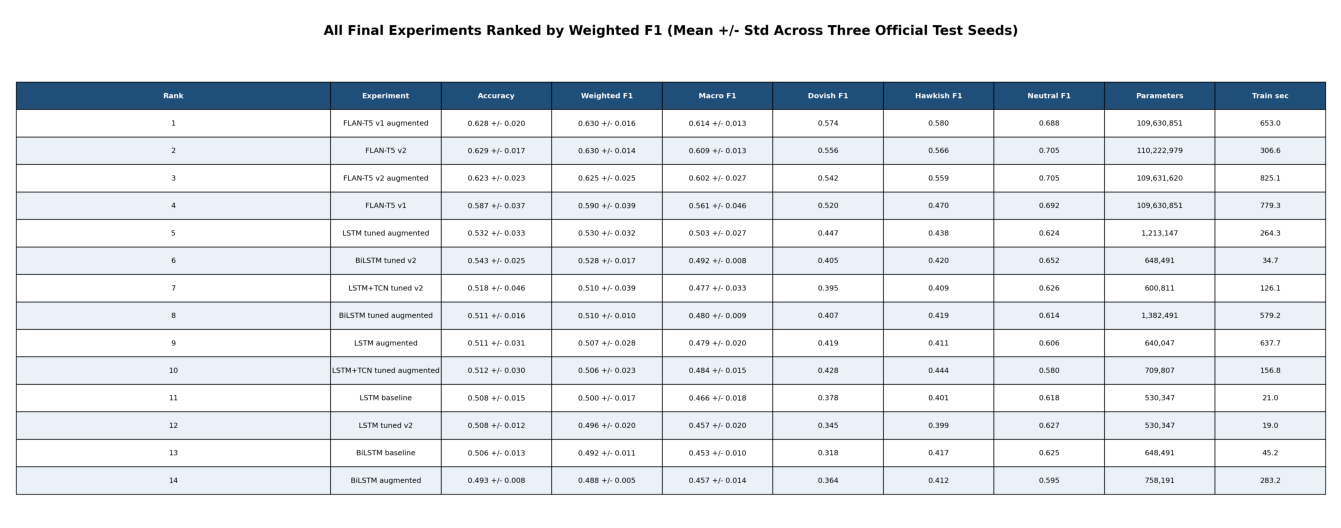

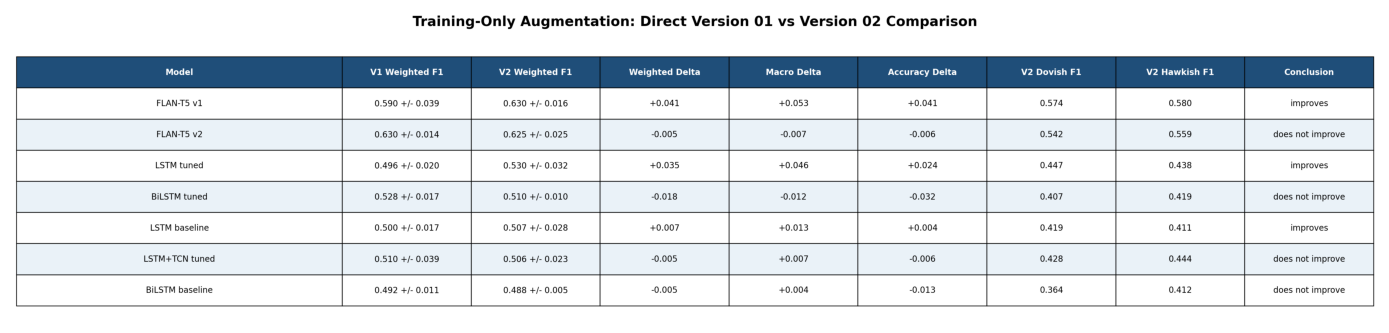

In [22]:
showsubmissionfigure('pic7.png')
showsubmissionfigure('pic8.png')


RNN metrics and training cost

These figures compare the final LSTM, BiLSTM and LSTM+TCN results, class F1 scores and training cost.


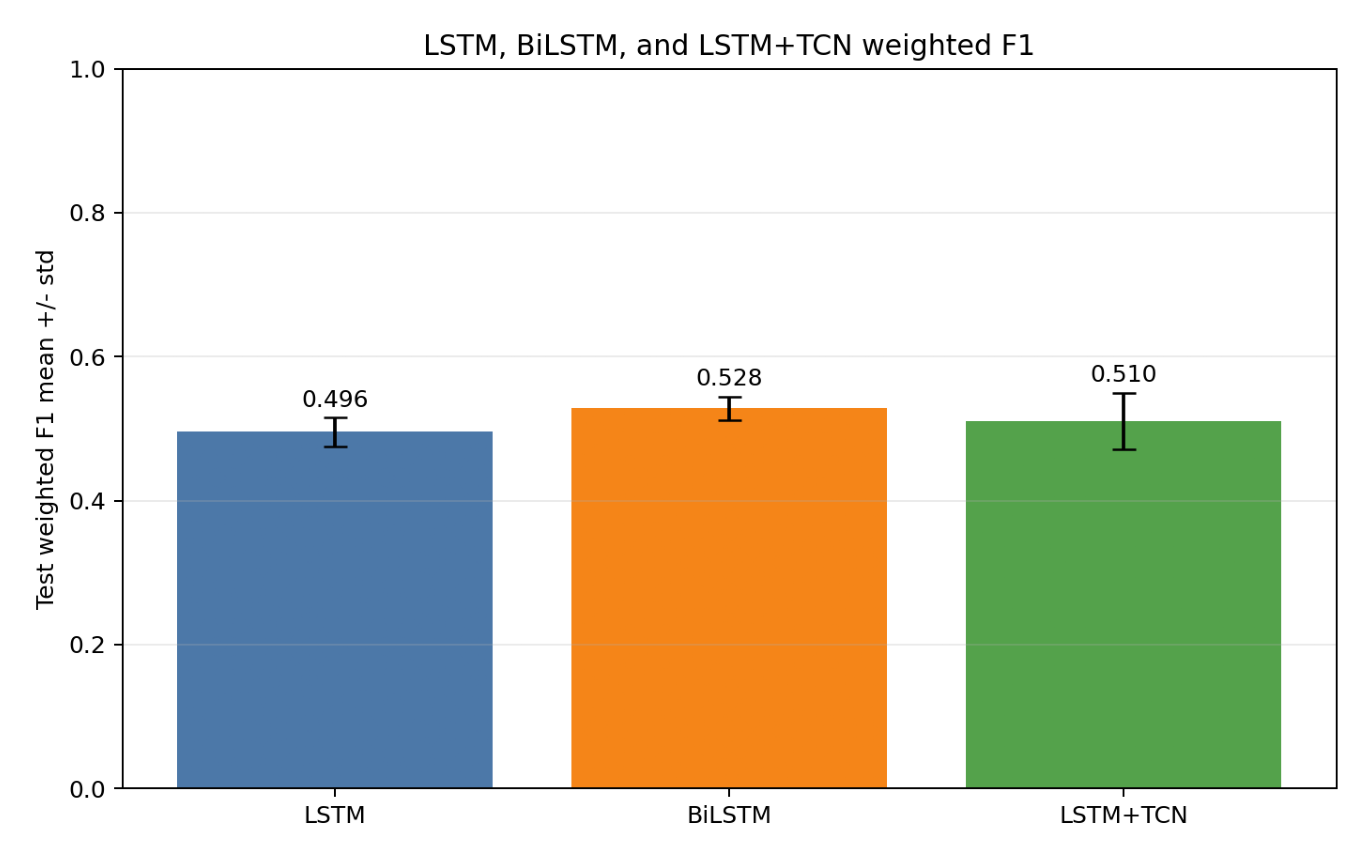

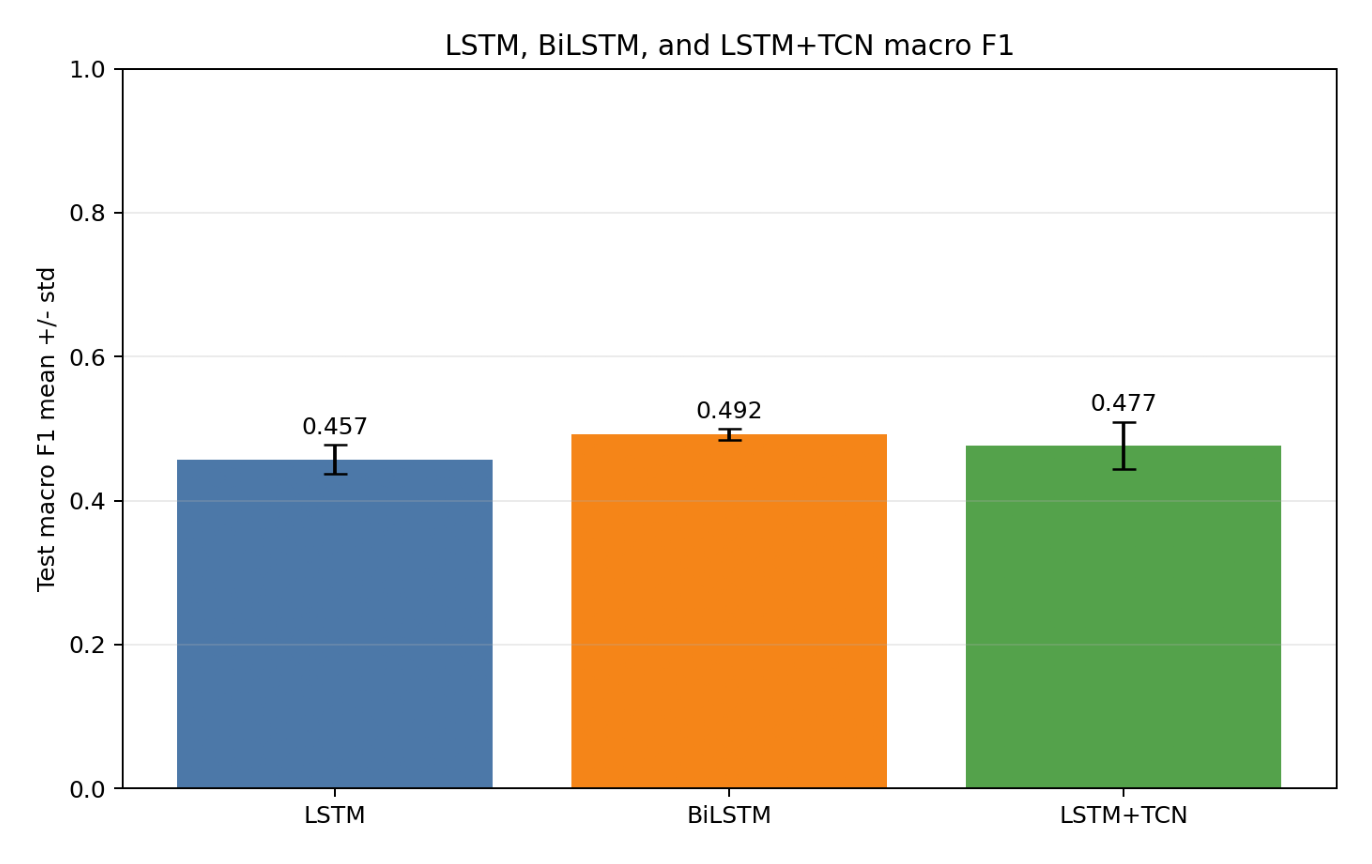

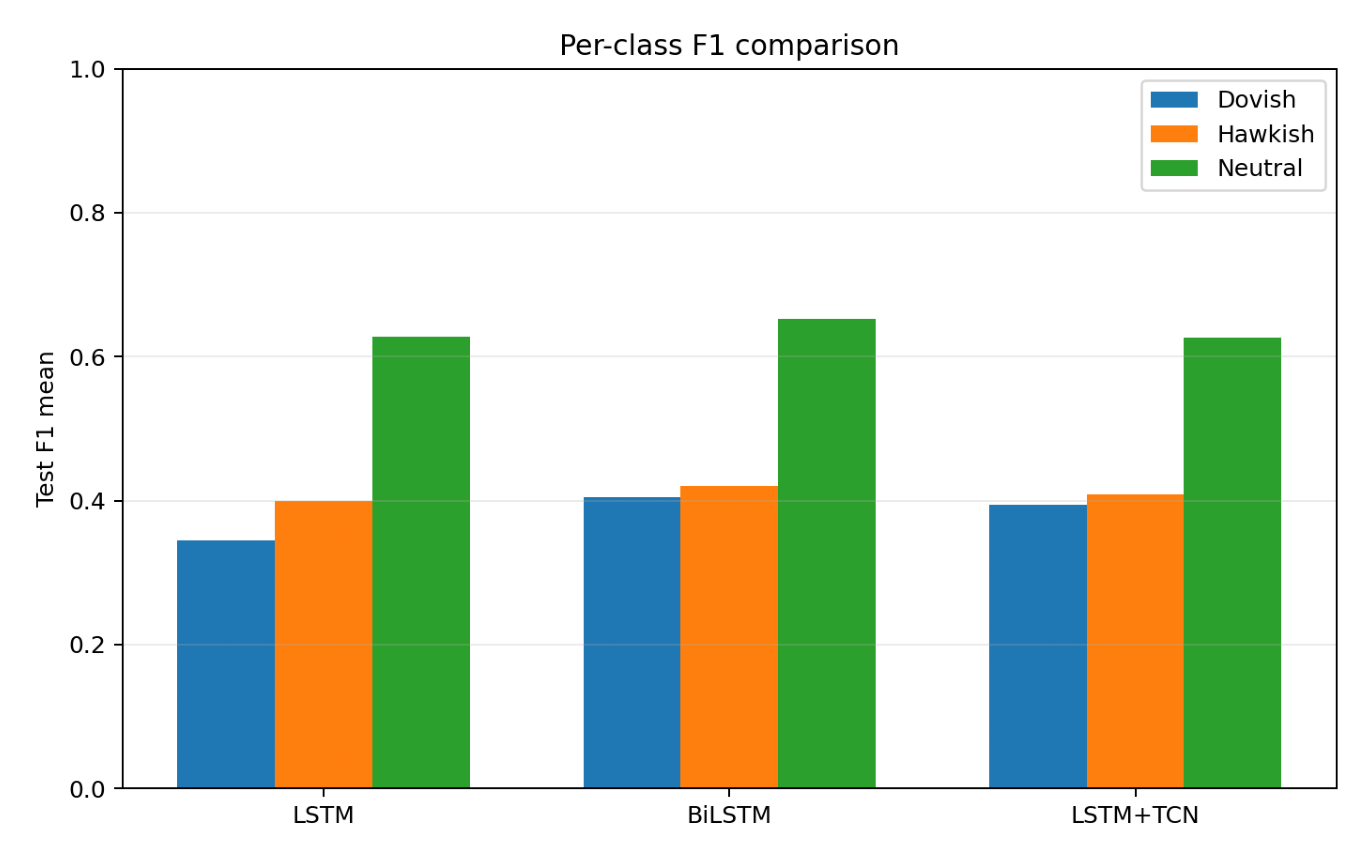

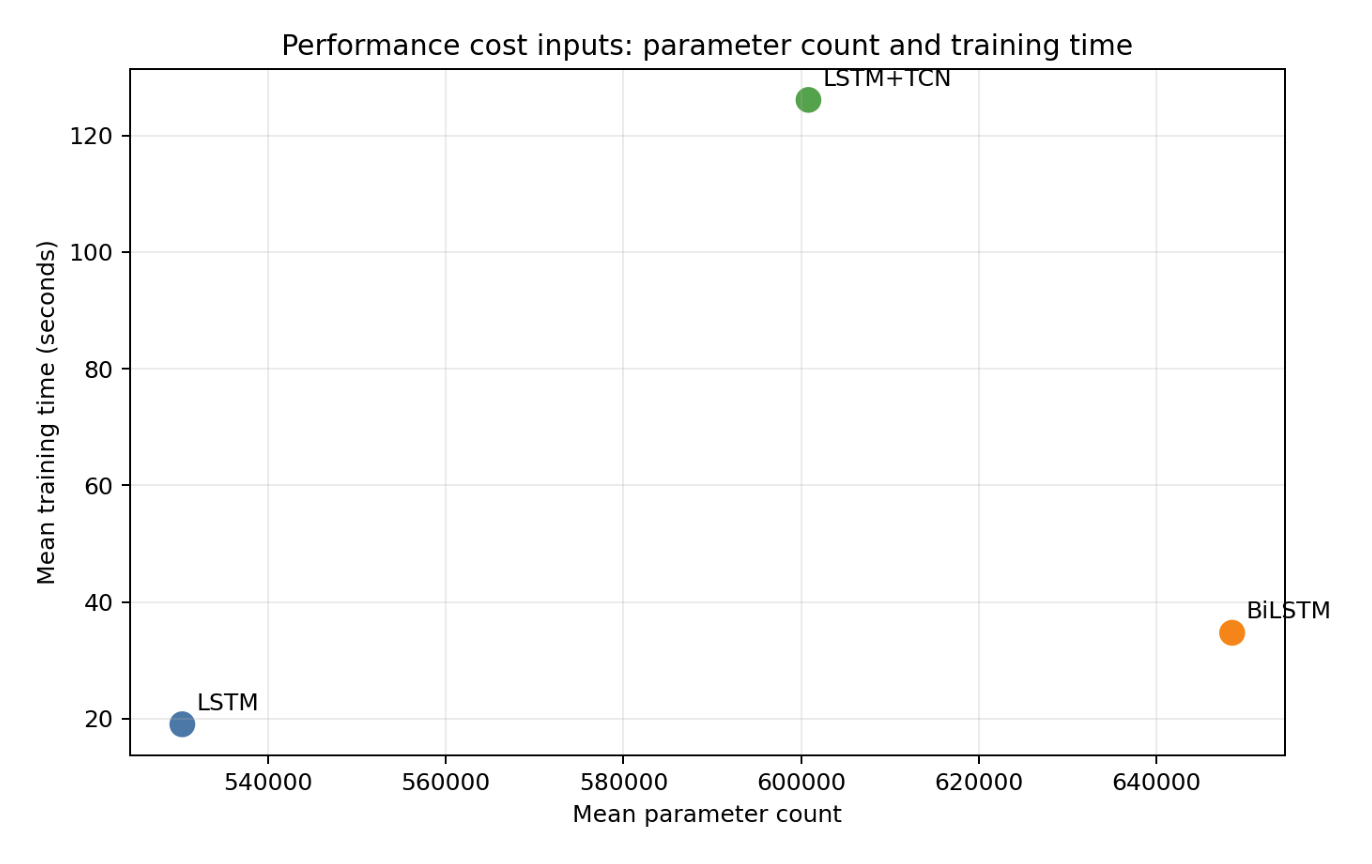

In [23]:
showsubmissionfigure('pic1.png')
showsubmissionfigure('pic2.png')
showsubmissionfigure('pic3.png')
showsubmissionfigure('pic4.png')


Candidate settings and learning curves

The candidate tables keep the selected setting and useful next-best settings. The curves come from the saved training records.


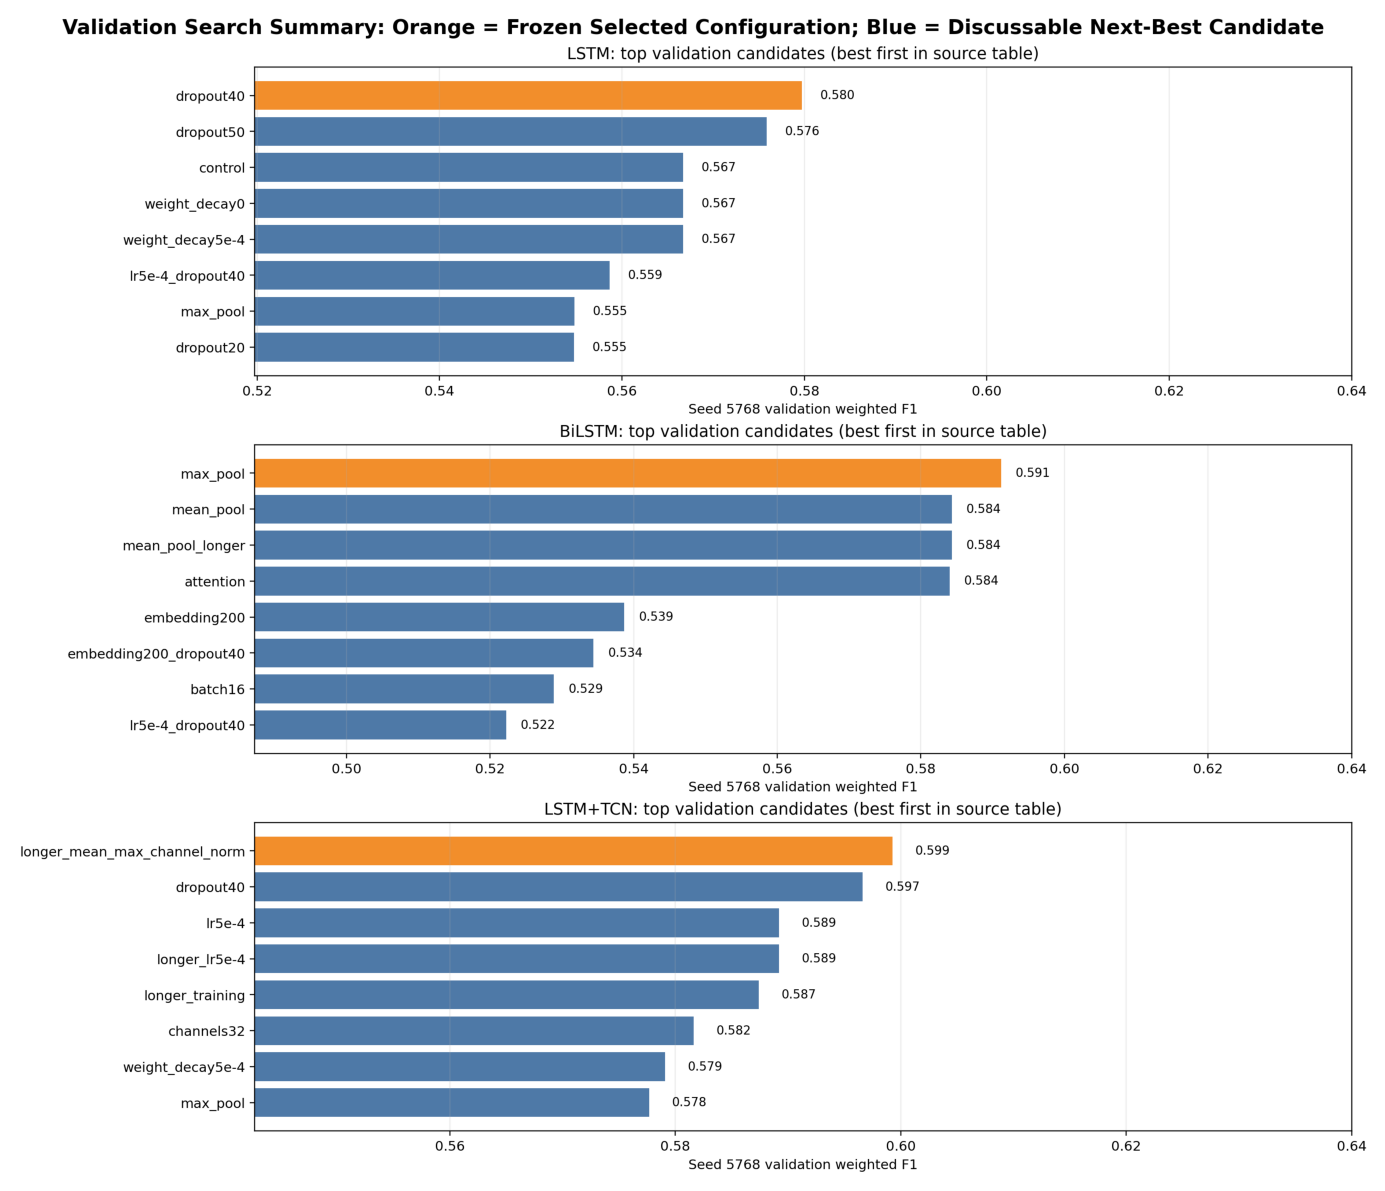

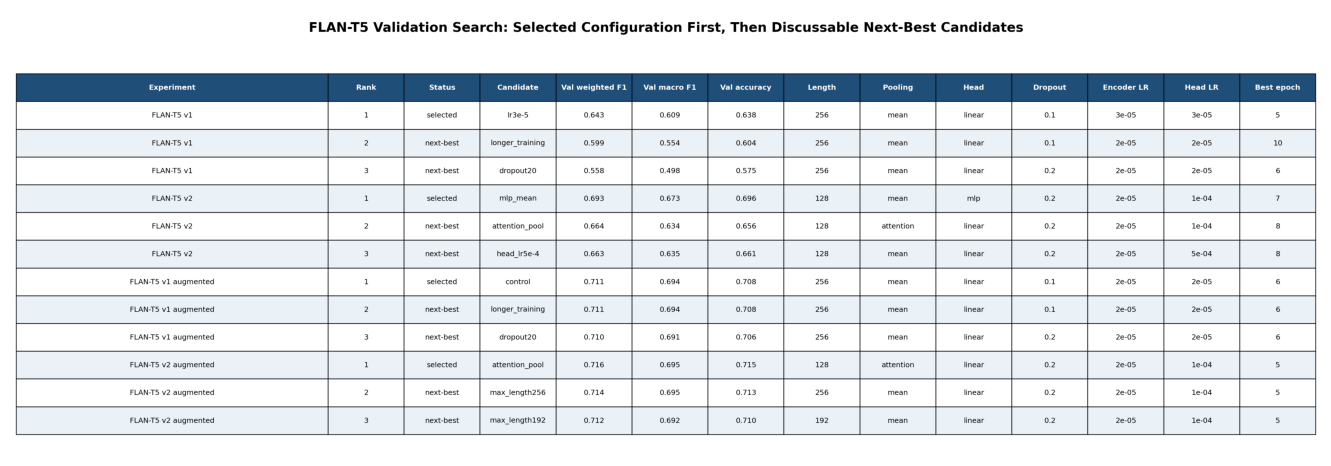

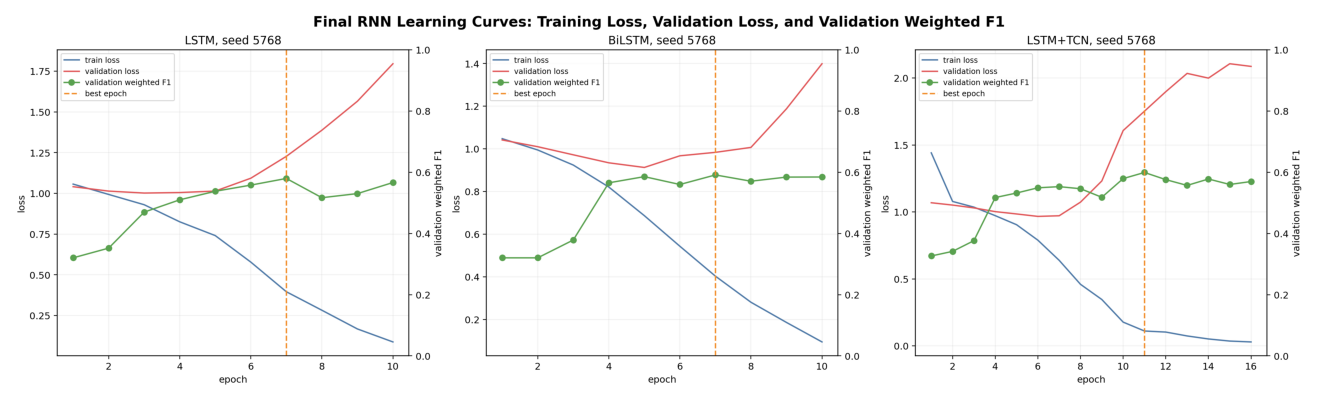

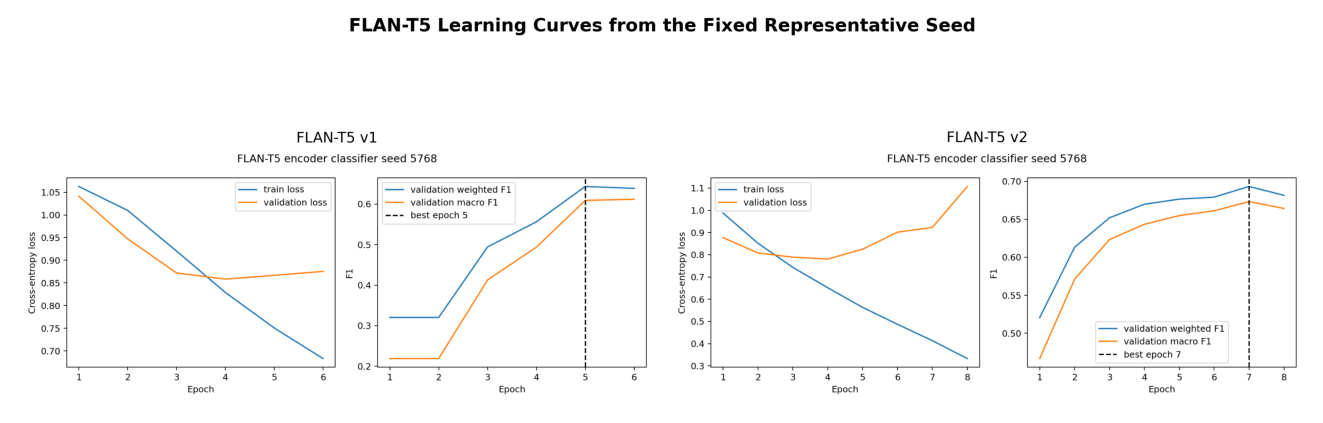

In [24]:
showsubmissionfigure('pic9.png')
showsubmissionfigure('pic10.png')
showsubmissionfigure('pic12.png')
showsubmissionfigure('pic13.png')


Example predictions

This section keeps two representative confusion matrices and ten real errors from the frozen test set.


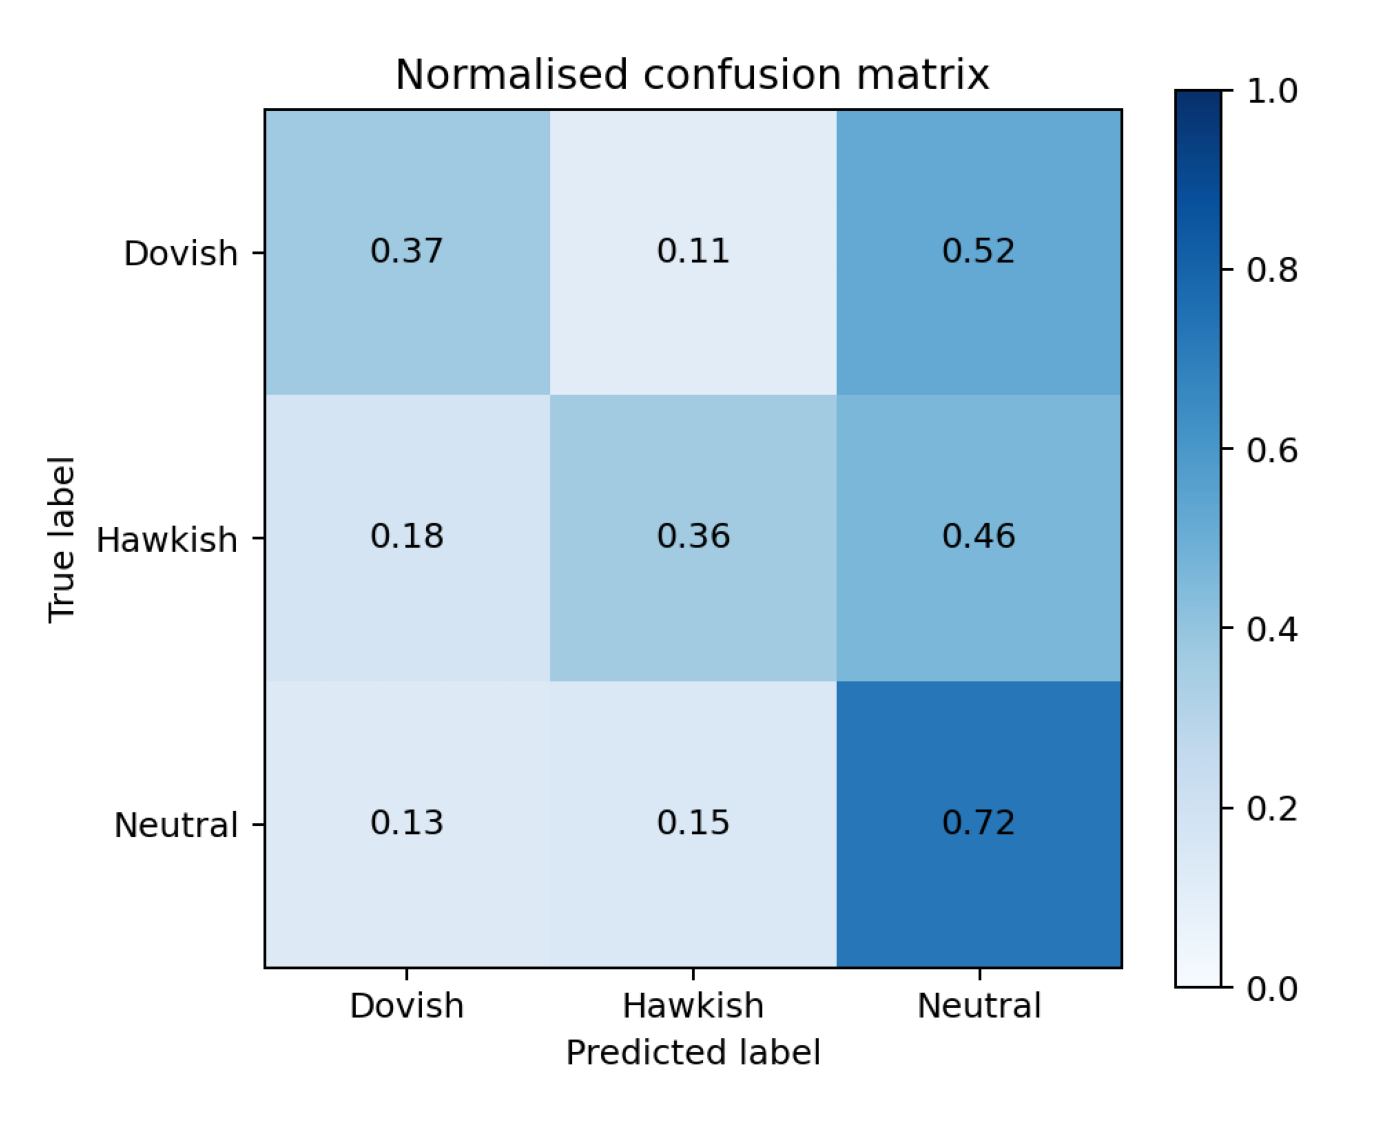

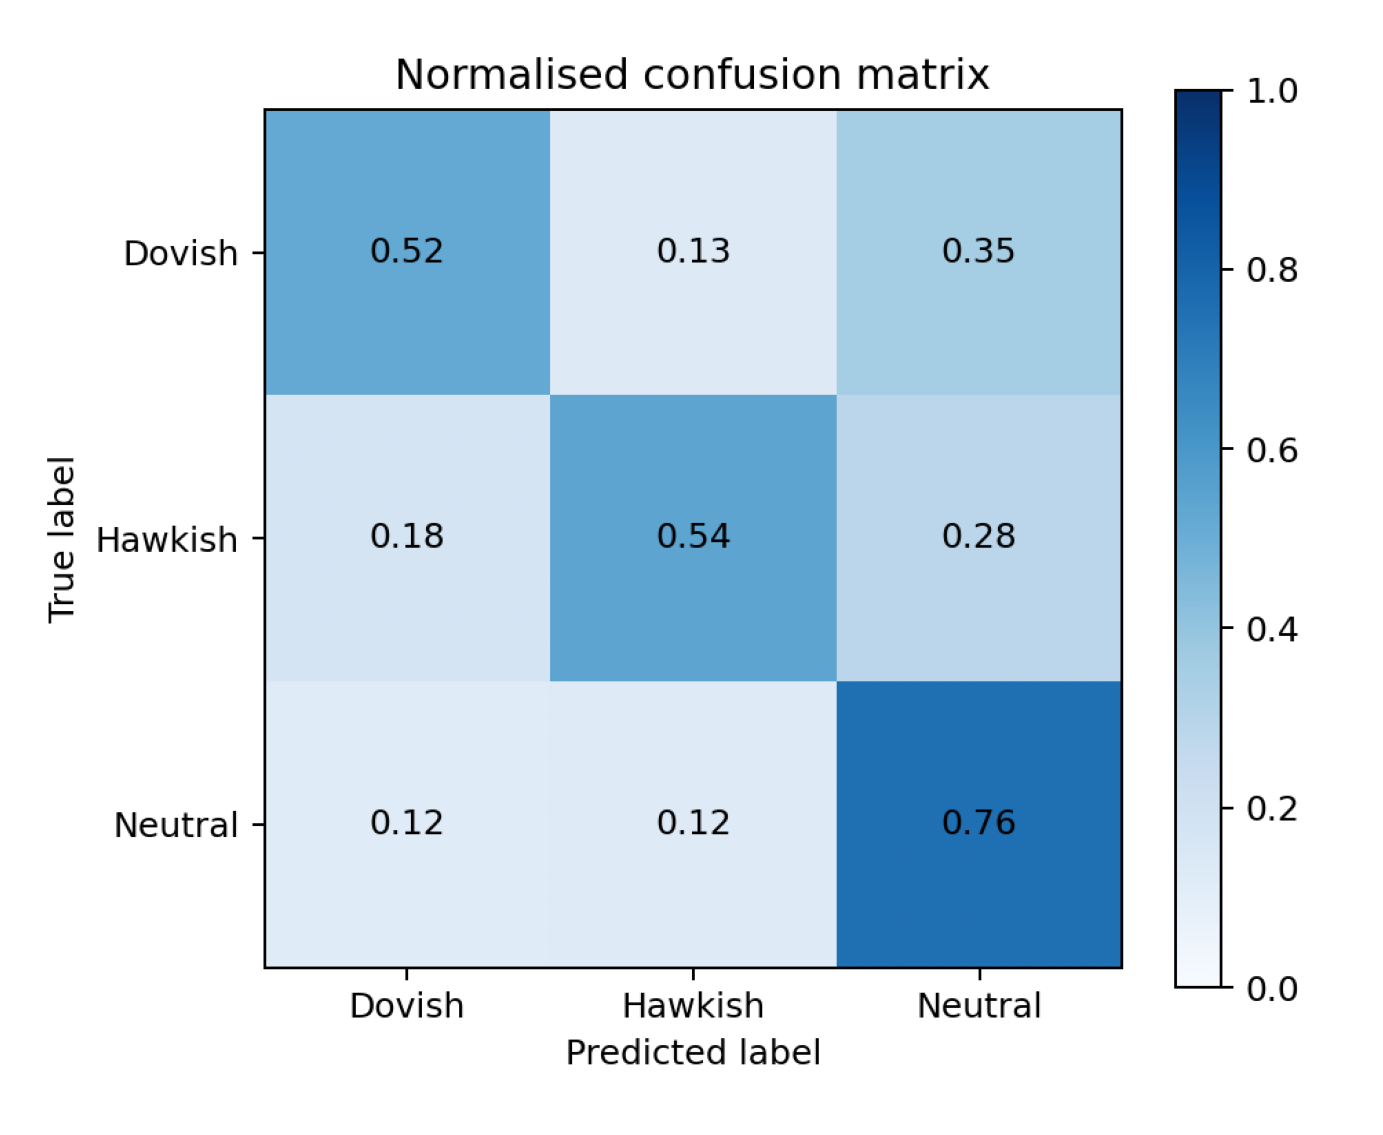

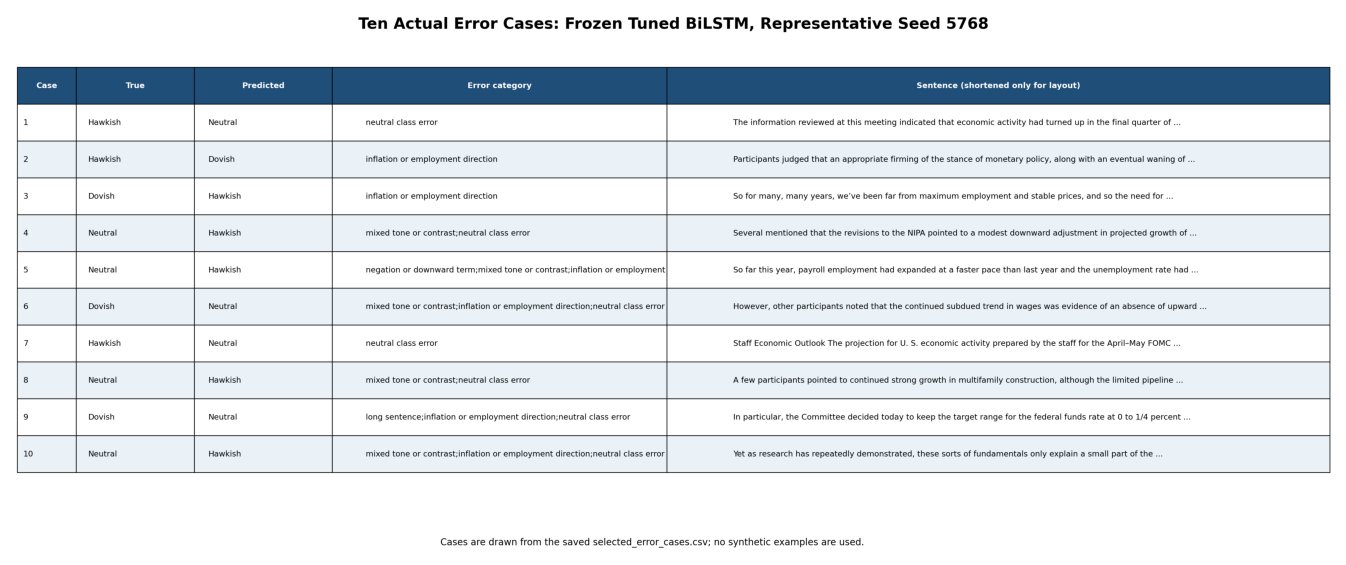

In [25]:
showsubmissionfigure('pic5.png')
showsubmissionfigure('pic6.png')
showsubmissionfigure('pic11.png')


Seven models, Version 01

These two figures summarise the seven models without augmentation. Each confusion matrix is the mean row-normalised matrix across the three official test seeds.


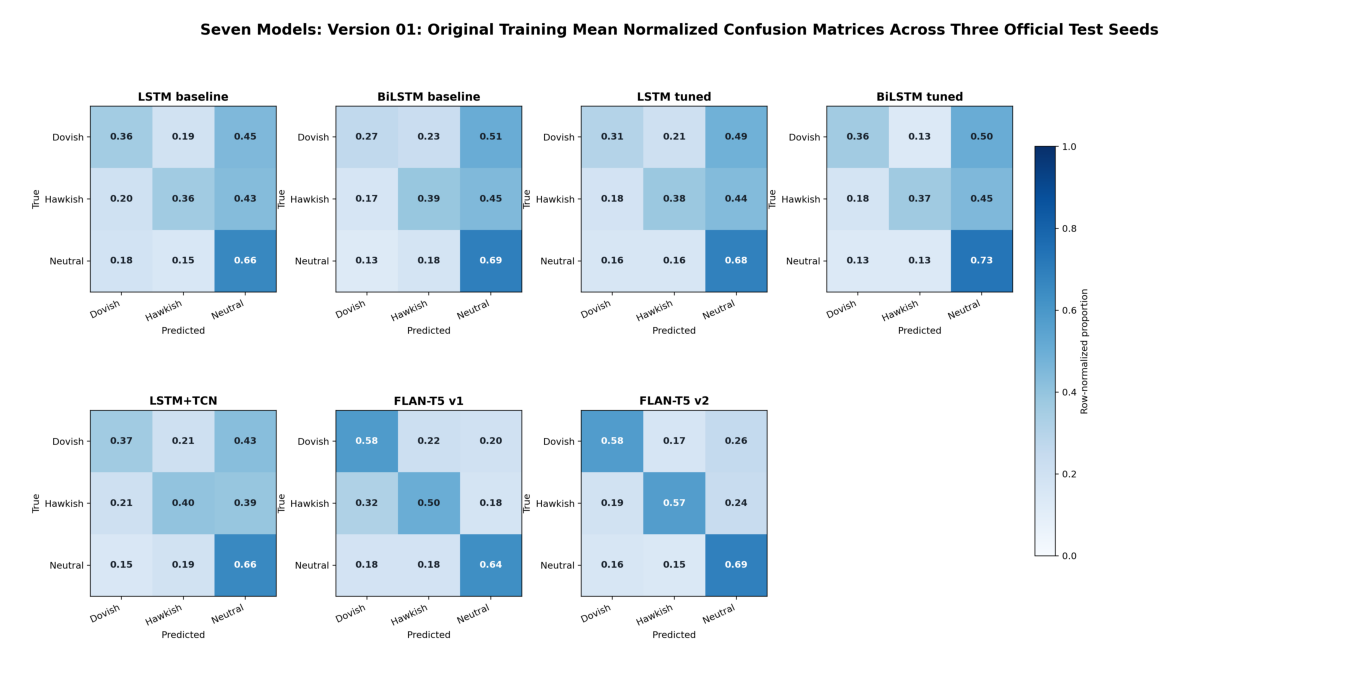

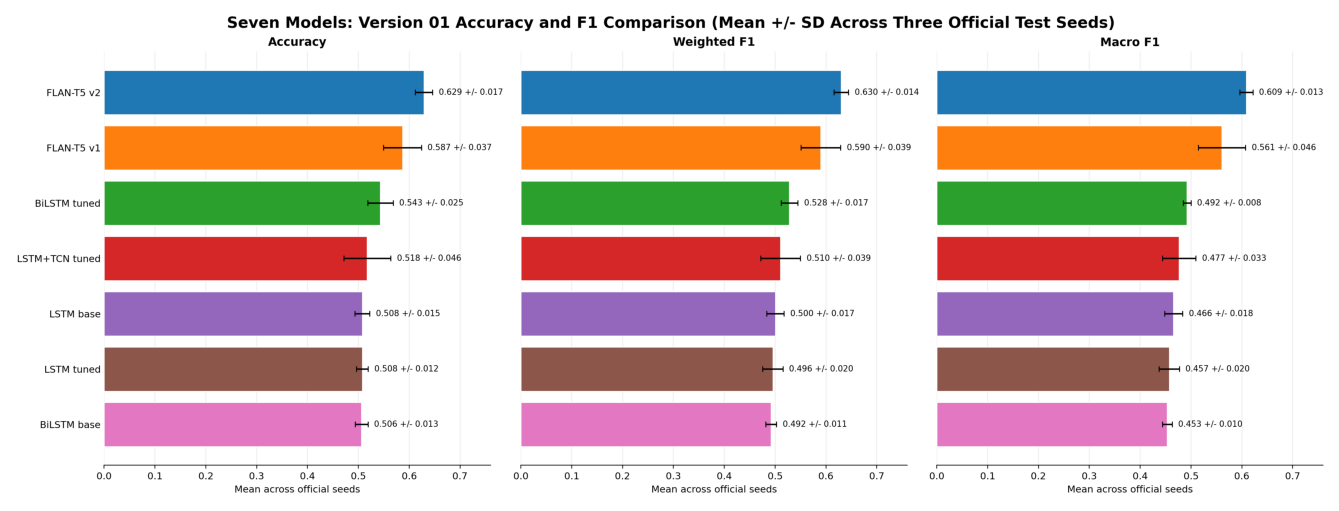

In [26]:
showsubmissionfigure('pic14.png')
showsubmissionfigure('pic16.png')


Seven models, Version 02

This confusion-matrix panel uses the train-only augmented versions. Validation and test samples are unchanged.


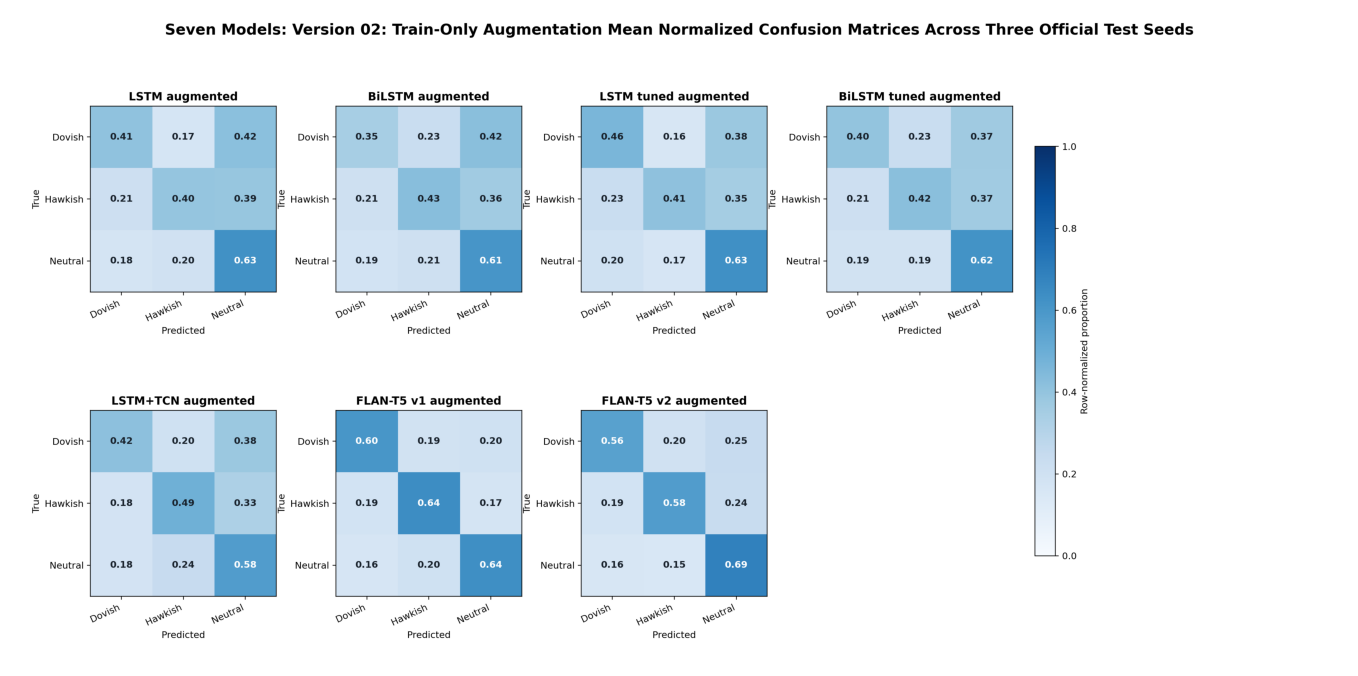

In [27]:
showsubmissionfigure('pic15.png')


Version 01 and Version 02

This figure compares original training and train-only augmentation for every model. Error bars show the standard deviation across the three official test seeds.


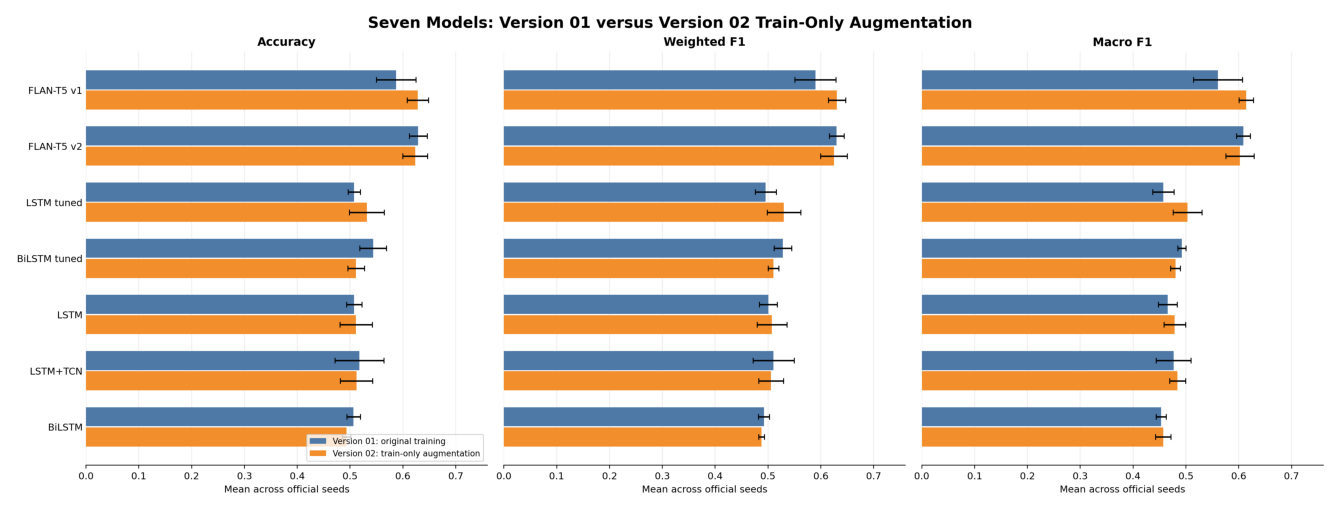

In [28]:
showsubmissionfigure('pic17.png')
